In [7]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,angle_to_open_corner,turn_direction_left_right
from pipeline.oa_calculations import *
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'frechetdist'

In [ ]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    'font.family':'arial',
    'font.size': 32,
    'font.weight' : 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})

In [253]:
data.head_turn_velocities

4775     [0.5047814889695829, 0.41843091393729326, 3.31...
4795     [0.8291302272325729, 1.1996052254984357, 0.752...
4797     [1.239459383107251, 1.1358883330819625, -6.317...
4799     [2.3662811973812725, 1.4626139420383832, -4.35...
4817     [0.5541795045844489, 1.7675934704383678, 3.288...
                               ...                        
15843    [0.37320807009629475, 0.8283500111953557, 7.60...
15914    [1.1695960711344755, 0.1536830641255582, 0.030...
15969    [0.713369414938384, 1.2978573791279246, -1.444...
16038    [0.3679016305333205, 0.11103871149268585, 0.18...
16058    [3.880612764330482, 0.9900243897813155, 1.3143...
Name: head_turn_velocities, Length: 147, dtype: object

In [2]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

def head_turn_calcs(df):
    for ind, row in df.iterrows():
        obstacle_ind = int(row.obstacle_ind)
        vel = row.head_angle_velocity[:obstacle_ind]
        
        # Detect positive and negative peaks separately
        pos_peaks, pos_props = find_peaks(vel, width=0, height=(0))
        neg_peaks, neg_props = find_peaks(-vel, width=0, height=(0))
        
        # Store positive peaks info
        pos_heights = pos_props['peak_heights'] if len(pos_peaks) > 0 else np.array([])
        pos_left_ips = pos_props['left_ips'] if len(pos_peaks) > 0 else np.array([])
        pos_right_ips = pos_props['right_ips'] if len(pos_peaks) > 0 else np.array([])
        
        # Store negative peaks info (convert heights back to negative values)
        neg_heights = -neg_props['peak_heights'] if len(neg_peaks) > 0 else np.array([])
        neg_left_ips = neg_props['left_ips'] if len(neg_peaks) > 0 else np.array([])
        neg_right_ips = neg_props['right_ips'] if len(neg_peaks) > 0 else np.array([])
        
        # Combine all peaks for main peak selection
        all_peaks = np.concatenate([pos_peaks, neg_peaks])
        all_heights = np.concatenate([pos_heights, neg_heights])
        
        if len(all_peaks) > 0:
            # Find main peak (max absolute velocity)
            max_abs_idx = np.argmax(np.abs(all_heights))
            main_peak = all_peaks[max_abs_idx]
            main_height = all_heights[max_abs_idx]
            
            # Determine if main peak is positive or negative
            if main_peak in pos_peaks:
                pos_idx = np.where(pos_peaks == main_peak)[0][0]
                main_left_ip = pos_left_ips[pos_idx]
                main_right_ip = pos_right_ips[pos_idx]
            else:
                neg_idx = np.where(neg_peaks == main_peak)[0][0]
                main_left_ip = neg_left_ips[neg_idx]
                main_right_ip = neg_right_ips[neg_idx]
                
            start_movement = int(np.round(main_left_ip))
            end_movement = int(np.round(main_right_ip))
            
            # Store main peak values
            df.at[ind, 'distance_at_head_turn'] = row.ts_distance_from_edge[main_peak]
            df.at[ind, 'distance_after_head_turn'] = row.ts_distance_from_edge[end_movement]
            df.at[ind, 'distance_before_head_turn'] = row.ts_distance_from_edge[start_movement]
            df.at[ind, 'indexs_of_head_turn'] = np.array([start_movement, main_peak, end_movement]).astype(object)
            df.at[ind, 'angle_at_head_turn'] = row.ts_angle_to_corner[main_peak]
            df.at[ind, 'angle_after_head_turn'] = row.ts_angle_to_corner[end_movement]
            df.at[ind, 'angle_before_head_turn'] = row.ts_angle_to_corner[start_movement]
            df.at[ind, 'head_turn_velocity'] = main_height
            df.at[ind, 'num_turn'] = len(all_peaks)
            
            # Store all peaks information (combined)
            df.at[ind, 'head_turn_indexs'] = all_peaks.astype(object)
            df.at[ind, 'head_turn_velocities'] = all_heights.astype(object)
            
            # Store separate positive/negative peaks information
            df.at[ind, 'positive_peaks'] = pos_peaks.astype(object)
            df.at[ind, 'positive_heights'] = pos_heights.astype(object)
            df.at[ind, 'positive_left_ips'] = pos_left_ips.astype(object)
            df.at[ind, 'positive_right_ips'] = pos_right_ips.astype(object)
            
            df.at[ind, 'negative_peaks'] = neg_peaks.astype(object)
            df.at[ind, 'negative_heights'] = neg_heights.astype(object)
            df.at[ind, 'negative_left_ips'] = neg_left_ips.astype(object)
            df.at[ind, 'negative_right_ips'] = neg_right_ips.astype(object)
            
            # Store non-main peaks information
            non_main_peaks = np.delete(all_peaks, max_abs_idx)
            if len(non_main_peaks) > 0:
                df.at[ind, 'angles_at_head_turns'] = row.ts_angle_to_corner[non_main_peaks].astype(object)
                df.at[ind, 'distances_at_head_turns'] = row.ts_distance_from_edge[non_main_peaks].astype(object)
                
                # Find end indices for non-main peaks
                non_main_ends = []
                for peak in non_main_peaks:
                    if peak in pos_peaks:
                        idx = np.where(pos_peaks == peak)[0][0]
                        non_main_ends.append(int(np.round(pos_right_ips[idx])))
                    else:
                        idx = np.where(neg_peaks == peak)[0][0]
                        non_main_ends.append(int(np.round(neg_right_ips[idx])))
                df.at[ind, 'angles_at_head_turns_ends'] = row.ts_angle_to_corner[non_main_ends].astype(object)
            else:
                df.at[ind, 'angles_at_head_turns'] = np.array([np.nan])
                df.at[ind, 'distances_at_head_turns'] = np.array([np.nan])
                df.at[ind, 'angles_at_head_turns_ends'] = np.array([np.nan])
        else:
            # Handle case with no peaks found
            df.at[ind, 'distance_at_head_turn'] = np.nan
            df.at[ind, 'distance_after_head_turn'] = np.nan
            df.at[ind, 'distance_before_head_turn'] = np.nan
            df.at[ind, 'indexs_of_head_turn'] = np.array([np.nan])
            df.at[ind, 'head_turn_indexs'] = np.array([np.nan])
            df.at[ind, 'angle_at_head_turn'] = np.nan
            df.at[ind, 'angle_after_head_turn'] = np.nan
            df.at[ind, 'angle_before_head_turn'] = np.nan
            df.at[ind, 'num_turn'] = 0
            df.at[ind, 'head_turn_velocity'] = np.nan
            df.at[ind, 'head_turn_velocities'] = np.array([np.nan])
            df.at[ind, 'angles_at_head_turns'] = np.array([np.nan])
            df.at[ind, 'angles_at_head_turns_ends'] = np.array([np.nan])
            df.at[ind, 'distances_at_head_turns'] = np.array([np.nan])
            
            # Empty arrays for positive/negative peaks
            df.at[ind, 'positive_peaks'] = np.array([]).astype(object)
            df.at[ind, 'positive_heights'] = np.array([]).astype(object)
            df.at[ind, 'positive_left_ips'] = np.array([]).astype(object)
            df.at[ind, 'positive_right_ips'] = np.array([]).astype(object)
            df.at[ind, 'negative_peaks'] = np.array([]).astype(object)
            df.at[ind, 'negative_heights'] = np.array([]).astype(object)
            df.at[ind, 'negative_left_ips'] = np.array([]).astype(object)
            df.at[ind, 'negative_right_ips'] = np.array([]).astype(object)
    
    return df

In [2]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

def head_turn_calcs(df):
    for ind, row in df.iterrows():
        obstacle_ind = int(row.obstacle_ind)
        vel = row.head_angle_velocity[:obstacle_ind]
        
        # Detect positive and negative peaks separately
        pos_peaks, pos_props = find_peaks(vel, width=0, height=(0))
        neg_peaks, neg_props = find_peaks(-vel, width=0, height=(0))
        
        # Store positive peaks info
        pos_heights = pos_props['peak_heights'] if len(pos_peaks) > 0 else np.array([])
        pos_left_ips = pos_props['left_ips'] if len(pos_peaks) > 0 else np.array([])
        pos_right_ips = pos_props['right_ips'] if len(pos_peaks) > 0 else np.array([])
        
        # Store negative peaks info (convert heights back to negative values)
        neg_heights = -neg_props['peak_heights'] if len(neg_peaks) > 0 else np.array([])
        neg_left_ips = neg_props['left_ips'] if len(neg_peaks) > 0 else np.array([])
        neg_right_ips = neg_props['right_ips'] if len(neg_peaks) > 0 else np.array([])
        
        # Combine all peaks for main peak selection
        all_peaks = np.concatenate([pos_peaks, neg_peaks])
        all_heights = np.concatenate([pos_heights, neg_heights])
        
        # Calculate large head movements (absolute velocity > 3)
        if len(all_peaks) > 0:
            abs_heights = np.abs(all_heights)
            large_turn_mask = abs_heights > 3
            large_turn_indexs = all_peaks[large_turn_mask]
            large_turn_velocities = all_heights[large_turn_mask]
            # NEW: Calculate distances for large head turns
            distances_at_large_head_turns = row.ts_distance_from_edge[large_turn_indexs] if len(large_turn_indexs) > 0 else np.array([])
        else:
            large_turn_indexs = np.array([])
            large_turn_velocities = np.array([])
            distances_at_large_head_turns = np.array([])
        
        if len(all_peaks) > 0:
            # Find main peak (max absolute velocity)
            max_abs_idx = np.argmax(np.abs(all_heights))
            main_peak = all_peaks[max_abs_idx]
            main_height = all_heights[max_abs_idx]
            
            # Determine if main peak is positive or negative
            if main_peak in pos_peaks:
                pos_idx = np.where(pos_peaks == main_peak)[0][0]
                main_left_ip = pos_left_ips[pos_idx]
                main_right_ip = pos_right_ips[pos_idx]
            else:
                neg_idx = np.where(neg_peaks == main_peak)[0][0]
                main_left_ip = neg_left_ips[neg_idx]
                main_right_ip = neg_right_ips[neg_idx]
                
            start_movement = int(np.round(main_left_ip))
            end_movement = int(np.round(main_right_ip))
            
            # Store main peak values
            df.at[ind, 'distance_at_head_turn'] = row.ts_distance_from_edge[main_peak]
            df.at[ind, 'distance_after_head_turn'] = row.ts_distance_from_edge[end_movement]
            df.at[ind, 'distance_before_head_turn'] = row.ts_distance_from_edge[start_movement]
            df.at[ind, 'indexs_of_head_turn'] = np.array([start_movement, main_peak, end_movement]).astype(object)
            df.at[ind, 'angle_at_head_turn'] = row.ts_angle_to_corner[main_peak]
            df.at[ind, 'angle_after_head_turn'] = row.ts_angle_to_corner[end_movement]
            df.at[ind, 'angle_before_head_turn'] = row.ts_angle_to_corner[start_movement]
            df.at[ind, 'head_turn_velocity'] = main_height
            df.at[ind, 'num_turn'] = len(all_peaks)
            
            # Store all peaks information (combined)
            df.at[ind, 'head_turn_indexs'] = all_peaks.astype(object)
            df.at[ind, 'head_turn_velocities'] = all_heights.astype(object)
            
            # Store large head movements information
            df.at[ind, 'large_head_turn_indexs'] = large_turn_indexs.astype(object)
            df.at[ind, 'large_head_turn_velocities'] = large_turn_velocities.astype(object)
            # NEW: Store distances at large head turns
            df.at[ind, 'distances_at_large_head_turns'] = distances_at_large_head_turns.astype(object)
            
            # Store separate positive/negative peaks information
            df.at[ind, 'positive_peaks'] = pos_peaks.astype(object)
            df.at[ind, 'positive_heights'] = pos_heights.astype(object)
            df.at[ind, 'positive_left_ips'] = pos_left_ips.astype(object)
            df.at[ind, 'positive_right_ips'] = pos_right_ips.astype(object)
            
            df.at[ind, 'negative_peaks'] = neg_peaks.astype(object)
            df.at[ind, 'negative_heights'] = neg_heights.astype(object)
            df.at[ind, 'negative_left_ips'] = neg_left_ips.astype(object)
            df.at[ind, 'negative_right_ips'] = neg_right_ips.astype(object)
            
            # Store non-main peaks information
            non_main_peaks = np.delete(all_peaks, max_abs_idx)
            if len(non_main_peaks) > 0:
                df.at[ind, 'angles_at_head_turns'] = row.ts_angle_to_corner[non_main_peaks].astype(object)
                df.at[ind, 'distances_at_head_turns'] = row.ts_distance_from_edge[non_main_peaks].astype(object)
                
                # Find end indices for non-main peaks
                non_main_ends = []
                for peak in non_main_peaks:
                    if peak in pos_peaks:
                        idx = np.where(pos_peaks == peak)[0][0]
                        non_main_ends.append(int(np.round(pos_right_ips[idx])))
                    else:
                        idx = np.where(neg_peaks == peak)[0][0]
                        non_main_ends.append(int(np.round(neg_right_ips[idx])))
                df.at[ind, 'angles_at_head_turns_ends'] = row.ts_angle_to_corner[non_main_ends].astype(object)
            else:
                df.at[ind, 'angles_at_head_turns'] = np.array([np.nan])
                df.at[ind, 'distances_at_head_turns'] = np.array([np.nan])
                df.at[ind, 'angles_at_head_turns_ends'] = np.array([np.nan])
        else:
            # Handle case with no peaks found
            df.at[ind, 'distance_at_head_turn'] = np.nan
            df.at[ind, 'distance_after_head_turn'] = np.nan
            df.at[ind, 'distance_before_head_turn'] = np.nan
            df.at[ind, 'indexs_of_head_turn'] = np.array([np.nan])
            df.at[ind, 'head_turn_indexs'] = np.array([np.nan])
            df.at[ind, 'angle_at_head_turn'] = np.nan
            df.at[ind, 'angle_after_head_turn'] = np.nan
            df.at[ind, 'angle_before_head_turn'] = np.nan
            df.at[ind, 'num_turn'] = 0
            df.at[ind, 'head_turn_velocity'] = np.nan
            df.at[ind, 'head_turn_velocities'] = np.array([np.nan])
            df.at[ind, 'angles_at_head_turns'] = np.array([np.nan])
            df.at[ind, 'angles_at_head_turns_ends'] = np.array([np.nan])
            df.at[ind, 'distances_at_head_turns'] = np.array([np.nan])
            
            # Empty arrays for large head movements
            df.at[ind, 'large_head_turn_indexs'] = np.array([]).astype(object)
            df.at[ind, 'large_head_turn_velocities'] = np.array([]).astype(object)
            # NEW: Empty array for distances at large head turns
            df.at[ind, 'distances_at_large_head_turns'] = np.array([]).astype(object)
            
            # Empty arrays for positive/negative peaks
            df.at[ind, 'positive_peaks'] = np.array([]).astype(object)
            df.at[ind, 'positive_heights'] = np.array([]).astype(object)
            df.at[ind, 'positive_left_ips'] = np.array([]).astype(object)
            df.at[ind, 'positive_right_ips'] = np.array([]).astype(object)
            df.at[ind, 'negative_peaks'] = np.array([]).astype(object)
            df.at[ind, 'negative_heights'] = np.array([]).astype(object)
            df.at[ind, 'negative_left_ips'] = np.array([]).astype(object)
            df.at[ind, 'negative_right_ips'] = np.array([]).astype(object)
    
    return df

In [2]:
oa_session = plot_oa(r"\\goeppert\Vol2\mike\recordings\processing_json\J701_J704.json",'blank')
oa_session.gather_session_df('obstacle',6)

6


In [3]:
J704_701df = oa_session.df
J704_701df = drop_nans_in_columns(J704_701df,'obstacle_ind')
turn_direction(J704_701df)
turn_to_obstacle(J704_701df)
heading_calcs(J704_701df)
get_head_angle(J704_701df)
head_angle_velocity(J704_701df)
angular_velocity_head_corner(J704_701df)
distance_at_head_turn(J704_701df)
calculate_speed(J704_701df)
intial_lateral_error(J704_701df)
avg_lateral_error(J704_701df)
get_initial_turn_direction(J704_701df)

new2
corner
port


In [269]:
import pandas as pd
import os

def split_and_save_dataframe(df, split_ratio, output_dir, filename_prefix):
    """
    Split a DataFrame and save parts as H5 files.
    
    Parameters:
    - df: pandas DataFrame to split
    - split_ratio: fraction of data to go to first file (0.0 to 1.0)
    - output_dir: directory to save files
    - filename_prefix: prefix for output filenames
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Split the DataFrame
    split_index = int(len(df) * split_ratio)
    df1 = df.iloc[:split_index]
    df2 = df.iloc[split_index:]
    
    # Create filenames
    file1 = os.path.join(output_dir, f"{filename_prefix}_part1.h5")
    file2 = os.path.join(output_dir, f"{filename_prefix}_part2.h5")
    
    # Save to HDF5 format
    df1.to_hdf(file1, key='data', mode='w')
    df2.to_hdf(file2, key='data', mode='w')
    
    print(f"Data saved to:\n- {file1}\n- {file2}")

In [270]:
split_and_save_dataframe(mon,.5,r'\\goeppert\Vol2\mike\metadata\behavior_paper_data','monocular')

Data saved to:
- \\goeppert\Vol2\mike\metadata\behavior_paper_data\monocular_part1.h5
- \\goeppert\Vol2\mike\metadata\behavior_paper_data\monocular_part2.h5


In [5]:
J704_701df

,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,avg_ts_speed,distance,ts_distance,total_distance,ts_total_distance,intial_lateral_error,avg_lateral_error,head_angle_whole_trial,head_angle_velocity_whole_trial,turn_direction_left_right
1,1,49298.501760,49300.754560,"[49298.508697, 49298.525606, 49298.542284, 492...","[[161, 162, 163, 164, 165, 166, 167, 168, 169,...","[648.7608642578125, 648.171630859375, 646.2357...","[280.55023193359375, 280.0666809082031, 278.73...","[635.47509765625, 633.7139892578125, 631.65777...","[270.6003112792969, 269.8623046875, 270.001159...","[640.41650390625, 639.1555786132812, 637.68518...",...,28.838673,"[0.07967866400687029, 0.24239286345105526, 0.4...","[0.8476791682440172, 0.7829488952457417, 0.772...",71.122849,54.715907,-8.199070,-3.129650,"[-120.49486404284735, -90.44740653968631, -37....","[-3.4047476452267733, -5.581395017108555, -6.0...",left
2,2,49300.754560,49308.750784,"[49300.759539, 49300.777062, 49300.793177, 493...","[296, 297, 298, 299, 300, 301, 302, 303, 304, ...","[68.82037353515625, 67.99369049072266, 67.1418...","[254.095458984375, 254.76304626464844, 253.994...","[74.49559783935547, 73.134521484375, 72.229621...","[258.2629699707031, 259.42425537109375, 258.65...","[76.09281158447266, 75.02220916748047, 73.9580...",...,30.288197,"[0.110983586723707, 0.1203878133036449, 0.1865...","[0.544735688052441, 0.5979651064672957, 0.3525...",89.224117,48.900787,5.967503,6.003985,"[-146.32624407366214, -146.90492626184948, -14...","[1.9049968012646035, 3.020384722477649, 3.1060...",left
3,3,49308.750784,49313.531238,"[49308.762355, 49308.779136, 49308.79639, 4930...","[[776, 777, 778, 779, 780, 781, 782, 783, 784,...","[648.4093627929688, 649.1452026367188, 649.393...","[281.964111328125, 281.29827880859375, 281.502...","[633.6756591796875, 634.7064819335938, 634.492...","[275.03497314453125, 274.42974853515625, 274.4...","[641.36376953125, 642.6102905273438, 642.93255...",...,30.140457,"[0.10410608021606649, 0.03356418105463632, 0.0...","[0.6391972794525067, 0.8323069183849832, 0.454...",78.543613,52.187246,7.183619,8.427998,"[-44.749866861771636, -72.56281295055332, -111...","[0.9660790490776172, 1.4258805735009927, 1.262...",right
4,4,49313.531238,49317.074598,"[49313.547622, 49313.564876, 49313.581056, 493...","[1063, 1064, 1065, 1066, 1067, 1068, 1069, 107...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[72.60108184814453, 71.69328308105469, 71.4748...","[260.7366638183594, 261.4021911621094, 261.238...","[77.22979736328125, 75.19596099853516, 74.4435...",...,21.763228,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.3165942284628862, 0.2302086214697443, 0.326...",73.910738,58.901706,-9.503080,-3.041655,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-1.0906591613035532, -2.422987619119472, -4.0...",right
5,5,49317.074598,49320.040217,"[49317.081907, 49317.098611, 49317.115443, 493...","[[1275, 1276, 1277, 1278, 1279, 1280, 1281, 12...","[647.1571655273438, 647.306884765625, 648.4654...","[279.1477966308594, 278.3889465332031, 278.109...","[636.057373046875, 636.6192016601562, 638.1153...","[264.35687255859375, 264.09259033203125, 263.5...","[634.3810424804688, 635.1669311523438, 636.076...",...,28.661759,"[0.06748195558878578, 0.10680789705947547, 0.0...","[0.5756637843848669, 0.5750744619190264, 0.541...",75.638882,59.316650,-7.057987,-5.110859,"[-152.98770727992164, -152.85205818875605, -15...","[-1.0900089613460984, -1.7110104576908647, -1....",left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16102,167,41512.192550,41514.924646,"[41512.202956, 41512.219366, 41512.2363, 41512...","[[37074, 37075, 37076, 37077, 37078, 37079, 37...","[632.9397583007812, 633.5975952148438, 633.849...","[274.8004150390625, 278.0003967285156, 278.864...","[616.6237182617188, 620.861572265625, 620.4717...","[271.91714477

In [4]:
mon_1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\monocular_part1.h5")
mon_2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\monocular_part2.h5")
mon = pd.concat([mon_1,mon_2])
#intial_distance_to_obstacle(mon)

In [5]:
head_turn_calcs(mon)

,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,positive_left_ips,positive_right_ips,negative_peaks,negative_heights,negative_left_ips,negative_right_ips,obstacle_cross,large_head_turn_indexs,large_head_turn_velocities,distances_at_large_head_turns
1,1,49298.501760,49300.754560,"[49298.508697, 49298.525606, 49298.542284, 492...","[[161, 162, 163, 164, 165, 166, 167, 168, 169,...","[648.7608642578125, 648.171630859375, 646.2357...","[280.55023193359375, 280.0666809082031, 278.73...","[635.47509765625, 633.7139892578125, 631.65777...","[270.6003112792969, 269.8623046875, 270.001159...","[640.41650390625, 639.1555786132812, 637.68518...",...,[37.09777368494302],[41.9489892980184],"[2, 14, 23]","[-6.06434430519478, -1.8255503428342466, -4.27...","[0.6109387984303355, 13.183464111592967, 19.07...","[3.366336523972994, 15.663548999810285, 26.933...",True,"[39, 2, 23]","[5.720048890695978, -6.06434430519478, -4.2761...","[3.277763931725101, 18.93754259432911, 8.75902..."
2,2,49300.754560,49308.750784,"[49300.759539, 49300.777062, 49300.793177, 493...","[296, 297, 298, 299, 300, 301, 302, 303, 304, ...","[68.82037353515625, 67.99369049072266, 67.1418...","[254.095458984375, 254.76304626464844, 253.994...","[74.49559783935547, 73.134521484375, 72.229621...","[258.2629699707031, 259.42425537109375, 258.65...","[76.09281158447266, 75.02220916748047, 73.9580...",...,"[0.5383869325212488, 10.431010649301836]","[2.937411980466693, 15.615993597365277]","[8, 19]","[-0.389509191933618, -1.005760660079695]","[5.6647208866511924, 18.566259112795667]","[10.431010649301836, 19.5]",True,[2],[3.1060173642108917],[10.050226956658046]
3,3,49308.750784,49313.531238,"[49308.762355, 49308.779136, 49308.79639, 4930...","[[776, 777, 778, 779, 780, 781, 782, 783, 784,...","[648.4093627929688, 649.1452026367188, 649.393...","[281.964111328125, 281.29827880859375, 281.502...","[633.6756591796875, 634.7064819335938, 634.492...","[275.03497314453125, 274.42974853515625, 274.4...","[641.36376953125, 642.6102905273438, 642.93255...",...,"[0.5, 5.928266647697955, 11.973430672790146, 2...","[2.1372516016508434, 7.8372173687703075, 14.32...","[11, 17]","[-0.2533550162007592, -0.5285631893887666]","[9.558633019362658, 3.803524676810539]","[11.973430672790146, 19.733821252770433]",True,[24],[3.1126274390320856],[11.754604113983326]
4,4,49313.531238,49317.074598,"[49313.547622, 49313.564876, 49313.581056, 493...","[1063, 1064, 1065, 1066, 1067, 1068, 1069, 107...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[72.60108184814453, 71.69328308105469, 71.4748...","[260.7366638183594, 261.4021911621094, 261.238...","[77.22979736328125, 75.19596099853516, 74.4435...",...,"[26.74844354033088, 23.538789991863688, 59.506...","[29.339687810462806, 49.720851771269864, 64.98...","[5, 20, 53, 56, 70]","[-8.01002129506776, -2.2809954540809674, -1.71...","[2.270746503048173, 19.5, 49.769899754316505, ...","[10.069174654594786, 20.12156945532645, 59.506...",True,"[5, 70]","[-8.01002129506776, -3.357389783603937]","[17.458700242797768, 4.6728749795911035]"
5,5,49317.074598,49320.040217,"[49317.081907, 49317.098611, 49317.115443, 493...","[[1275, 1276, 1277, 1278, 1279, 1280, 1281, 12...","[647.1571655273438, 647.306884765625, 648.4654...","[279.1477966308594, 278.3889465332031, 278.109...","[636.057373046875, 636.6192016601562, 638.1153...","[264.35687255859375, 264.09259033203125, 263.5...","[634.3810424804688, 635.1669311523438, 636.076...",...,"[4.494096772705207, 26.567468912047858, 47.933...","[15.185469714924704, 30.251351787990586, 48.50...","[2, 12, 21, 32]","[-1.7473945746792574, -0.5340981538808043, -8....","[0.529294709596153, 11.824027066201708, 17.842...","[2.9814880222894202, 13.311151991722522, 25.01...",True,"[48, 21]","[4.876911314889294, -8.130050266718746]","[-1.169376807990504, 3.979190896158535]"
...,...,...,...,...,...,...,...,...,...,...,...,

In [6]:
check_trial_for_obstalce_cross_df(mon)

NameError: name 'check_trial_for_obstalce_cross_df' is not defined

In [ ]:

first_nose_y,first_nose_x=get_median_trajectory(first_trial,x_key='ts_nose_x_cm',y_key='ts_nose_y_cm',turn_direction_key='odd')

In [ ]:
def get_median_trajectory(df, x_key: str, y_key: str, 
                         turn_direction_key: str = 'turn_direction_left_right',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate median trajectory by interpolating y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both median and all interpolated trajectories
    
    Returns:
    - Median trajectory (and optionally all trajectories)
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
   
    
   ## Set distance bins based on turn direction and start position
   #if turn_direction == 'left' and start_position == 'bottom':
   #    distance_bins = np.arange(9, 50, 1)    # Left turns from bottom left
   #elif turn_direction == 'right' and start_position == 'bottom':
   #    distance_bins = np.arange(45, 0, -1)   # Right turns from bottom right
   #elif turn_direction == 'left' and start_position == 'top':
   #    distance_bins = np.arange(45, 0, -1) 
   #elif turn_direction == 'right' and start_position == 'top':
   #    distance_bins = np.arange(9, 50, 1) 

        # Set distance bins based on turn direction and start position
 
    if turn_direction == 'left':
        distance_bins = np.arange(44, 3, -1)    # Left turns from bottom left
    elif turn_direction == 'right':
        distance_bins = np.arange(9, 50, 1)   # Right turns from bottom right
  
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan  # Initialize with NaNs
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        # Remove duplicate x-values (keep first occurrence)
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        # Only interpolate if we have at least 2 points
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    # Calculate median trajectory
    median_trajectory = np.nanmedian(trajectory_matrix, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_median = pd.Series(median_trajectory)
    valid_median.fillna(method='bfill', inplace=True)
    valid_median.fillna(method='ffill', inplace=True)
    median_trajectory = valid_median.to_numpy()
    
    if return_matrix:
        return median_trajectory, trajectory_matrix
    else:
        return median_trajectory,distance_bins

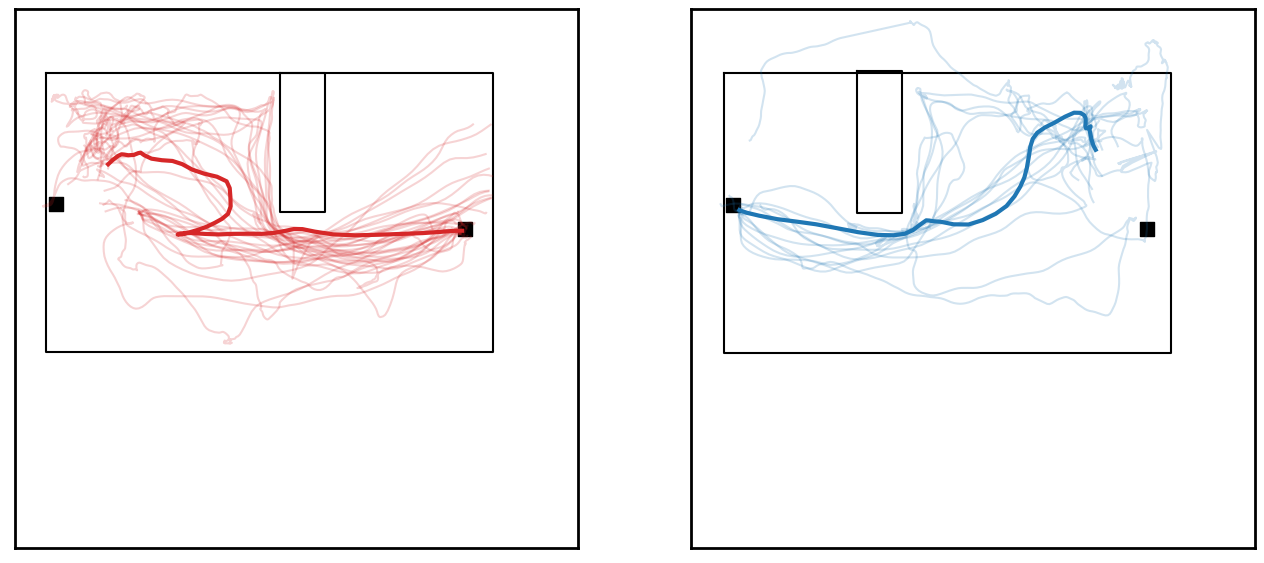

In [455]:
fig,ax = plt.subplots(1,2,figsize=(16,7),)
#check_trial_for_obstalce_cross_df(data)
data = mon
data = data[data.task=='oa']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

oa_df = data[(data.obstacle_cluster == 1)&(data.task == 'oa')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'left')]
oa_df = oa_df[oa_df['animal'].isin([ 'J704RT', 'J704NN', 'J704LT', 'J704LN'])]
ax[0].set_xticks([])
ax[0].set_yticks([])
plot_arena(oa_df,ax[0])
ob_x,ob_y = plot_orginal_obstacle(oa_df,ax[0],5)
oa_df_nose_x = smooth(get_median_of_df(oa_df,'ts_nose_x_cm',50))
oa_df_nose_y = smooth(get_median_of_df(oa_df,'ts_nose_y_cm',50))
ax[0].plot(oa_df_nose_x,oa_df_nose_y,linewidth = 3,c = 'tab:red')
oa_df_sample_towards = oa_df
for ind,row in oa_df_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(x,y,alpha = .2 ,c = 'tab:red')

mon_df = data[(data.obstacle_cluster == 0)&(data.task == 'oa')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'right')]
mon_df = mon_df[mon_df['animal'].isin([ 'J704RT', 'J704NN', 'J704LT'])]
ax[1].set_xticks([])
ax[1].set_yticks([])
plot_arena(mon_df,ax[1])
ob_x,ob_y = plot_orginal_obstacle(mon_df,ax[1],5)
mon_df_nose_x = smooth(get_median_of_df(mon_df,'ts_nose_x_cm',50))
mon_df_nose_y = smooth(get_median_of_df(mon_df,'ts_nose_y_cm',50))
ax[1].plot(mon_df_nose_x,mon_df_nose_y,linewidth = 3,c = 'tab:blue')
mon_df_sample_towards = mon_df
for ind,row in mon_df_sample_towards.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax[1].plot(x,y,alpha = .2 ,c = 'tab:blue')

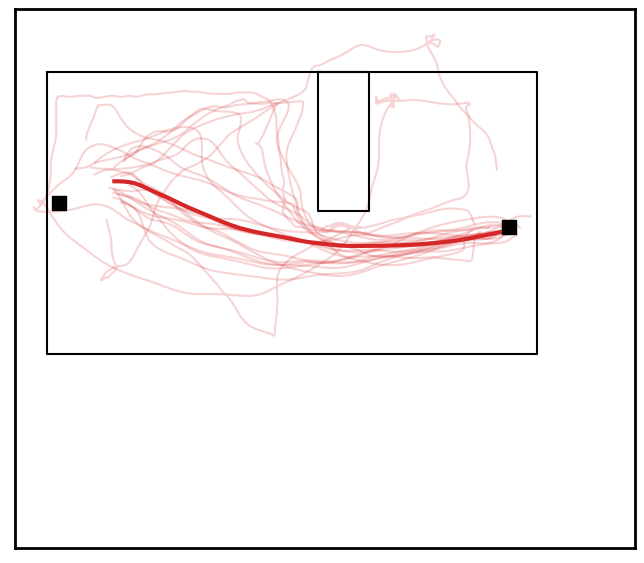

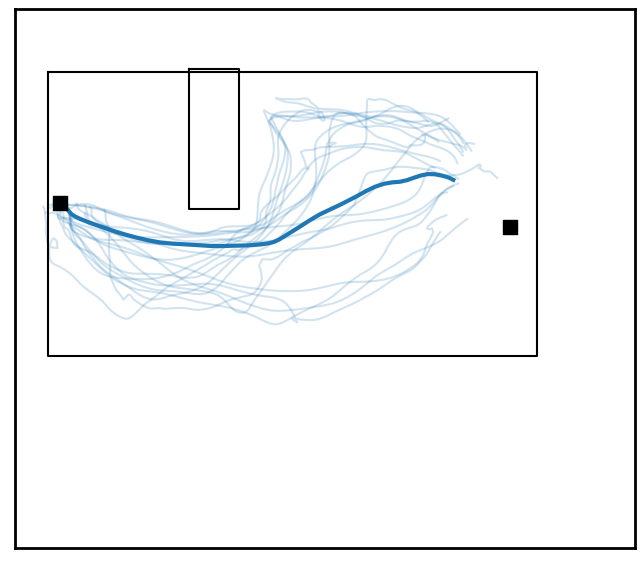

In [524]:
# First figure (OA condition)
fig1, ax1 = plt.subplots(figsize=(8, 7))
data = mon
data = data[data.task=='oamonle']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 


# Plot OA condition
oa_df = data[(data.obstacle_cluster == 1)&(data.task == 'oamonle')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'right')]
#oa_df = oa_df[oa_df['animal'].isin(['J704RT', 'J704NN', 'J704LT', 'J704LN'])]
ax1.set_xticks([])
ax1.set_yticks([])
plot_arena(oa_df, ax1)
ob_x, ob_y = plot_orginal_obstacle(oa_df, ax1, 5)
oa_df_nose_x = smooth(get_median_of_df(oa_df, 'ts_nose_x_cm', 50))
oa_df_nose_y = smooth(get_median_of_df(oa_df, 'ts_nose_y_cm', 50))
ax1.plot(oa_df_nose_x, oa_df_nose_y, linewidth=3, c='tab:red',zorder = 0)
oa_df_sample_towards = oa_df.sample(20)
for ind, row in oa_df_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax1.plot(x, y, alpha=.2, c='tab:red',zorder = 0)

# Save first figure
#fig1.savefig('oa_condition.png')
plt.show()
plt.close(fig1)

# Second figure (MON condition)
fig2, ax2 = plt.subplots(figsize=(8, 7))
mon_df = data[(data.obstacle_cluster == 0)&(data.task == 'oamonle')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'left')]
#mon_df = mon_df[mon_df['animal'].isin(['J704RT', 'J704NN', 'J704LT'])]
ax2.set_xticks([])
ax2.set_yticks([])
plot_arena(mon_df, ax2)
ob_x, ob_y = plot_orginal_obstacle(mon_df, ax2, 5)
mon_df_nose_x = smooth(get_median_of_df(mon_df, 'ts_nose_x_cm', 50))
mon_df_nose_y = smooth(get_median_of_df(mon_df, 'ts_nose_y_cm', 50))
ax2.plot(mon_df_nose_x, mon_df_nose_y, linewidth=3, c='tab:blue',zorder = 0)
mon_df_sample_towards = mon_df.sample(20)
for ind, row in mon_df_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax2.plot(x, y, alpha=.2, c='tab:blue',zorder = 0)

# Save second figure
#fig2.savefig('mon_condition.png')
plt.show()

#fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_6\right_turn_traces.pdf",dpi = 300, transparent=True)
#fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_6\left_turn_traces.pdf",dpi = 300, transparent=True)
plt.close(fig1)
plt.close(fig2)

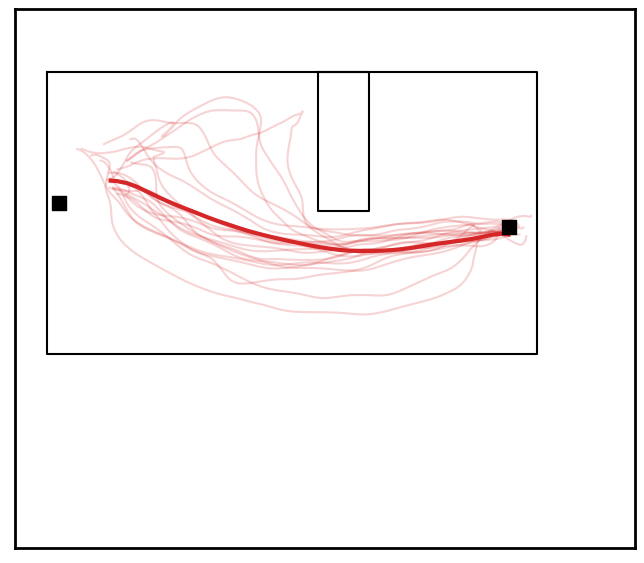

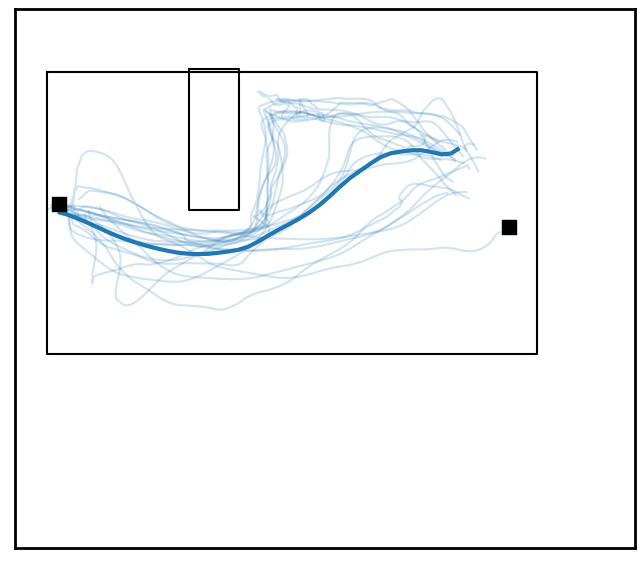

In [545]:
# First figure (OA condition)
fig1, ax1 = plt.subplots(figsize=(8, 7))
data = mon
data = data[data.task=='oamonle']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

# Plot OA condition
oa_df = data[(data.obstacle_cluster == 1)&(data.task == 'oamonle')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'right')]
ax1.set_xticks([])
ax1.set_yticks([])
plot_arena(oa_df, ax1)
ob_x, ob_y = plot_orginal_obstacle(oa_df, ax1, 5)

# Get median trajectory using new function
oa_df_nose_y, oa_df_nose_x = get_median_trajectory(oa_df, 'ts_nose_x_cm', 'ts_nose_y_cm', 
                                                  turn_direction_key='turn_direction_left_right',
                                                  start_position_key='start',
                                                  return_matrix=False)
oa_df_nose_x = smooth(oa_df_nose_x)
oa_df_nose_y = smooth(oa_df_nose_y)
ax1.plot(oa_df_nose_x, oa_df_nose_y, linewidth=3, c='tab:red', zorder=0)

# Plot individual trajectories
#oa_df_sample_towards = oa_df.sample(20)
for ind, row in oa_df_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax1.plot(x, y, alpha=.2, c='tab:red', zorder=0)

plt.show()
plt.close(fig1)

# Second figure (MON condition)
fig2, ax2 = plt.subplots(figsize=(8, 7))
mon_df = data[(data.obstacle_cluster == 0)&(data.task == 'oamonle')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'left')]
ax2.set_xticks([])
ax2.set_yticks([])
plot_arena(mon_df, ax2)
ob_x, ob_y = plot_orginal_obstacle(mon_df, ax2, 5)

# Get median trajectory using new function
mon_df_nose_y, mon_df_nose_x = get_median_trajectory(mon_df, 'ts_nose_x_cm', 'ts_nose_y_cm',
                                                    turn_direction_key='turn_direction_left_right',
                                                    start_position_key='start',
                                                    return_matrix=False)
mon_df_nose_x = smooth(mon_df_nose_x)
mon_df_nose_y = smooth(mon_df_nose_y)
ax2.plot(mon_df_nose_x, mon_df_nose_y, linewidth=3, c='tab:blue', zorder=0)

# Plot individual trajectories
#mon_df_sample_towards = mon_df.sample(20)
for ind, row in mon_df_sample_towards.iterrows():
    x, y = correct_trace(row, ob_x, ob_y)
    ax2.plot(x, y, alpha=.2, c='tab:blue', zorder=0)

plt.show()

# Save figures if needed
fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_6\right_turn_traces.pdf", dpi=300, transparent=True)
fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_6\left_turn_traces.pdf", dpi=300, transparent=True)
plt.close(fig1)
plt.close(fig2)

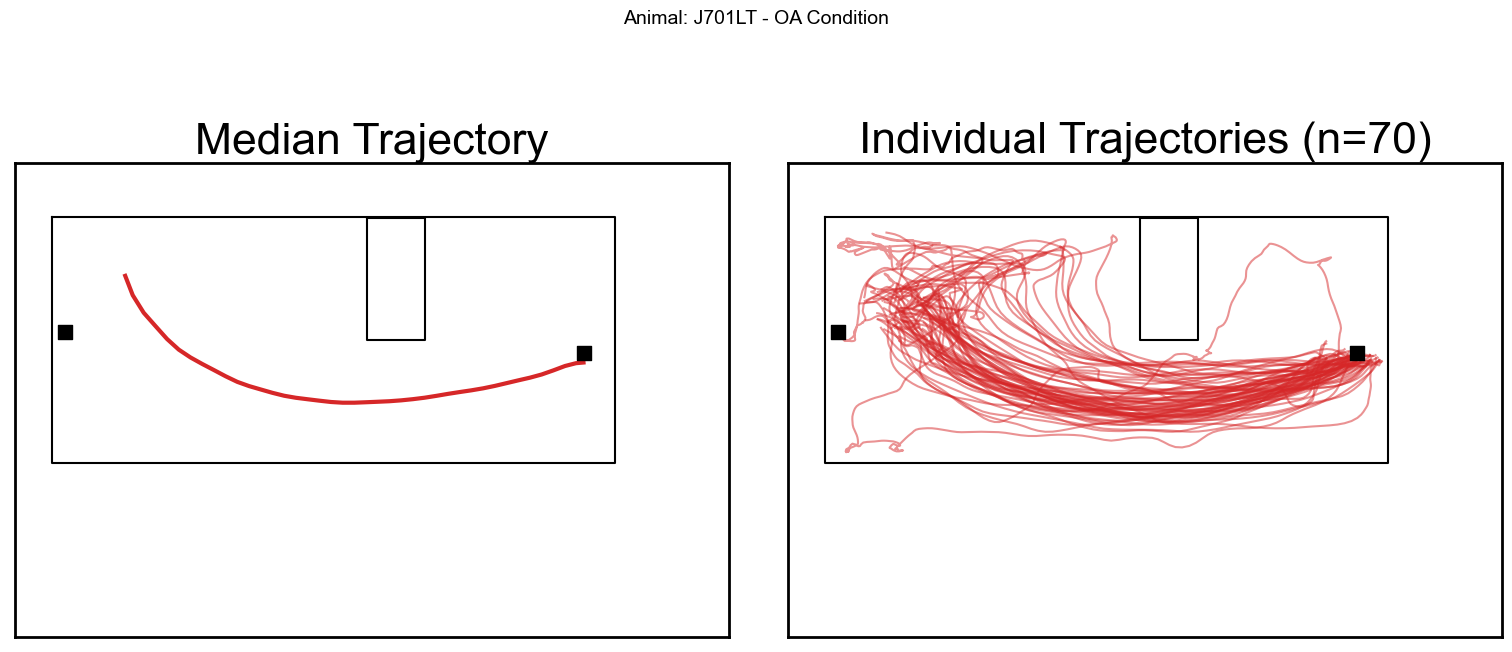

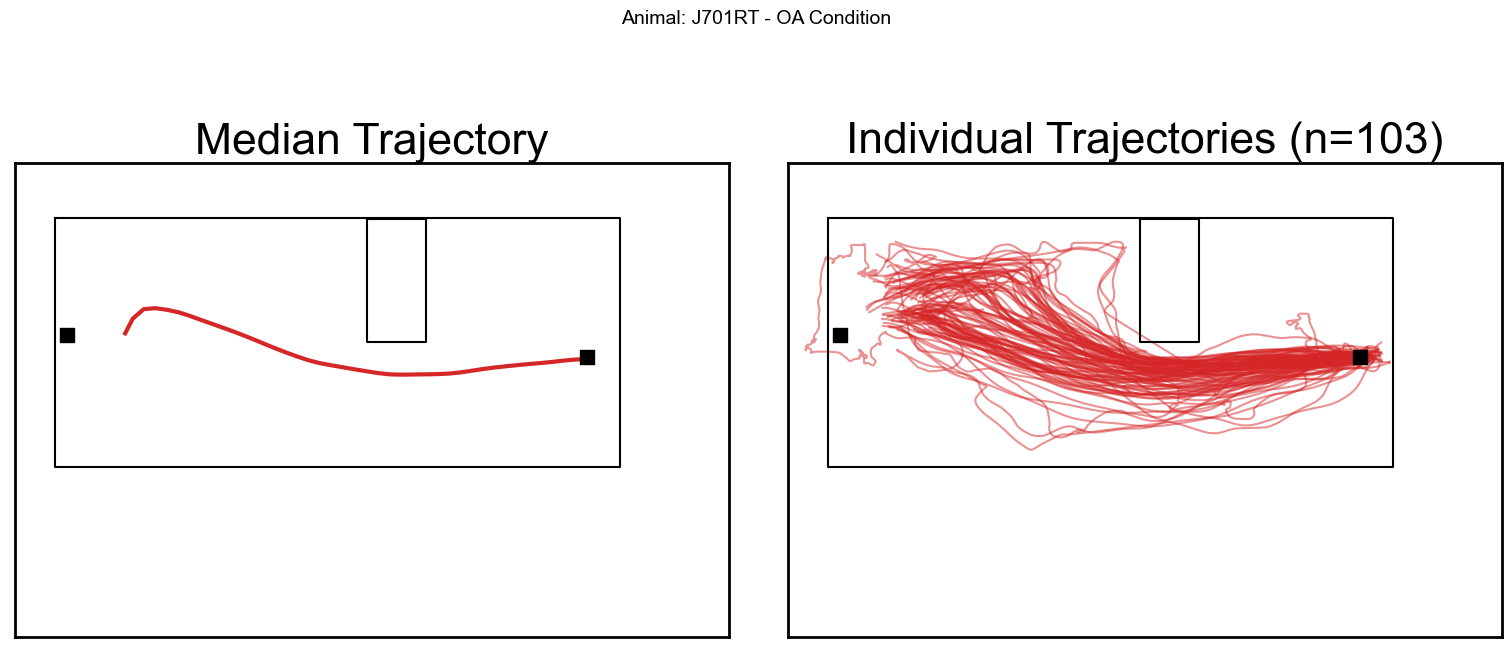

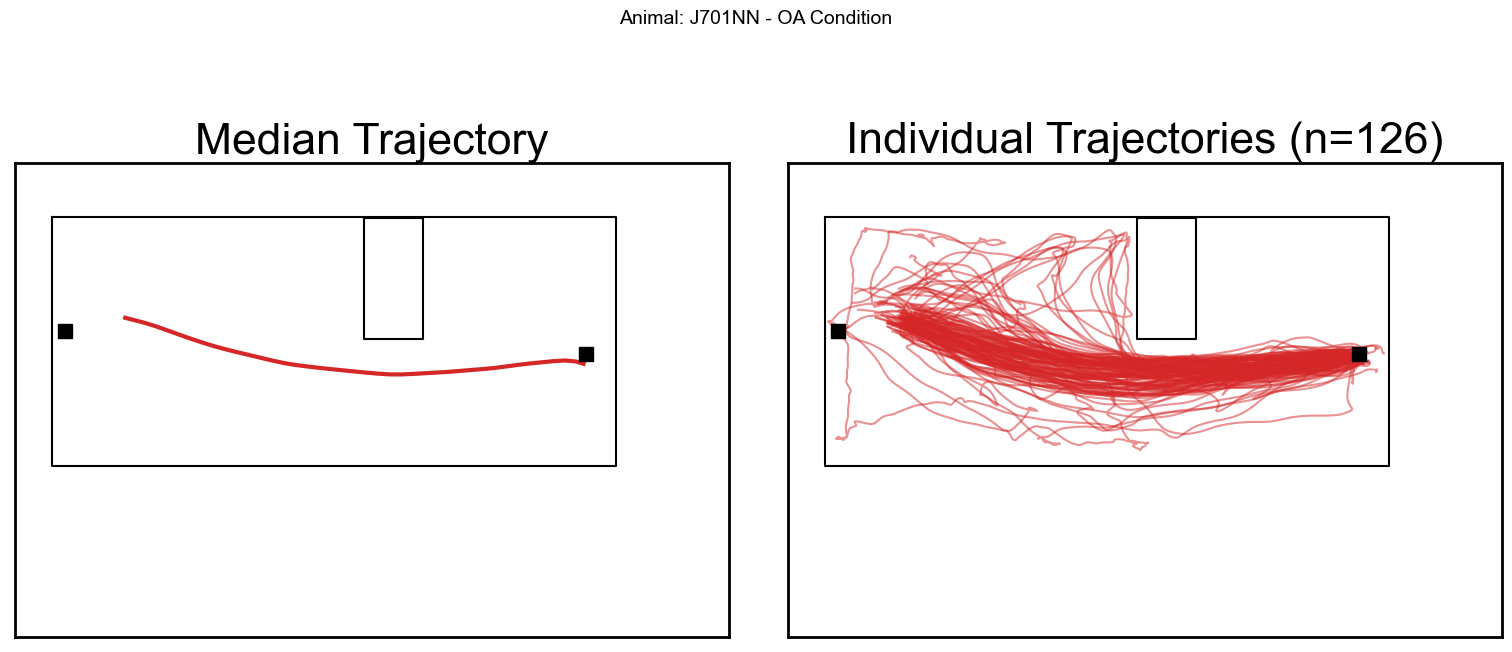

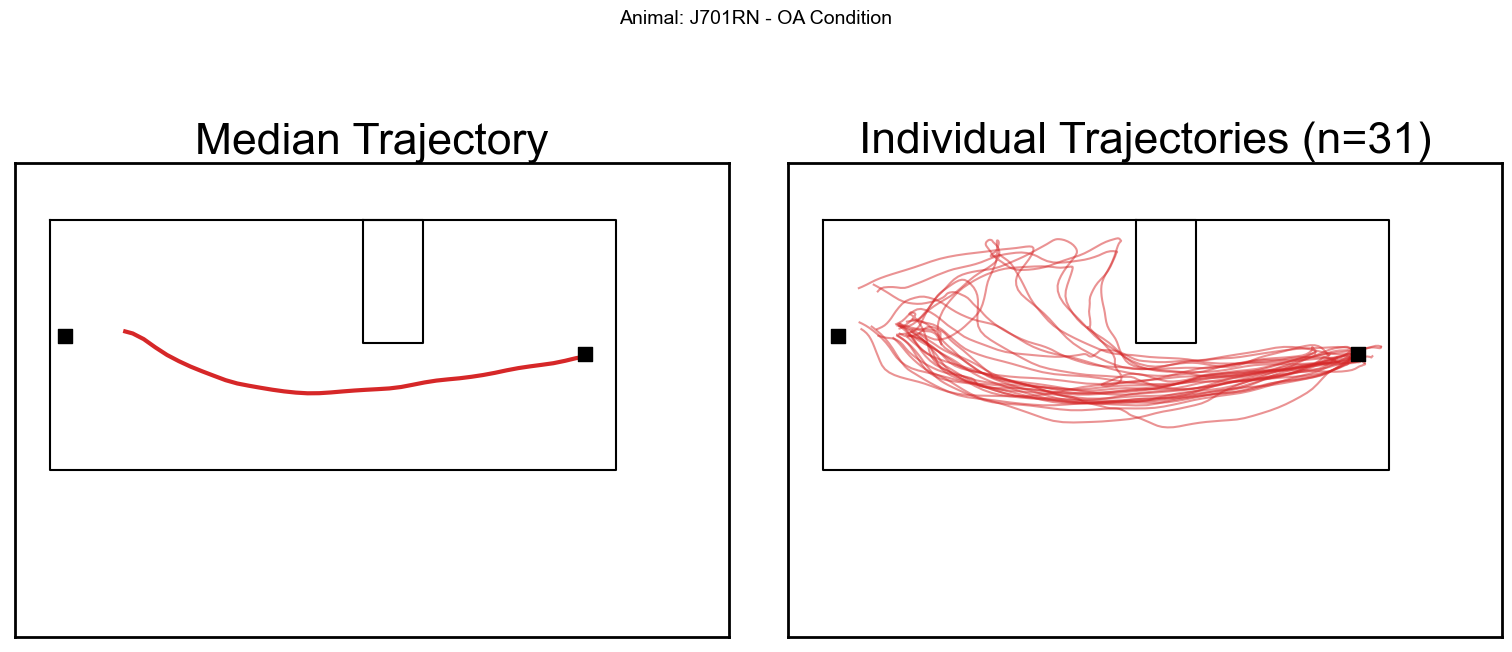

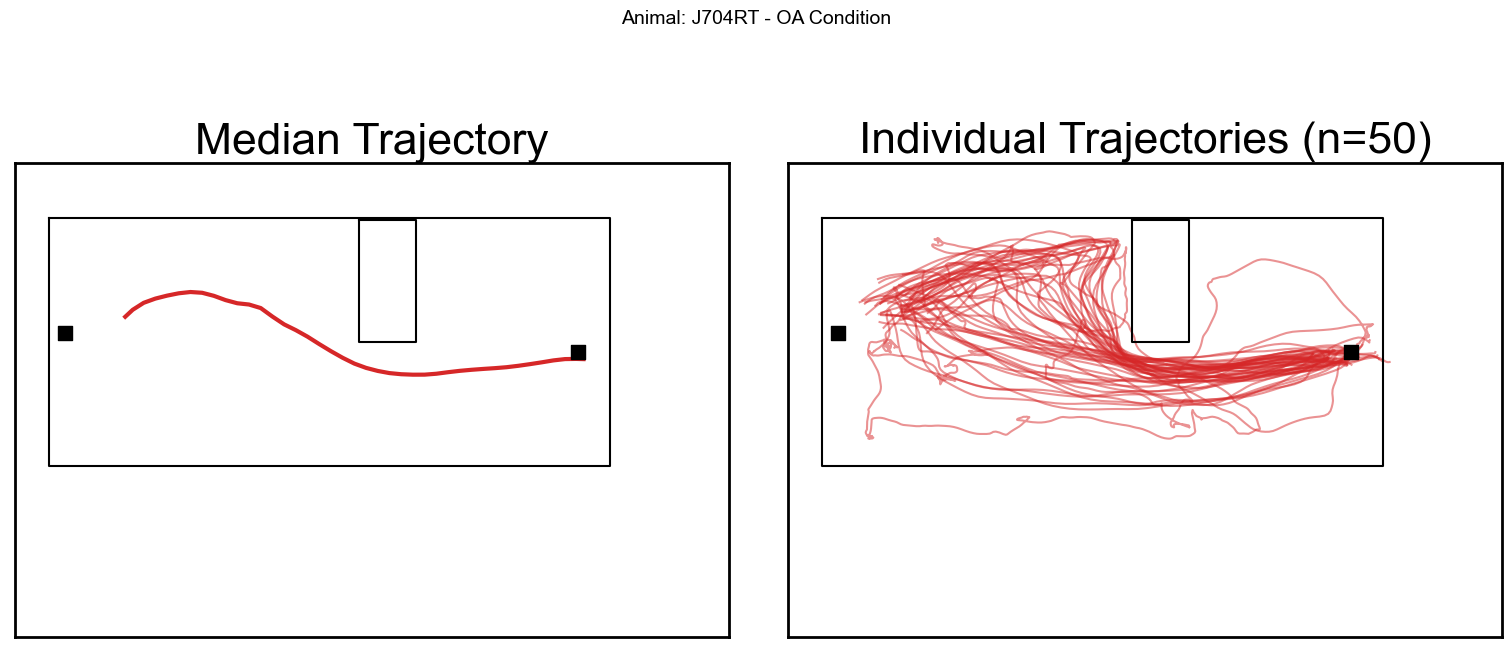

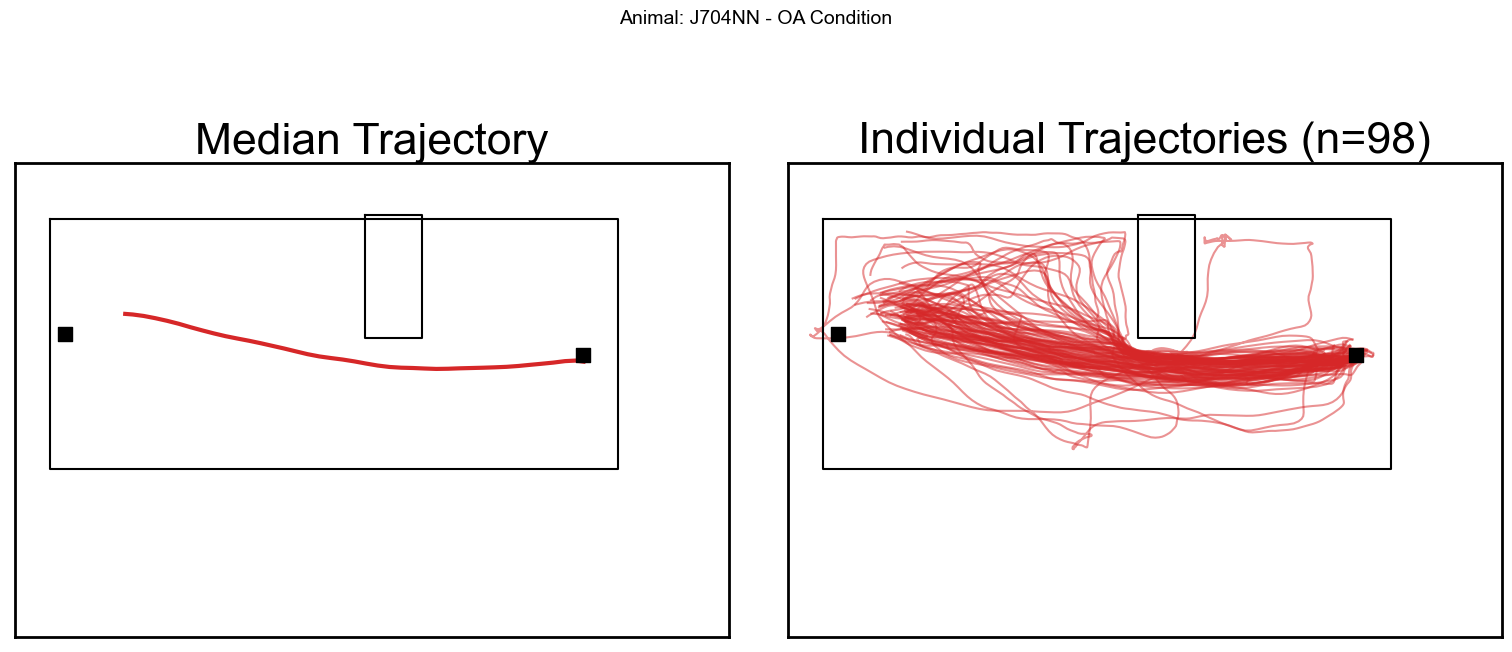

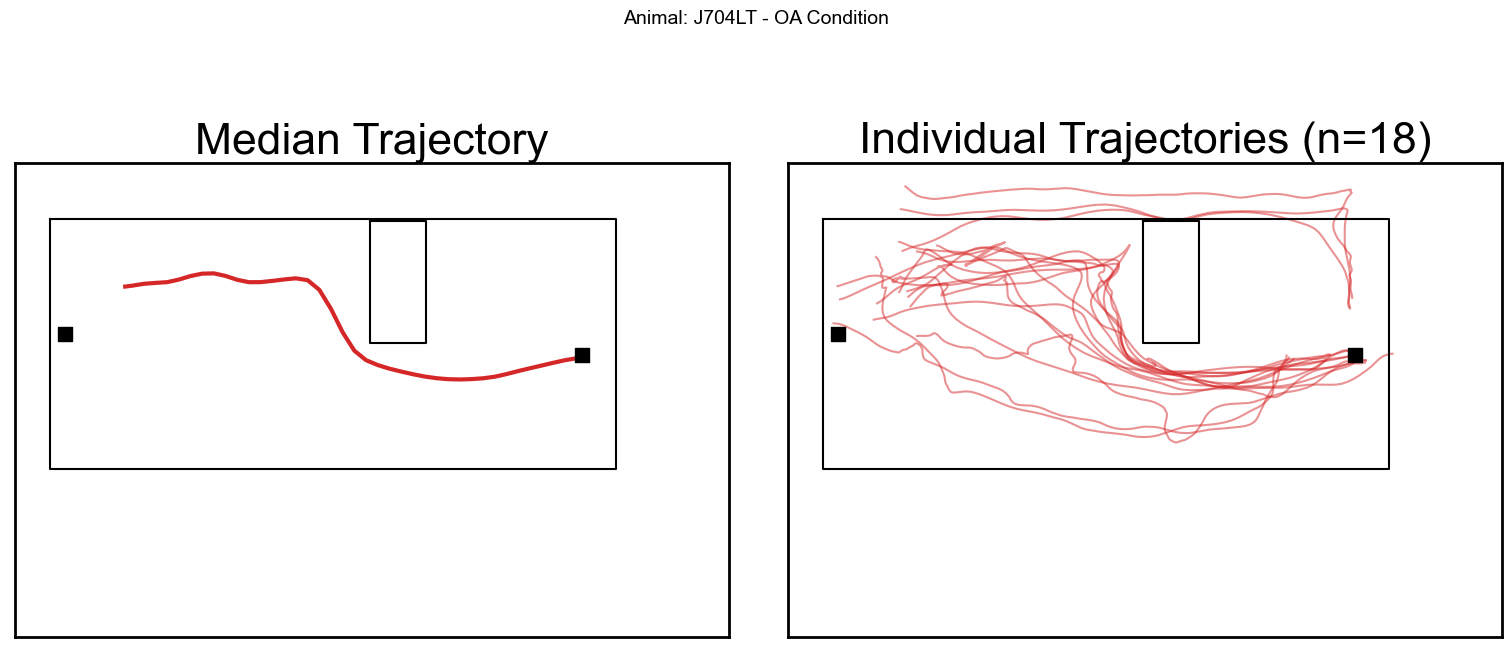

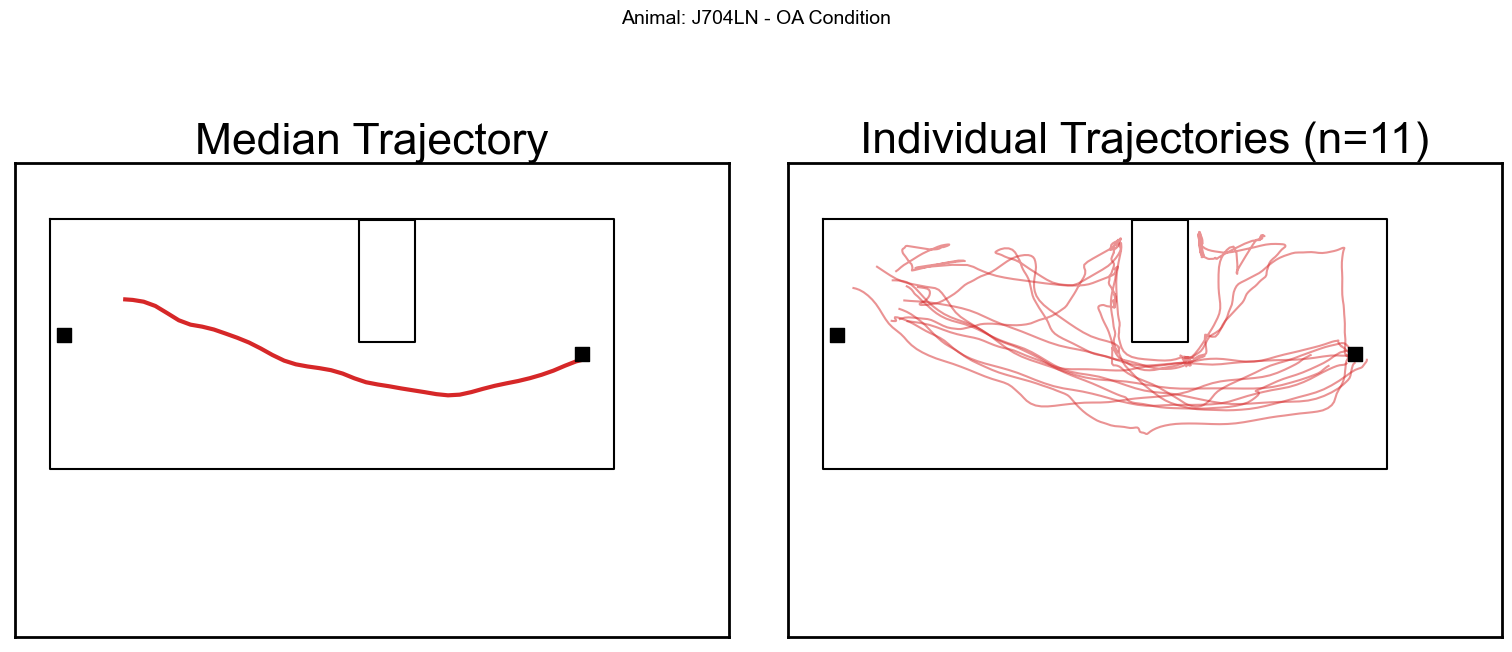

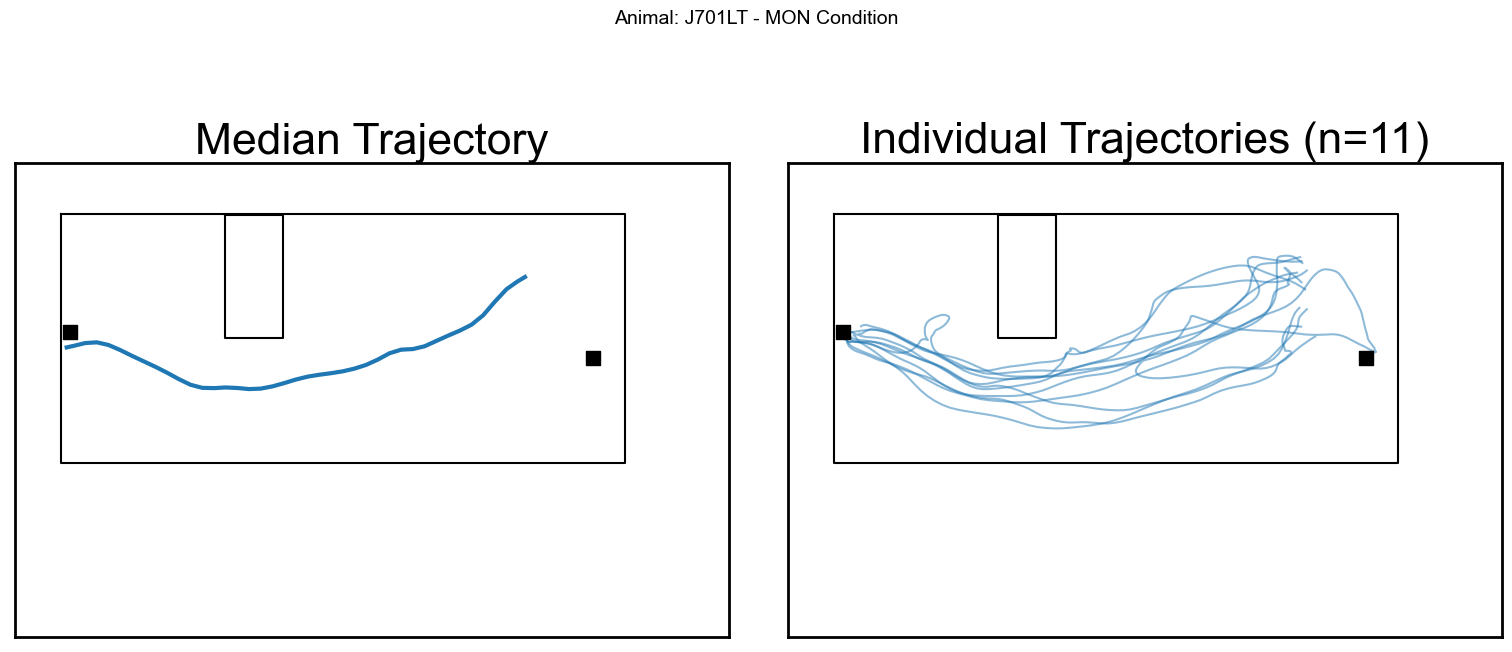

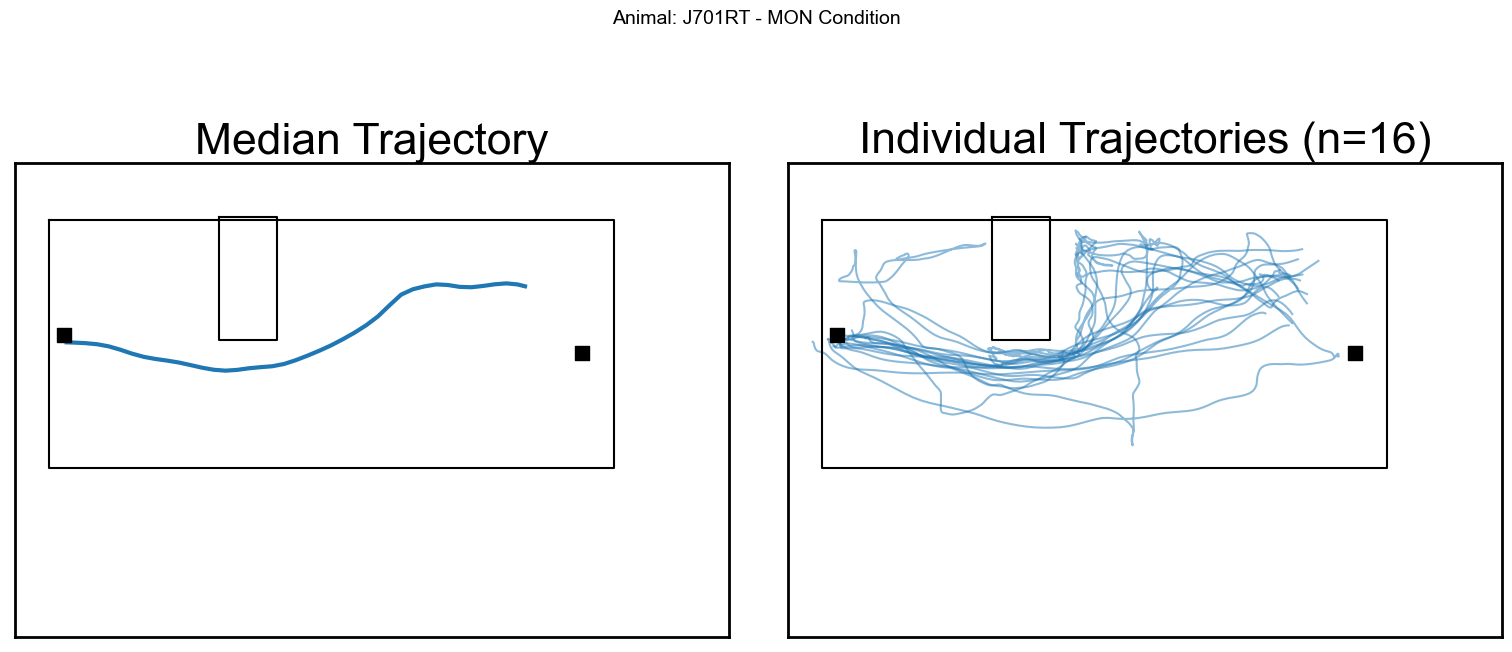

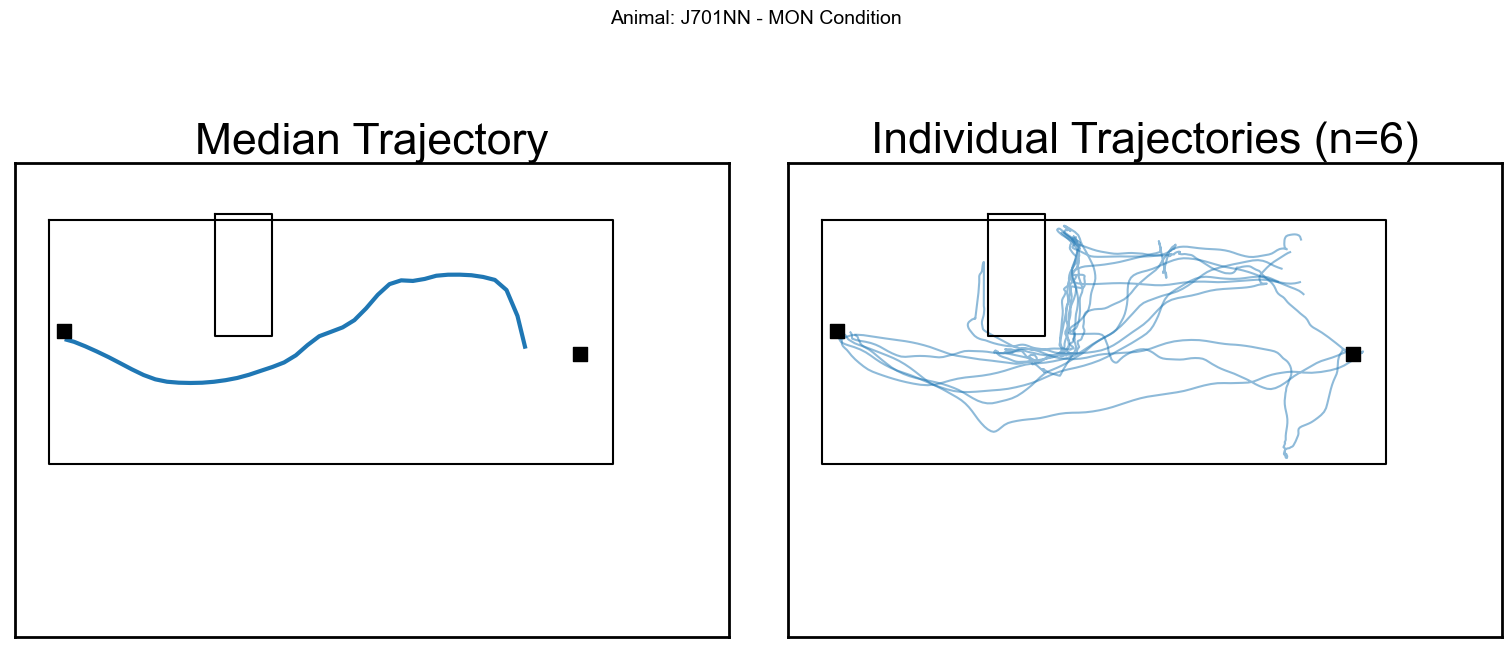

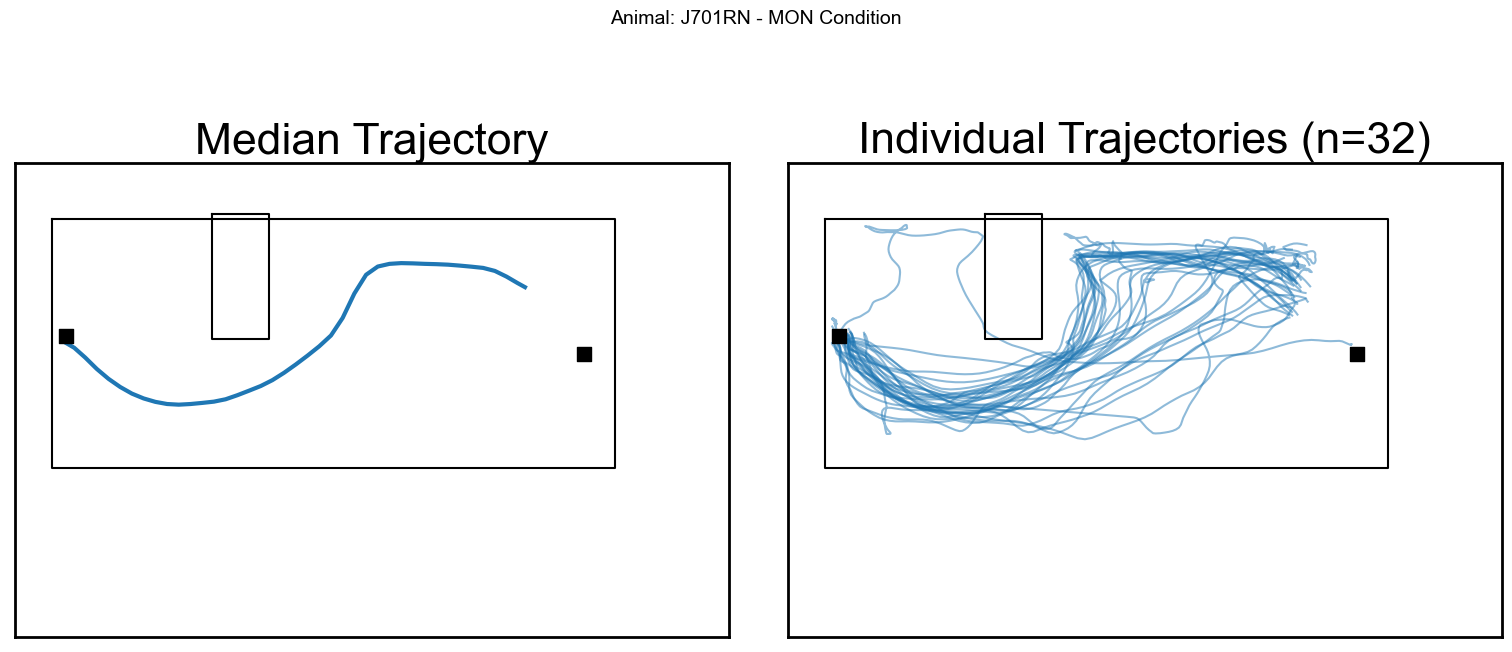

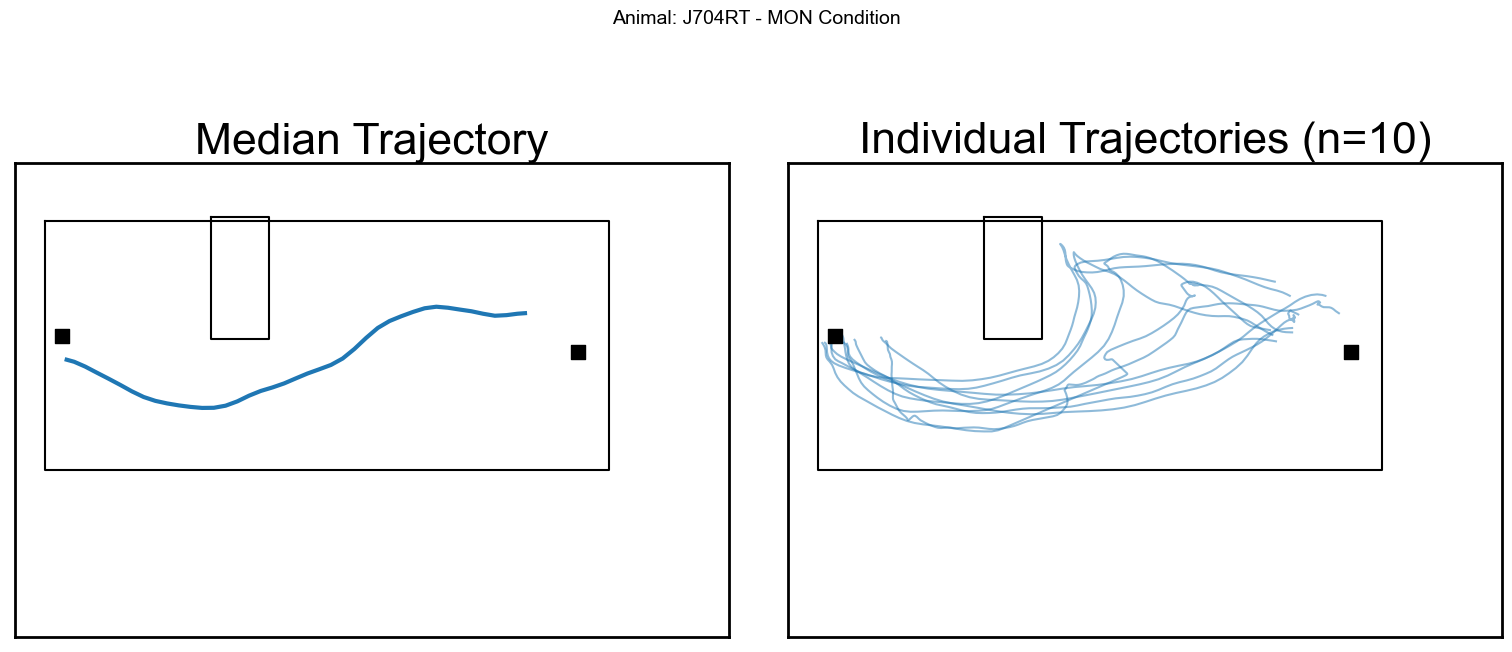

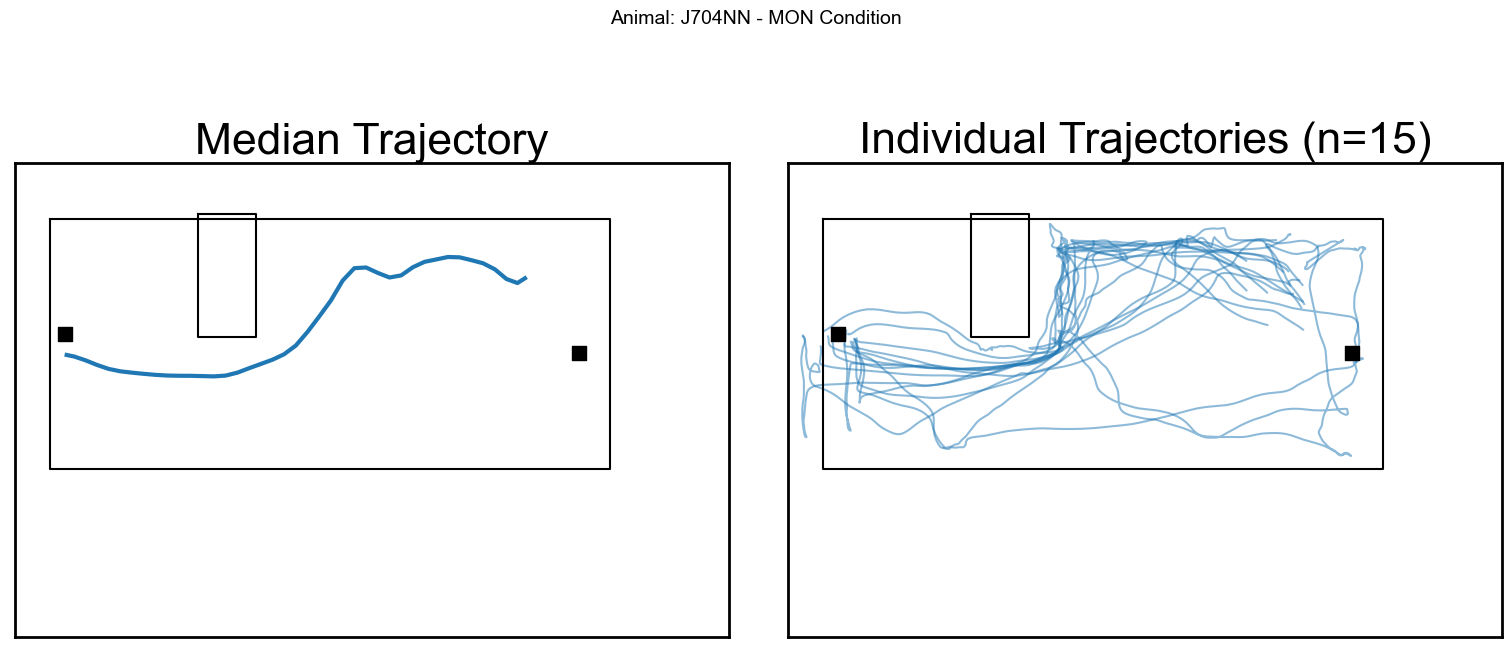

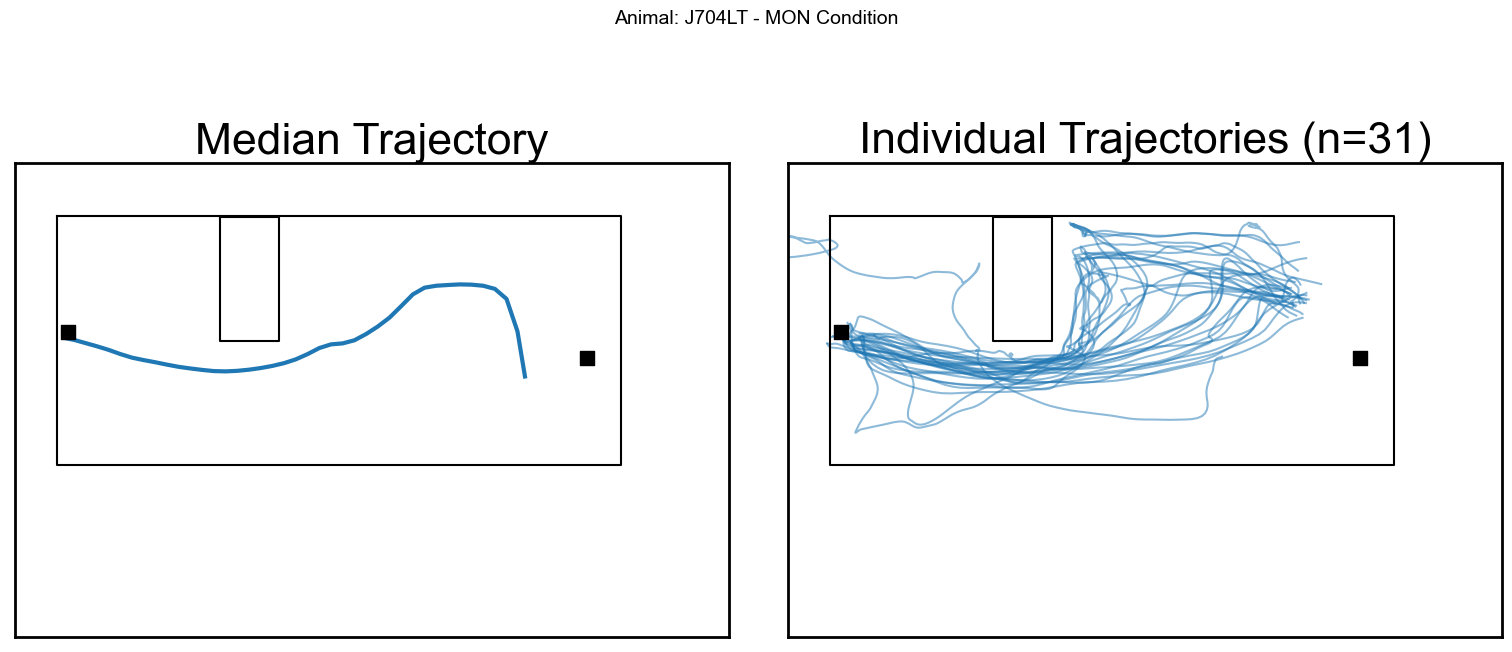

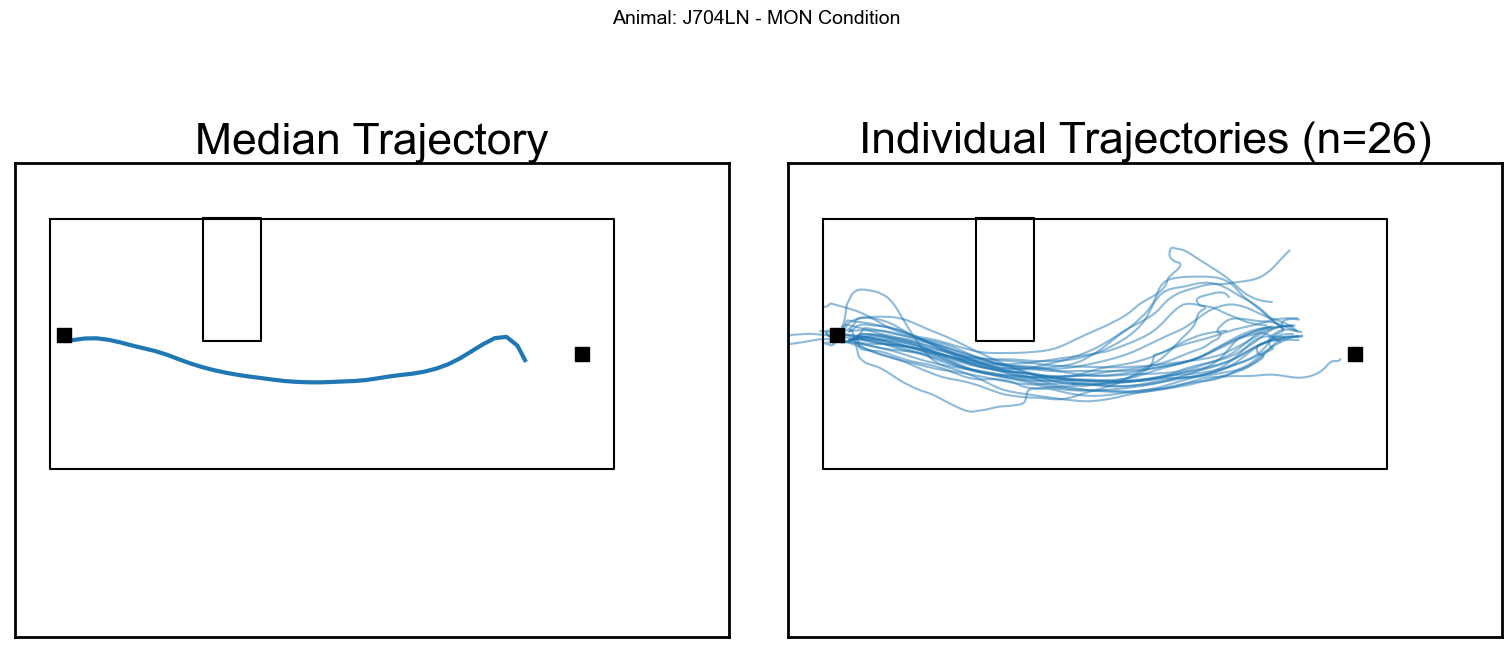

In [537]:
# First figure - OA condition (per animal)
data = mon
data = data[data.task=='oamonle']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

# Plot OA condition
oa_df = data[(data.obstacle_cluster == 1)&(data.task == 'oamonle')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'right')]

# Get unique animals
animals = oa_df['animal'].unique()

# Create plots for each animal
for animal in animals:
    animal_df = oa_df[oa_df['animal'] == animal]
    
    # Skip if no data for this animal
    if len(animal_df) == 0:
        continue
        
    # Create figure with two subplots
    fig, (ax_median, ax_individual) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Animal: {animal} - OA Condition', fontsize=14)
    
    # Set up both subplots
    for ax in [ax_median, ax_individual]:
        ax.set_xticks([])
        ax.set_yticks([])
        plot_arena(animal_df, ax)
        ob_x, ob_y = plot_orginal_obstacle(animal_df, ax, 5)
    
    # MEDIAN TRAJECTORY PLOT
    animal_nose_y, animal_nose_x = get_median_trajectory(animal_df, 'ts_nose_x_cm', 'ts_nose_y_cm', 
                                                      turn_direction_key='turn_direction_left_right',
                                                      start_position_key='start',
                                                      return_matrix=False)
    animal_nose_x = smooth(animal_nose_x)
    animal_nose_y = smooth(animal_nose_y)
    ax_median.plot(animal_nose_x, animal_nose_y, linewidth=3, c='tab:red', zorder=0)
    ax_median.set_title('Median Trajectory')
    
    # INDIVIDUAL TRAJECTORIES PLOT
    for _, row in animal_df.iterrows():
        x, y = correct_trace(row, ob_x, ob_y)
        ax_individual.plot(x, y, alpha=0.5, c='tab:red', zorder=0)
    ax_individual.set_title(f'Individual Trajectories (n={len(animal_df)})')
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Second figure - MON condition (per animal)
mon_df = data[(data.obstacle_cluster == 0)&(data.task == 'oamonle')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'left')]

# Get unique animals
animals = mon_df['animal'].unique()

# Create plots for each animal
for animal in animals:
    animal_df = mon_df[mon_df['animal'] == animal]
    
    # Skip if no data for this animal
    if len(animal_df) == 0:
        continue
        
    # Create figure with two subplots
    fig, (ax_median, ax_individual) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Animal: {animal} - MON Condition', fontsize=14)
    
    # Set up both subplots
    for ax in [ax_median, ax_individual]:
        ax.set_xticks([])
        ax.set_yticks([])
        plot_arena(animal_df, ax)
        ob_x, ob_y = plot_orginal_obstacle(animal_df, ax, 5)
    
    # MEDIAN TRAJECTORY PLOT
    animal_nose_y, animal_nose_x = get_median_trajectory(animal_df, 'ts_nose_x_cm', 'ts_nose_y_cm',
                                                        turn_direction_key='turn_direction_left_right',
                                                        start_position_key='start',
                                                        return_matrix=False)
    animal_nose_x = smooth(animal_nose_x)
    animal_nose_y = smooth(animal_nose_y)
    ax_median.plot(animal_nose_x, animal_nose_y, linewidth=3, c='tab:blue', zorder=0)
    ax_median.set_title('Median Trajectory')
    
    # INDIVIDUAL TRAJECTORIES PLOT
    for _, row in animal_df.iterrows():
        x, y = correct_trace(row, ob_x, ob_y)
        ax_individual.plot(x, y, alpha=0.5, c='tab:blue', zorder=0)
    ax_individual.set_title(f'Individual Trajectories (n={len(animal_df)})')
    
    plt.tight_layout()
    plt.show()
    
    # Save figures if needed
    # fig.savefig(f'{animal}_mon_condition.png', dpi=300, transparent=True)
    plt.close(fig)

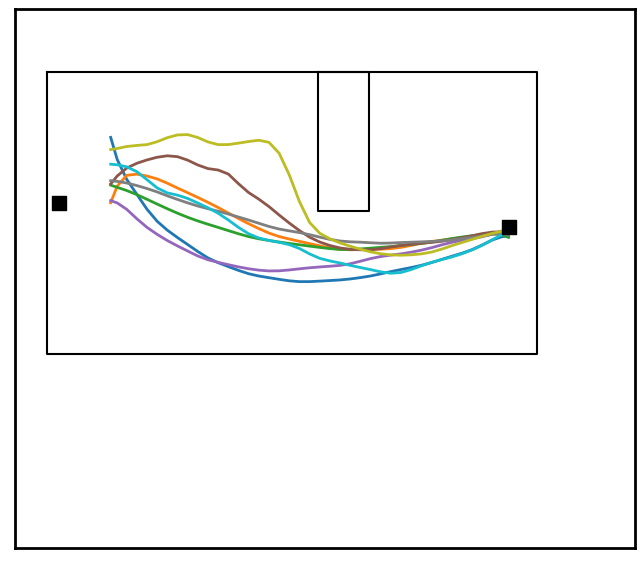

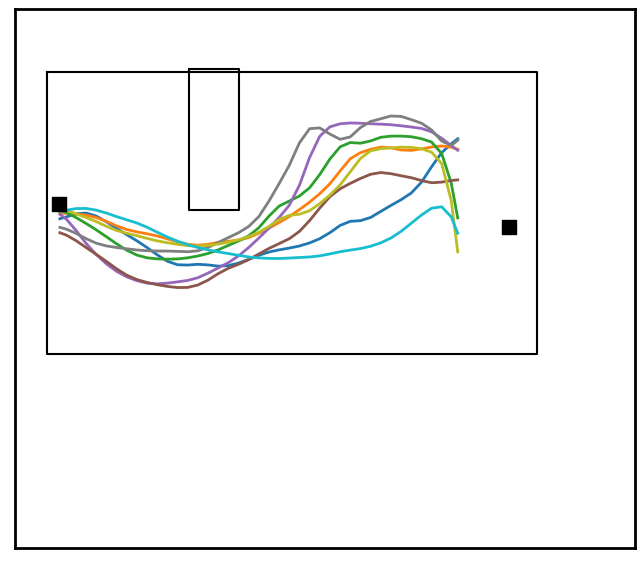

In [533]:
# First figure (OA condition)
fig1, ax1 = plt.subplots(figsize=(8, 7))
data = mon
data = data[data.task=='oamonle']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 

# Plot OA condition
oa_df = data[(data.obstacle_cluster == 1)&(data.task == 'oamonle')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'right')]
ax1.set_xticks([])
ax1.set_yticks([])
plot_arena(oa_df, ax1)
ob_x, ob_y = plot_orginal_obstacle(oa_df, ax1, 5)

# Get unique animals
animals = oa_df['animal'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(animals)))  # Different color for each animal

# Plot median trajectory for each animal
for animal, color in zip(animals, colors):
    animal_df = oa_df[oa_df['animal'] == animal]
    if len(animal_df) > 0:  # Only plot if there's data
        animal_nose_y, animal_nose_x = get_median_trajectory(animal_df, 'ts_nose_x_cm', 'ts_nose_y_cm', 
                                                          turn_direction_key='turn_direction_left_right',
                                                          start_position_key='start',
                                                          return_matrix=False)
        animal_nose_x = smooth(animal_nose_x)
        animal_nose_y = smooth(animal_nose_y)
        ax1.plot(animal_nose_x, animal_nose_y, linewidth=2, c=color, zorder=0, label=animal)

# Add legend
#ax1.legend()

plt.show()
plt.close(fig1)

# Second figure (MON condition)
fig2, ax2 = plt.subplots(figsize=(8, 7))
mon_df = data[(data.obstacle_cluster == 0)&(data.task == 'oamonle')&(data.obstacle_cross == True)&(data.turn_direction_left_right == 'left')]
ax2.set_xticks([])
ax2.set_yticks([])
plot_arena(mon_df, ax2)
ob_x, ob_y = plot_orginal_obstacle(mon_df, ax2, 5)

# Get unique animals
animals = mon_df['animal'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(animals)))  # Different color for each animal

# Plot median trajectory for each animal
for animal, color in zip(animals, colors):
    animal_df = mon_df[mon_df['animal'] == animal]
    if len(animal_df) > 0:  # Only plot if there's data
        animal_nose_y, animal_nose_x = get_median_trajectory(animal_df, 'ts_nose_x_cm', 'ts_nose_y_cm',
                                                          turn_direction_key='turn_direction_left_right',
                                                          start_position_key='start',
                                                          return_matrix=False)
        animal_nose_x = smooth(animal_nose_x)
        animal_nose_y = smooth(animal_nose_y)
        ax2.plot(animal_nose_x, animal_nose_y, linewidth=2, c=color, zorder=0, label=animal)

# Add legend
#ax2.legend()

plt.show()

# Save figures if needed
# fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_6\right_turn_traces.pdf", dpi=300, transparent=True)
# fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_6\left_turn_traces.pdf", dpi=300, transparent=True)
plt.close(fig1)
plt.close(fig2)

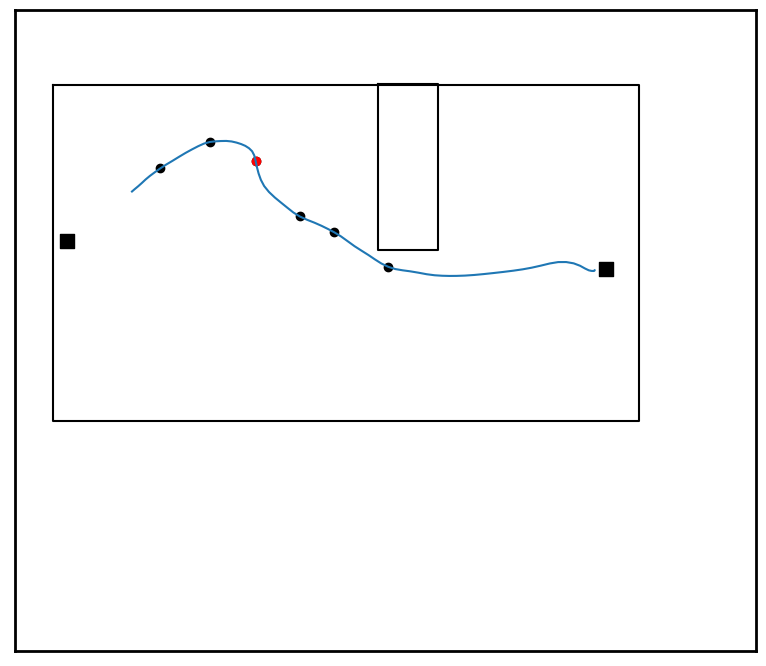

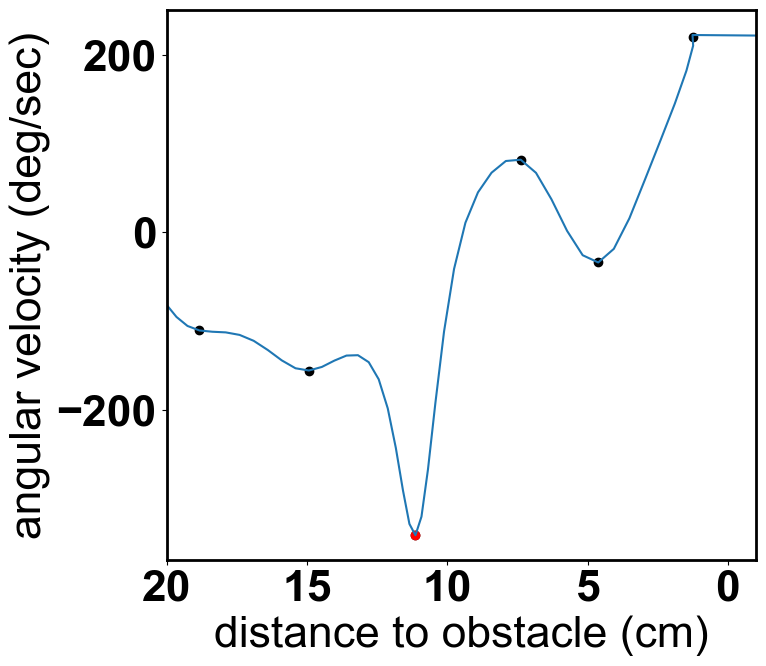

In [336]:
data = pd.concat([mon])
data = data[data.task=='oamonle']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([1])]
data = data[(data.turn_direction_left_right == 'right')]


sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  

for ind, row in sample.iterrows():
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
    ax2.set_xticks([0, 5, 10, 15, 20])
    ax2.set_xlim(-1, 20)

    ax2.invert_xaxis()
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('distance to obstacle (cm)')

    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.indexs_of_head_turn[1])
        peaks = row.head_turn_indexs.tolist()
        
        # Plot on first figure
        ax1.plot(smooth(row.ts_nose_x_cm), smooth(row.ts_nose_y_cm), color='tab:blue')
        ax1.scatter(smooth(row.ts_nose_x_cm)[peaks], smooth(row.ts_nose_y_cm)[peaks], color='black')
        ax1.scatter(smooth(row.ts_nose_x_cm)[thresh], smooth(row.ts_nose_y_cm)[thresh], color='red')
        
        # Plot on second figure
        ax2.plot(row.ts_distance_from_edge[:ob_ind], smooth(row.head_angle_velocity[:ob_ind])*60, color='tab:blue')
        ax2.scatter(row.ts_distance_from_edge[:ob_ind][peaks], smooth(row.head_angle_velocity)[peaks]*60, color='black')
        ax2.scatter(row.ts_distance_from_edge[:ob_ind][thresh], smooth(row.head_angle_velocity)[thresh]*60, color='red')

#fig1.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\light_headturn_trace.pdf",dpi = 300, transparent=True)

#fig2.savefig(r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_5\light_angular_velocity_trace.pdf",dpi = 300, transparent=True)

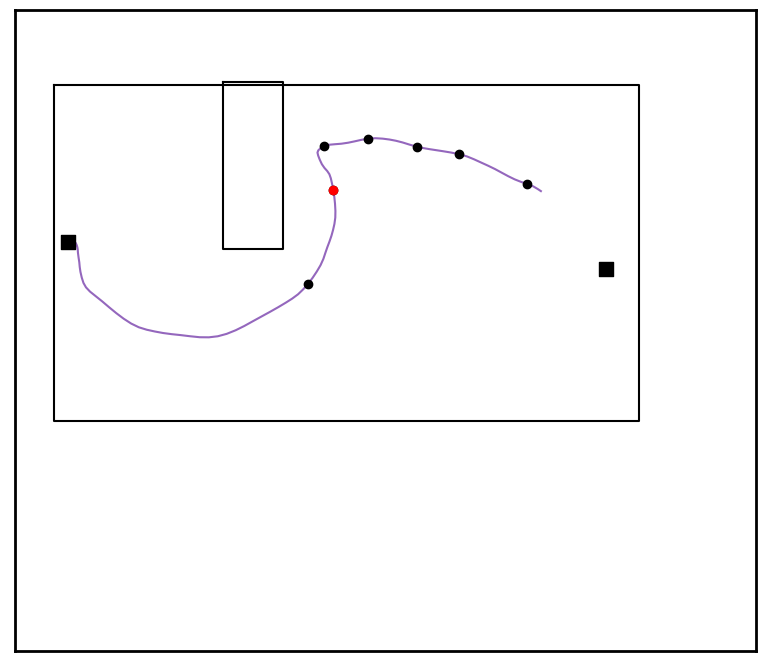

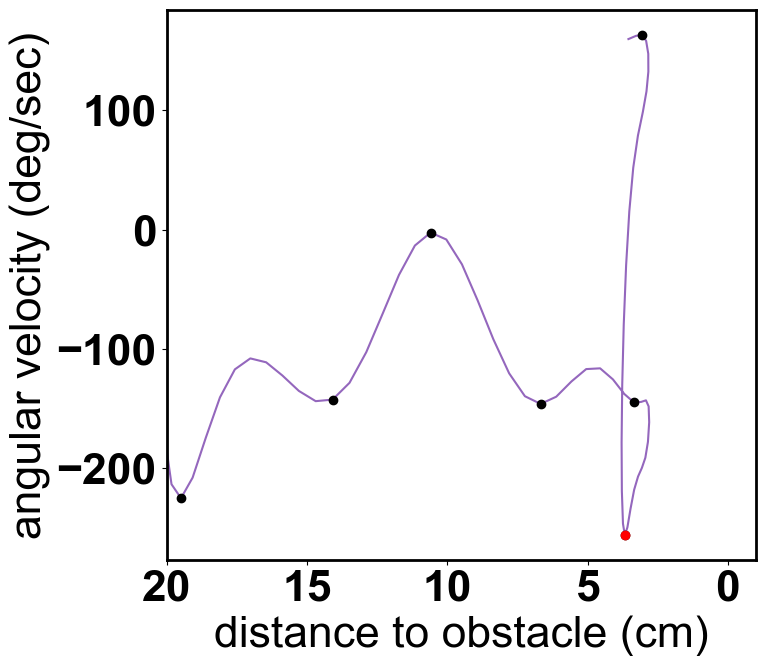

In [347]:
data = pd.concat([mon])
data = data[data.task=='oamonle']
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data['obstacle_cluster'].isin([0])]
data = data[(data.turn_direction_left_right == 'left')]
data = data[(data.obstacle_cross == True)]



#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  

for ind, row in sample.iterrows():
    # Create first figure (arena plot)
    fig1, ax1 = plt.subplots(figsize=(8, 7), layout='tight')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plot_arena(data, ax1)
    plot_orginal_obstacle(data, ax1, int(row.obstacle_cluster))
    
    # Create second figure (angular velocity plot)
    fig2, ax2 = plt.subplots(figsize=(8, 7), layout='tight')
    ax2.set_xticks([0, 5, 10, 15, 20,21])
    ax2.set_xlim(-1, 20)

    ax2.invert_xaxis()
    ax2.set_ylabel('angular velocity (deg/sec)')
    ax2.set_xlabel('distance to obstacle (cm)')

    trial_df = data.loc[[ind]]
    
    for ind, row in trial_df.iterrows():
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.indexs_of_head_turn[1])
        peaks = row.head_turn_indexs.tolist()
        
        # Plot on first figure
        ax1.plot(smooth(row.ts_nose_x_cm), smooth(row.ts_nose_y_cm), color='tab:purple', zorder=0)
        ax1.scatter(smooth(row.ts_nose_x_cm)[peaks], smooth(row.ts_nose_y_cm)[peaks], color='black')
        ax1.scatter(smooth(row.ts_nose_x_cm)[thresh], smooth(row.ts_nose_y_cm)[thresh], color='red')
       
        
        # Plot on second figure
        ax2.plot(row.ts_distance_from_edge[:ob_ind], smooth(row.head_angle_velocity[:ob_ind])*60, color='tab:purple', zorder=0)
        ax2.scatter(row.ts_distance_from_edge[:ob_ind][peaks], smooth(row.head_angle_velocity)[peaks]*60, color='black')
        ax2.scatter(row.ts_distance_from_edge[:ob_ind][thresh], smooth(row.head_angle_velocity)[thresh]*60, color='red')

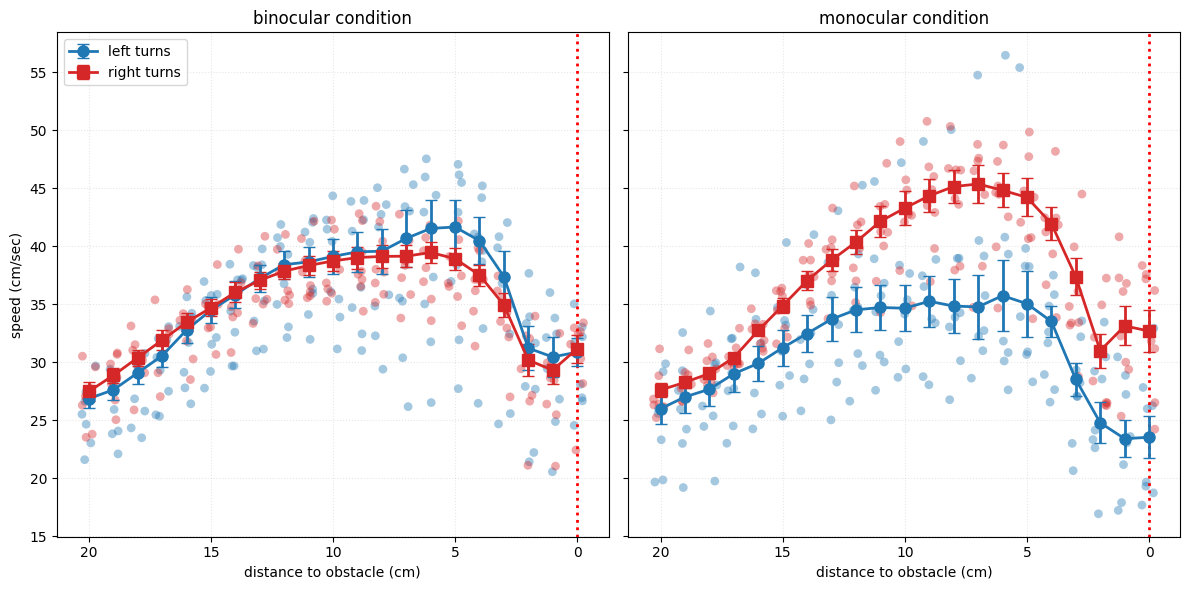

In [13]:
xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), layout='tight', sharey=True)

# Data processing
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_distance<=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
data = data[data.head_turn_velocity>=0] 

# Subplot formatting - binocular on left, monocular on right
for ax in (ax1, ax2):
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xticks([20,15,10,5,0])
    ax.set_xlabel('distance to obstacle (cm)')
    ax.set_ylabel('speed (cm/sec)')
    ax.axvline(0, color='r', ls=':', linewidth=2)
    ax.grid(True, linestyle=':', alpha=0.3)
    
ax1.set_title('binocular condition')  # Changed order
ax2.set_title('monocular condition')  # Changed order
ax2.set_ylabel('')  # Remove redundant ylabel from right plot

# Jitter parameters
jitter_amount = 0.3

# Define plotting parameters
turn_params = [
    {'direction': 'left', 'color': 'tab:blue', 'marker': 'o', 'label': 'left turns'},
    {'direction': 'right', 'color': 'tab:red', 'marker': 's', 'label': 'right turns'}
]

# [Previous code remains the same until the process_and_plot function]

def process_and_plot(ax, task, params):
    subset = data[(data.turn_direction_left_right == params['direction']) & 
                 (data.task == task)]
    
    all_trajectories = []
    animal_trajectories = {}
    
    for animal, animal_df in subset.groupby('animal'):
        animal_errors = []
        
        for _, row in animal_df.iterrows():
            x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row['ts_speed'][:int(row['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if len(y) > 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                ynew = interpolater(xnew)
                animal_errors.append(ynew)
                all_trajectories.append(ynew)
        
        if animal_errors:
            animal_median = np.nanmedian(animal_errors, axis=0)
            animal_trajectories[animal] = animal_median
            
            x_jittered = xnew + np.random.uniform(-jitter_amount, jitter_amount, size=len(xnew))
            ax.scatter(x_jittered, animal_median, color=params['color'], 
                      alpha=0.4, s=40, edgecolors='none')
    
    if all_trajectories:
        pop_median = np.nanmedian(all_trajectories, axis=0)
        animal_medians = list(animal_trajectories.values())
        
        # Calculate SEM instead of SD
        sem = np.nanstd(animal_medians, axis=0) / np.sqrt(len(animal_medians)) if animal_medians else np.zeros(len(xnew))
        
        ax.errorbar(xnew, pop_median, yerr=sem,  # Changed from sd to sem
                  color=params['color'], label=params['label'],
                  linestyle='-', linewidth=2,
                  marker=params['marker'], markersize=8, capsize=4)
# Plot binocular data on LEFT
for params in turn_params:
    process_and_plot(ax1, 'oa', params)

# Plot monocular data on RIGHT
for params in turn_params:
    process_and_plot(ax2, 'oamonle', params)

# Add legend to left plot only
ax1.legend(loc='upper left', framealpha=0.8)



plt.tight_layout()
plt.show()

In [353]:
def goal_port(df):
    for ind,row in df.iterrows():
        ob_ind = int(row.obstacle_ind)
        df.at[ind,'goal_distance_from_target_port'] = row.ts_distance_from_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_angle_to_target_port'] = row.ts_angle_to_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_lateral_error_to_target_port'] = row.ts_lateral_error_to_target_port[ob_ind:].astype(object)

In [354]:
goal_port(mon)

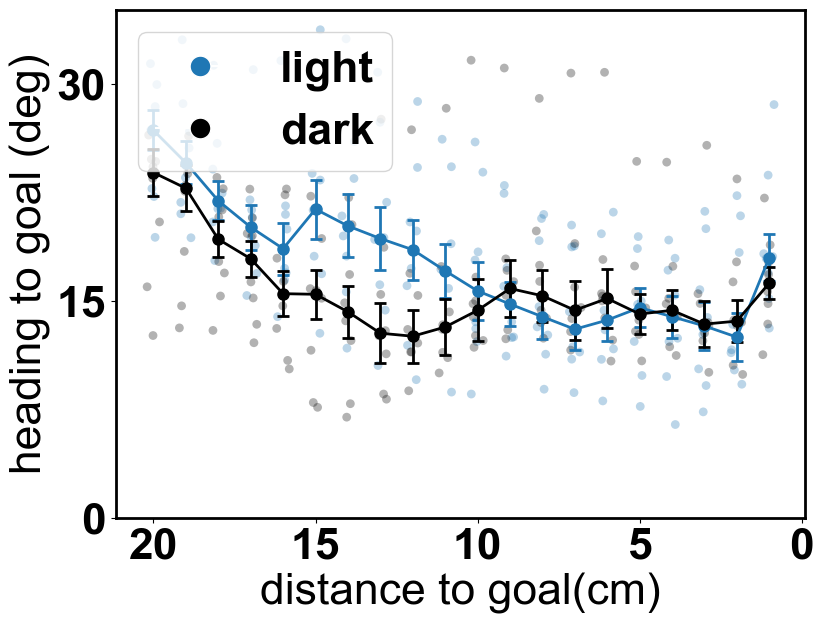

In [355]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 
data = data[data.task=='oamonle'] 

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['turn_direction_left_right']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'left':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))


# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,15,30])
ax.set_ylabel('heading to goal (deg)', fontsize=32)
ax.set_xlabel('distance to goal(cm)', fontsize=32)
#ax.axvline(0, color='r', ls=':', linewidth=2)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=32, framealpha=0.8)

# Grid lines for readability


plt.tight_layout()
plt.show()

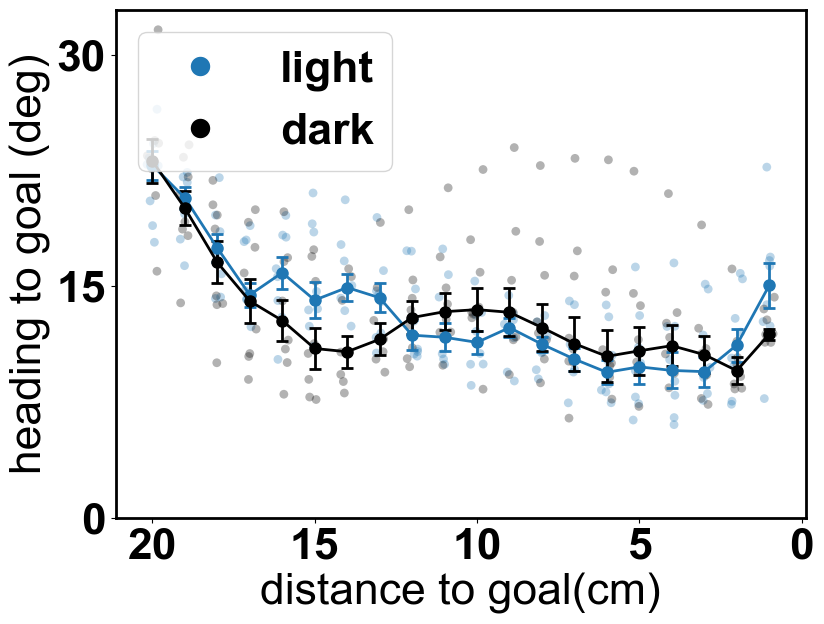

In [356]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 
data = data[data.task=='oa'] 

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['turn_direction_left_right']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'left':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))


# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,15,30])
ax.set_ylabel('heading to goal (deg)', fontsize=32)
ax.set_xlabel('distance to goal(cm)', fontsize=32)
#ax.axvline(0, color='r', ls=':', linewidth=2)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Legend with matching style
# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=32, framealpha=0.8)

# Grid lines for readability


plt.tight_layout()
plt.show()

In [351]:
def calculate_relative_distance_goal_ts2(df):
    '''Calculates change in distance from nose to goal port using:
    - Absolute x-distance (nose_x - port_x)
    - Only first occurrence of each x-position'''
    
    for direction, direction_frame in df.groupby(['odd']):
        for ind, row in direction_frame.iterrows():  
            try:
                nose_x = row['ts_nose_x_cm'].astype(float)
                processed_x = set()  # Track seen x positions
                
                if direction == 'right':
                    port_x_tar = np.nanmean([row['leftportB_x_cm'], row['leftportT_x_cm']])
                    port_x_start = np.nanmean([row['rightportB_x_cm'], row['rightportT_x_cm']])
                else:
                    port_x_tar = np.nanmean([row['rightportB_x_cm'], row['rightportT_x_cm']])
                    port_x_start = np.nanmean([row['leftportB_x_cm'], row['leftportT_x_cm']])
                
                distances_tar = []
                distances_start = []
                
                for i, x in enumerate(nose_x):
                    if x not in processed_x:  # Only process first occurrence
                        processed_x.add(x)
                        # Calculate absolute x-distances
                        distance_tar = abs(x - port_x_tar)
                        distance_start = abs(x - port_x_start)
                        distances_tar.append(distance_tar)
                        distances_start.append(distance_start)
                
                df.at[ind, 'ts_distance_from_target_port'] = np.array(distances_tar).astype(object)
                df.at[ind, 'ts_distance_from_start_port'] = np.array(distances_start).astype(object)
                
            except (KeyError, TypeError, ValueError) as e:
                # Store NaN arrays if any error occurs
                df.at[ind, 'ts_distance_from_target_port'] = np.array([np.nan]).astype(object)
                df.at[ind, 'ts_distance_from_start_port'] = np.array([np.nan]).astype(object)
    

In [352]:
calculate_relative_distance_goal_ts2(mon)

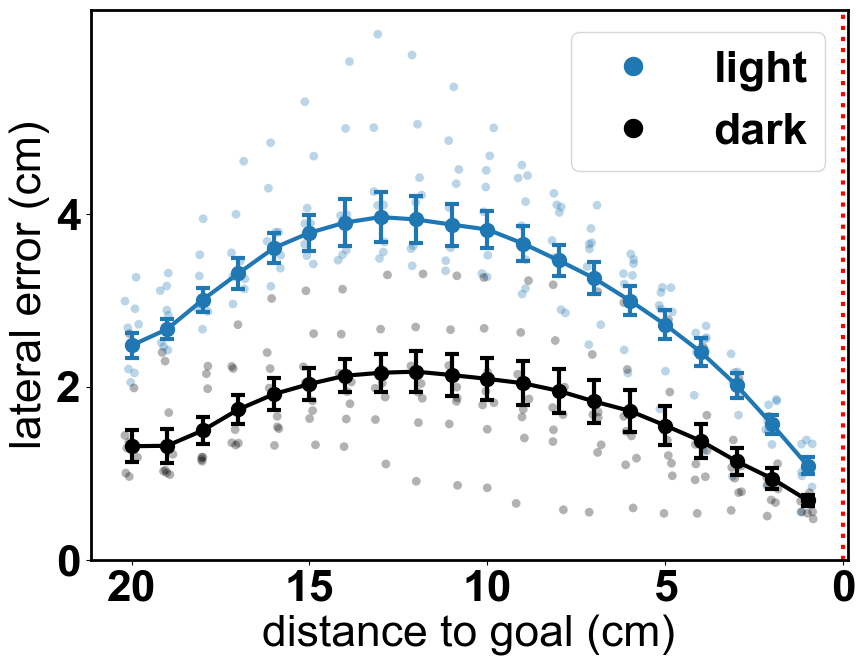

In [358]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))
ax.invert_xaxis()
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 
data = data[data.task=='oa'] 

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['turn_direction_left_right']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_lateral_error_to_target_port'].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'left':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_lateral_error_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'left':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)


light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([4,2,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to goal (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)


# Legend with larger markers matching previous plots
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)
ax.legend(handles=legend_handles, loc='upper right', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()

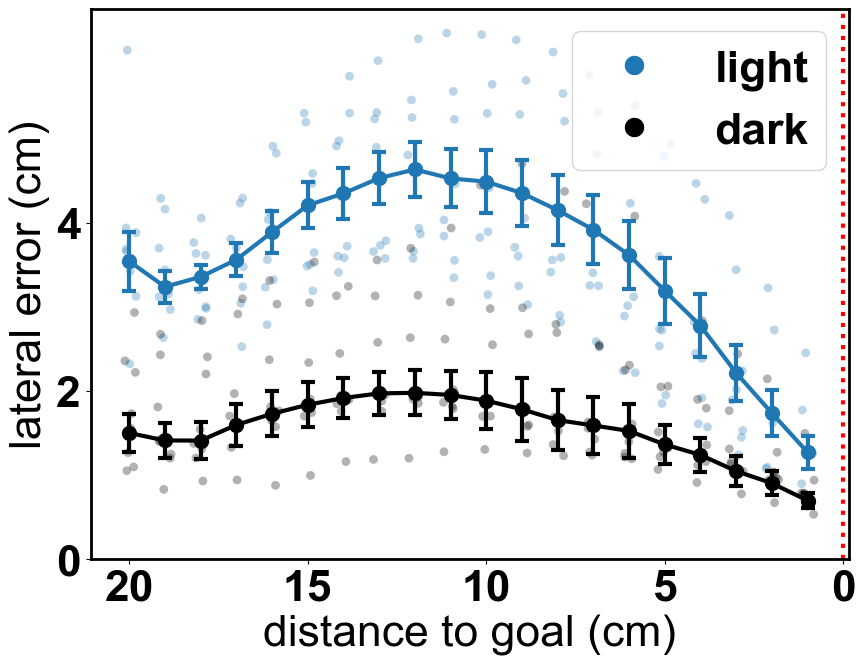

In [359]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))
ax.invert_xaxis()
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 
data = data[data.task=='oamonle'] 

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['turn_direction_left_right']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_lateral_error_to_target_port'].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'left':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_lateral_error_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'left':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)


light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([4,2,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to goal (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)


# Legend with larger markers matching previous plots
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)
ax.legend(handles=legend_handles, loc='upper right', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()

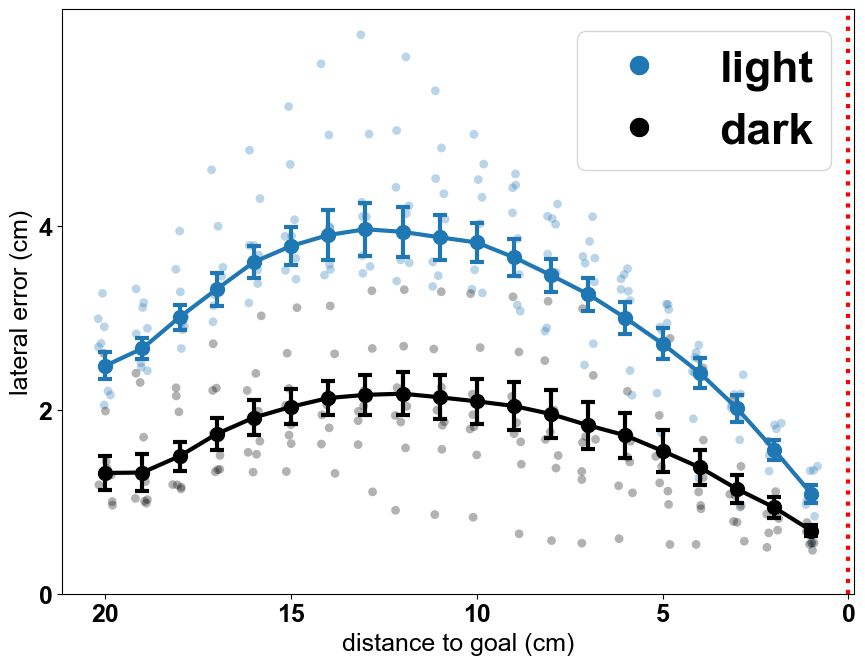

In [27]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))
ax.invert_xaxis()
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 
data = data[data.task=='oa'] 

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['turn_direction_left_right']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_target_port'].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_lateral_error_to_target_port'].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'left':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_target_port'].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_lateral_error_to_target_port'].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'left':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)


light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([4,2,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to goal (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)


# Legend with larger markers matching previous plots
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)
ax.legend(handles=legend_handles, loc='upper right', fontsize=32, framealpha=0.8)

plt.tight_layout()
plt.show()

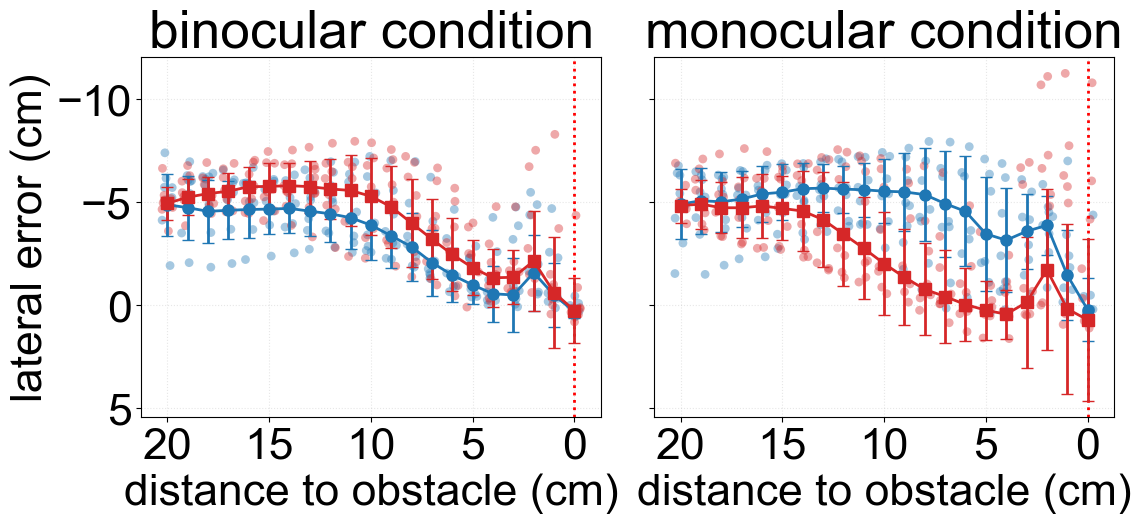

In [10]:
xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), layout='tight', sharey=True)

# Data processing
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 


# Subplot formatting - binocular on left, monocular on right
for ax in (ax1, ax2):
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xticks([20,15,10,5,0])
    ax.set_xlabel('distance to obstacle (cm)')
    ax.set_ylabel('lateral error (cm)')
    ax.axvline(0, color='r', ls=':', linewidth=2)
    ax.grid(True, linestyle=':', alpha=0.3)
    
ax1.set_title('binocular condition')  # Changed order
ax2.set_title('monocular condition')  # Changed order
ax2.set_ylabel('')  # Remove redundant ylabel from right plot

# Jitter parameters
jitter_amount = 0.3

# Define plotting parameters
turn_params = [
    {'direction': 'left', 'color': 'tab:blue', 'marker': 'o', 'label': 'left turns'},
    {'direction': 'right', 'color': 'tab:red', 'marker': 's', 'label': 'right turns'}
]

def process_and_plot(ax, task, params):
    subset = data[(data.turn_direction_left_right == params['direction']) & 
                 (data.task == task)]
    
    all_trajectories = []
    animal_trajectories = {}
    
    for animal, animal_df in subset.groupby('animal'):
        animal_errors = []
        
        for _, row in animal_df.iterrows():
            x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if len(y) > 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                ynew = interpolater(xnew)
                animal_errors.append(ynew)
                all_trajectories.append(ynew)
        
        if animal_errors:
            animal_median = np.nanmedian(animal_errors, axis=0)
            animal_trajectories[animal] = animal_median
            
            x_jittered = xnew + np.random.uniform(-jitter_amount, jitter_amount, size=len(xnew))
            ax.scatter(x_jittered, animal_median, color=params['color'], 
                      alpha=0.4, s=40, edgecolors='none')
    
    if all_trajectories:
        pop_median = np.nanmedian(all_trajectories, axis=0)
        animal_medians = list(animal_trajectories.values())
        sd = np.nanstd(animal_medians, axis=0) if animal_medians else np.zeros(len(xnew))
        
        ax.errorbar(xnew, pop_median, yerr=sd, 
                  color=params['color'], label=params['label'],
                  linestyle='-', linewidth=2,
                  marker=params['marker'], markersize=8, capsize=4)

# Plot binocular data on LEFT
for params in turn_params:
    process_and_plot(ax1, 'oa', params)

# Plot monocular data on RIGHT
for params in turn_params:
    process_and_plot(ax2, 'oamonle', params)

# Add legend to left plot only
#ax1.legend(loc='upper left', framealpha=0.8)

# Ensure y-axis is properly inverted
for ax in (ax1, ax2):
    current_ylim = ax.get_ylim()
    ax.set_ylim(max(current_ylim), min(current_ylim))  # Force inversion

plt.tight_layout()
plt.show()

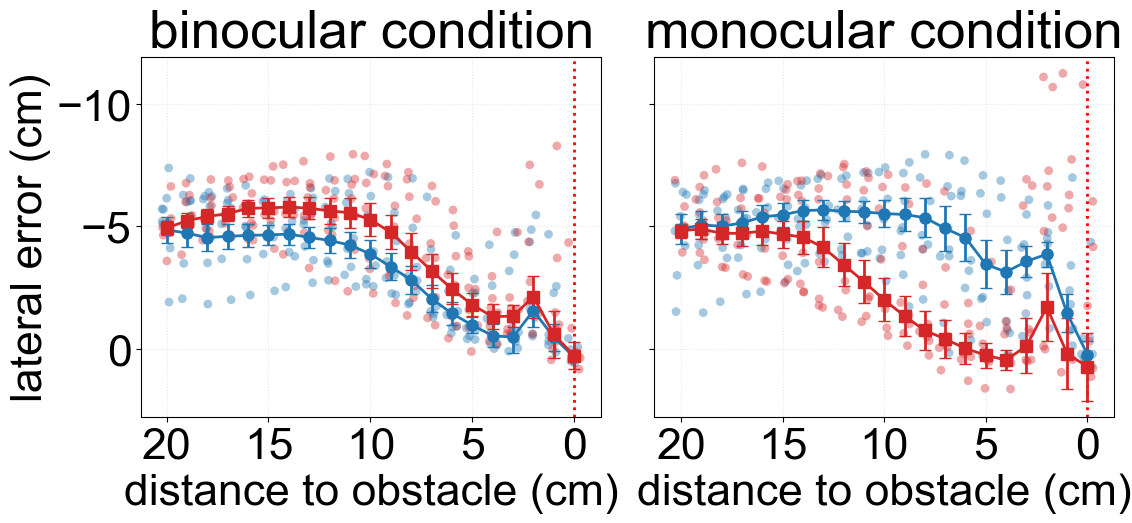

In [11]:
xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), layout='tight', sharey=True)

# Data processing
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 

# Subplot formatting - binocular on left, monocular on right
for ax in (ax1, ax2):
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xticks([20,15,10,5,0])
    ax.set_xlabel('distance to obstacle (cm)')
    ax.set_ylabel('lateral error (cm)')
    ax.axvline(0, color='r', ls=':', linewidth=2)
    ax.grid(True, linestyle=':', alpha=0.3)
    
ax1.set_title('binocular condition')
ax2.set_title('monocular condition')
ax2.set_ylabel('')

# Jitter parameters
jitter_amount = 0.3

# Define plotting parameters
turn_params = [
    {'direction': 'left', 'color': 'tab:blue', 'marker': 'o', 'label': 'left turns'},
    {'direction': 'right', 'color': 'tab:red', 'marker': 's', 'label': 'right turns'}
]

def process_and_plot(ax, task, params):
    subset = data[(data.turn_direction_left_right == params['direction']) & 
                 (data.task == task)]
    
    all_trajectories = []
    animal_trajectories = {}
    
    for animal, animal_df in subset.groupby('animal'):
        animal_errors = []
        
        for _, row in animal_df.iterrows():
            x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if len(y) > 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                ynew = interpolater(xnew)
                animal_errors.append(ynew)
                all_trajectories.append(ynew)
        
        if animal_errors:
            animal_median = np.nanmedian(animal_errors, axis=0)
            animal_trajectories[animal] = animal_median
            
            x_jittered = xnew + np.random.uniform(-jitter_amount, jitter_amount, size=len(xnew))
            ax.scatter(x_jittered, animal_median, color=params['color'], 
                      alpha=0.4, s=40, edgecolors='none')
    
    if all_trajectories:
        pop_median = np.nanmedian(all_trajectories, axis=0)
        animal_medians = list(animal_trajectories.values())
        
        # Calculate SEM instead of SD
        sem = np.nanstd(animal_medians, axis=0) / np.sqrt(len(animal_medians)) if animal_medians else np.zeros(len(xnew))
        
        ax.errorbar(xnew, pop_median, yerr=sem,  # Changed to SEM
                  color=params['color'], label=params['label'],
                  linestyle='-', linewidth=2,
                  marker=params['marker'], markersize=8, capsize=4)

# Plot binocular data on LEFT
for params in turn_params:
    process_and_plot(ax1, 'oa', params)

# Plot monocular data on RIGHT
for params in turn_params:
    process_and_plot(ax2, 'oamonle', params)

# Ensure y-axis is properly inverted
for ax in (ax1, ax2):
    current_ylim = ax.get_ylim()
    ax.set_ylim(max(current_ylim), min(current_ylim))

plt.tight_layout()
plt.show()

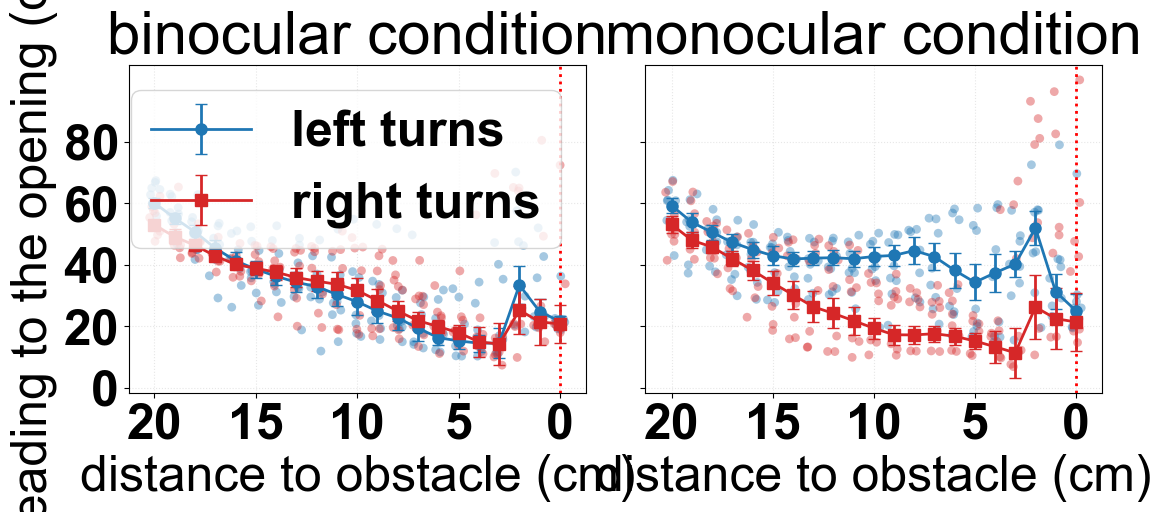

In [86]:
xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), layout='tight', sharey=True)

# Data processing
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 

# Subplot formatting - binocular on left, monocular on right
for ax in (ax1, ax2):
    ax.invert_xaxis()
    ax.set_xticks([20,15,10,5,0])
    ax.set_xlabel('distance to obstacle (cm)')
    ax.axvline(0, color='r', ls=':', linewidth=2)
    ax.grid(True, linestyle=':', alpha=0.3)
    
ax1.set_title('binocular condition')
ax2.set_title('monocular condition')
ax1.set_ylabel('heading to the opening (deg)')

# Jitter parameters
jitter_amount = 0.3

# Define plotting parameters
turn_params = [
    {'direction': 'left', 'color': 'tab:blue', 'marker': 'o', 'label': 'left turns'},
    {'direction': 'right', 'color': 'tab:red', 'marker': 's', 'label': 'right turns'}
]

def process_and_plot(ax, task, params, show_legend=False):
    subset = data[(data.turn_direction_left_right == params['direction']) & 
                 (data.task == task)]
    
    all_trajectories = []
    animal_trajectories = {}
    
    for animal, animal_df in subset.groupby('animal'):
        animal_angles = []
        
        for _, row in animal_df.iterrows():
            x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row['ts_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                ynew = interpolater(xnew)
                animal_angles.append(ynew)
                all_trajectories.append(ynew)
        
        if animal_angles:
            animal_median = np.nanmedian(animal_angles, axis=0)
            animal_trajectories[animal] = animal_median
            
            x_jittered = xnew + np.random.uniform(-jitter_amount, jitter_amount, size=len(xnew))
            ax.scatter(x_jittered, animal_median, color=params['color'], 
                      alpha=0.4, s=40, edgecolors='none')
    
    if all_trajectories:
        pop_median = np.nanmedian(all_trajectories, axis=0)
        animal_medians = list(animal_trajectories.values())
        
        # Calculate SEM instead of SD
        if animal_medians:
            sem = np.nanstd(animal_medians, axis=0) / np.sqrt(len(animal_medians))
        else:
            sem = np.zeros(len(xnew))
        
        ax.errorbar(xnew, pop_median, yerr=sem,  # Changed to SEM
                  color=params['color'], 
                  linestyle='-', linewidth=2,
                  marker=params['marker'], markersize=8, capsize=4,
                  label=params['label'] if show_legend else None)

# Plot binocular data (left plot) with legend
for params in turn_params:
    process_and_plot(ax1, 'oa', params, show_legend=True)

# Plot monocular data (right plot) without legend
for params in turn_params:
    process_and_plot(ax2, 'oamonle', params)

# Add single legend to left plot only
ax1.legend(loc='upper right', framealpha=0.8)

# Set consistent y-ticks (shared via sharey=True)
for ax in (ax1, ax2):
    ax.set_yticks([0,20,40,60,80])

plt.tight_layout()
plt.show()

In [381]:
mon.date_index

AttributeError: 'DataFrame' object has no attribute 'date_index'

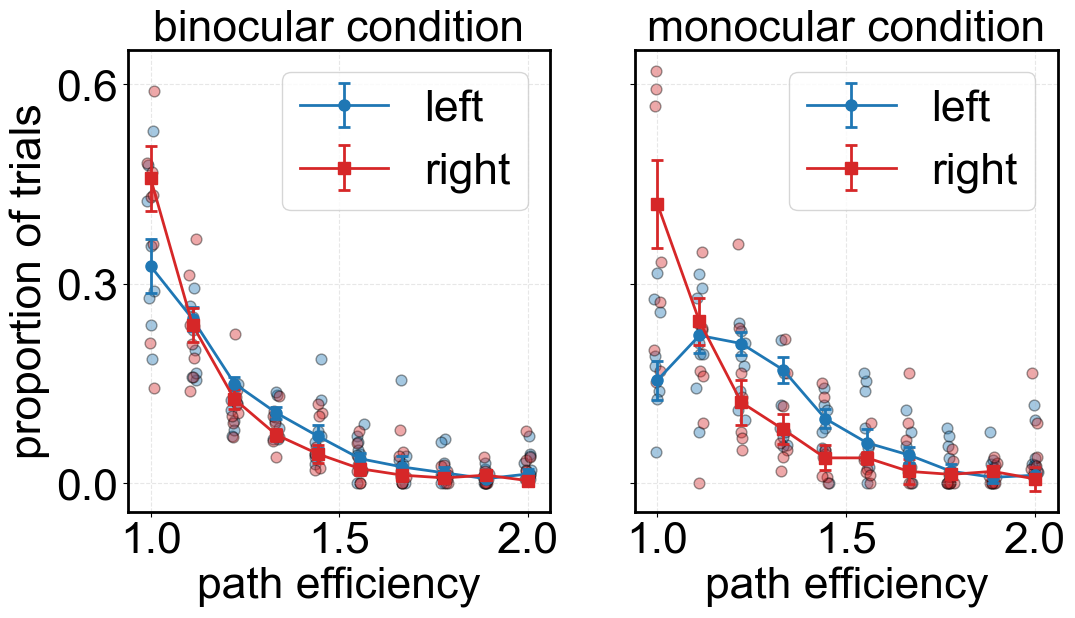

In [380]:
xnew = np.linspace(1, 2, 10)
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 


# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Create main subsets
oa_subset = data[data.task == 'oa']
oamonle_subset = data[data.task == 'oamonle']

# Define plotting parameters
plot_params = [
    {'subset': oa_subset, 'direction': 'left', 'color': 'tab:blue', 'label': 'left', 'ls': '-', 'marker': 'o'},
    {'subset': oa_subset, 'direction': 'right', 'color': 'tab:red', 'label': 'right', 'ls': '-', 'marker': 's'},
    {'subset': oamonle_subset, 'direction': 'left', 'color': 'tab:blue', 'label': 'left', 'ls': '-', 'marker': 'o'},
    {'subset': oamonle_subset, 'direction': 'right', 'color': 'tab:red', 'label': 'right', 'ls': '-', 'marker': 's'}
]

# Jitter parameters for scatter points
jitter_amount = 0.01

# Plot binocular (oa) data on first subplot
for params in plot_params[:2]:
    directional_data = params['subset'][params['subset'].turn_direction_left_right == params['direction']]
    dist = directional_data.tortuosity.round(2).to_numpy()
    dist = dist[np.where((dist <= 2))]
    
    counts, bins = np.histogram(dist, bins=10)
    prob = counts / sum(counts)
    
    animal_probs = []
    animal_data_points = []  # To store individual animal points
    
    for ani, ani_df in directional_data.groupby('animal'):
        ani_dist = ani_df.tortuosity.round(2).to_numpy()
        ani_dist = ani_dist[np.where((ani_dist <= 2))]
        ani_counts, _ = np.histogram(ani_dist, bins=10)
        if sum(ani_counts) > 0:
            ani_prob = ani_counts / sum(ani_counts)
            animal_probs.append(ani_prob)
            
            # Add jittered x-positions for each animal's points
            x_jittered = xnew + np.random.uniform(-jitter_amount, jitter_amount, size=len(xnew))
            
            # Plot individual animal points with some transparency
            ax1.scatter(x_jittered, ani_prob, color=params['color'], 
                       alpha=0.4, s=60, edgecolors='black')
    
    if animal_probs:
        animal_probs = np.array(animal_probs)
        sem = np.std(animal_probs, axis=0) / np.sqrt(len(animal_probs))  # Calculate SEM instead of SD
        
        # Plot mean line with error bars (now using SEM)
        ax1.errorbar(xnew, prob, yerr=sem, 
                   color=params['color'], linestyle=params['ls'],
                   marker=params['marker'], markersize=8,
                   linewidth=2, capsize=4, capthick=2,
                   label=params['label'])

# Plot monocular (oamonle) data on second subplot
for params in plot_params[2:]:
    directional_data = params['subset'][params['subset'].turn_direction_left_right == params['direction']]
    dist = directional_data.tortuosity.round(2).to_numpy()
    dist = dist[np.where((dist <= 2))]
    
    counts, bins = np.histogram(dist, bins=10)
    prob = counts / sum(counts)
    
    animal_probs = []
    
    for ani, ani_df in directional_data.groupby('animal'):
        ani_dist = ani_df.tortuosity.round(2).to_numpy()
        ani_dist = ani_dist[np.where((ani_dist <= 2))]
        ani_counts, _ = np.histogram(ani_dist, bins=10)
        if sum(ani_counts) > 0:
            ani_prob = ani_counts / sum(ani_counts)
            animal_probs.append(ani_prob)
            
            # Add jittered x-positions for each animal's points
            x_jittered = xnew + np.random.uniform(-jitter_amount, jitter_amount, size=len(xnew))
            
            # Plot individual animal points with some transparency
            ax2.scatter(x_jittered, ani_prob, color=params['color'], 
                       alpha=0.4, s=60, edgecolors='black')
    
    if animal_probs:
        animal_probs = np.array(animal_probs)
        sem = np.std(animal_probs, axis=0) / np.sqrt(len(animal_probs))  # Calculate SEM instead of SD
        
        # Plot mean line with error bars (now using SEM)
        ax2.errorbar(xnew, prob, yerr=sem, 
                   color=params['color'], linestyle=params['ls'],
                   marker=params['marker'], markersize=8,
                   linewidth=2, capsize=4, capthick=2,
                   label=params['label'])

# Formatting for both subplots
for ax in (ax1, ax2):
    ax.set_xticks([1, 1.5, 2])
    ax.set_yticks([0, 0.3, 0.6])
    ax.set_xlabel('path efficiency')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

ax1.set_ylabel('proportion of trials')
ax1.set_title('binocular condition')
ax2.set_title('monocular condition')


plt.show()

In [361]:
mon.date.unique()

array(['011325', '011425', '011525', '011625', '011725', '011825',
       '011925', '012025', '012125', '012225', '012325', '012425',
       '012525', '012625', '012725'], dtype=object)

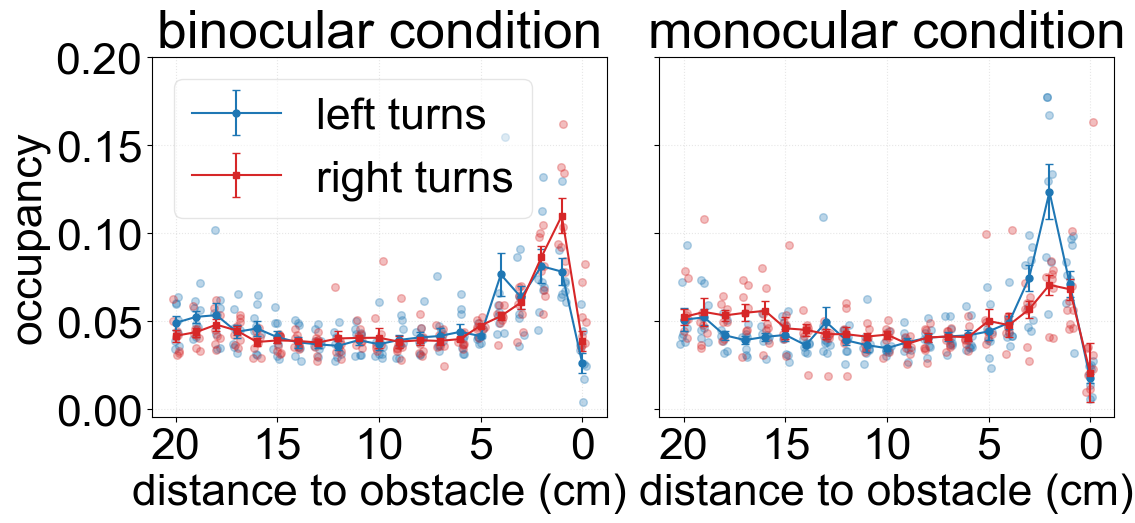

In [16]:
xnew = np.arange(0, 21, 1)
data = mon
data = drop_nans_in_columns(data, 'obstacle_ind')
data = drop_nans_in_columns(data, 'goal_distance_from_target_port')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.avg_lateral_error<0] 
#data = data[data.turn_to_obstacle == 'towards']

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plt.subplots_adjust(wspace=0.1)  # Reduce space between subplots

# Jitter and style parameters
jitter_amount = 0.2
left_params = {'color': 'tab:blue', 'marker': 'o', 'label': 'left turns'}
right_params = {'color': 'tab:red', 'marker': 's', 'label': 'right turns'}

# Process binocular (oa) data
oa_data = data[data.task == 'oa']
ax = ax1
for direction, params in [('left', left_params), ('right', right_params)]:
    subset = oa_data[oa_data.turn_direction_left_right == direction]
    dists = flatten_list_of_arrays(subset.ts_distance_from_edge.to_numpy())
    dists = dists[np.where((dists >= 0) & (dists <= 20))]
    counts, _ = np.histogram(dists, bins=21)
    hist = counts/sum(counts) if sum(counts) > 0 else np.zeros(21)
    
    # Plot individual animals
    animal_probs = []
    for ani, ani_df in subset.groupby('animal'):
        ani_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
        ani_dists = ani_dists[np.where((ani_dists >= 0) & (ani_dists <= 20))]
        ani_counts, _ = np.histogram(ani_dists, bins=21)
        if sum(ani_counts) > 0:
            ani_prob = ani_counts/sum(ani_counts)
            animal_probs.append(ani_prob)
            x_jittered = xnew + np.random.uniform(-jitter_amount, jitter_amount, size=len(xnew))
            ax.scatter(x_jittered, ani_prob, color=params['color'], alpha=0.3, s=30)
    
    # Plot mean and error bars (now using SEM)
    if animal_probs:
        animal_probs = np.asarray(animal_probs)
        sem = np.nanstd(animal_probs, axis=0) / np.sqrt(len(animal_probs))  # Changed to SEM
        ax.errorbar(xnew, hist, yerr=sem, color=params['color'], linestyle='-',
                   marker=params['marker'], markersize=5, capsize=3, 
                   label=params['label'] if ax == ax1 else None)

ax1.set_title('binocular condition')
ax1.invert_xaxis()
ax1.grid(True, linestyle=':', alpha=0.3)

# Process monocular (oamonle) data
oamonle_data = data[data.task == 'oamonle']
ax = ax2
for direction, params in [('left', left_params), ('right', right_params)]:
    subset = oamonle_data[oamonle_data.turn_direction_left_right == direction]
    dists = flatten_list_of_arrays(subset.ts_distance_from_edge.to_numpy())
    dists = dists[np.where((dists >= 0) & (dists <= 20))]
    counts, _ = np.histogram(dists, bins=21)
    hist = counts/sum(counts) if sum(counts) > 0 else np.zeros(21)
    
    # Plot individual animals
    animal_probs = []
    for ani, ani_df in subset.groupby('animal'):
        ani_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
        ani_dists = ani_dists[np.where((ani_dists >= 0) & (ani_dists <= 20))]
        ani_counts, _ = np.histogram(ani_dists, bins=21)
        if sum(ani_counts) > 0:
            ani_prob = ani_counts/sum(ani_counts)
            animal_probs.append(ani_prob)
            x_jittered = xnew + np.random.uniform(-jitter_amount, jitter_amount, size=len(xnew))
            ax.scatter(x_jittered, ani_prob, color=params['color'], alpha=0.3, s=30)
    
    # Plot mean and error bars (now using SEM)
    if animal_probs:
        animal_probs = np.asarray(animal_probs)
        sem = np.nanstd(animal_probs, axis=0) / np.sqrt(len(animal_probs))  # Changed to SEM
        ax.errorbar(xnew, hist, yerr=sem, color=params['color'], linestyle='-',
                   marker=params['marker'], markersize=5, capsize=3)

ax2.set_title('monocular condition')
ax2.invert_xaxis()
ax2.grid(True, linestyle=':', alpha=0.3)

# Formatting for both subplots
for ax in (ax1, ax2):
    ax.set_xticks(np.linspace(0, 20, 5))  # Reduced to 5 ticks
    ax.set_yticks(np.linspace(0, 0.2, 5))  # Reduced to 5 ticks
    ax.set_xlabel('distance to obstacle (cm)')

# Add single legend to left subplot
ax1.legend(framealpha=0.5, loc='upper left')
ax1.set_ylabel('occupancy')

plt.tight_layout()
plt.show()

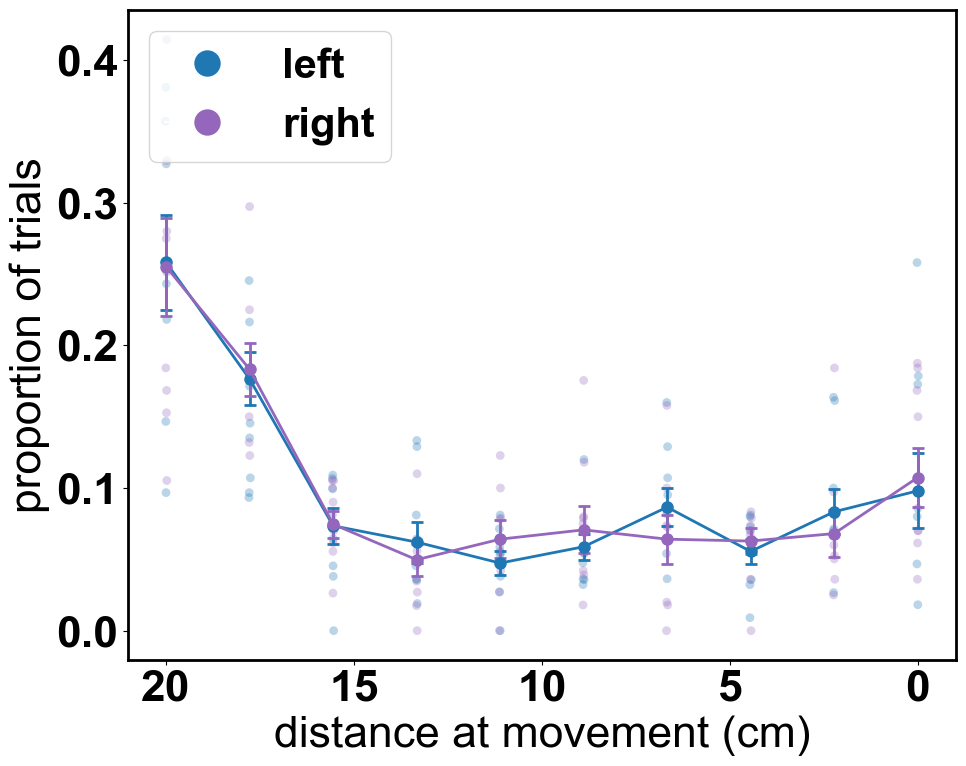

array([ 0.        ,  2.22222222,  4.44444444,  6.66666667,  8.88888889,
       11.11111111, 13.33333333, 15.55555556, 17.77777778, 20.        ])

In [362]:
xnew = np.linspace(0, 20, 10)
data = pd.concat([mon])

#data = data[data.intial_distance>=20]
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.task=='oa'] 
data = data[data.distance_at_head_turn>=0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.turn_direction_left_right == 'left']
light_dist = (light.distance_at_head_turn.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]

light_counts, light_bins = np.histogram(light_dist, bins=len(xnew),range=(0,20))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.turn_direction_left_right == 'right']
dark_dist = (dark.distance_at_head_turn.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew),range=(0,20))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='tab:purple', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='tab:purple', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting

ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('distance at movement (cm)', fontweight='normal')     # Not bold
ax.invert_xaxis()
ax.set_xticks([20,15,10,5,0])

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')



# Legend
ax.legend(loc='upper right', framealpha=0.8)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='left',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='right',
          markerfacecolor='tab:purple', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)


plt.tight_layout()
plt.show()
xnew


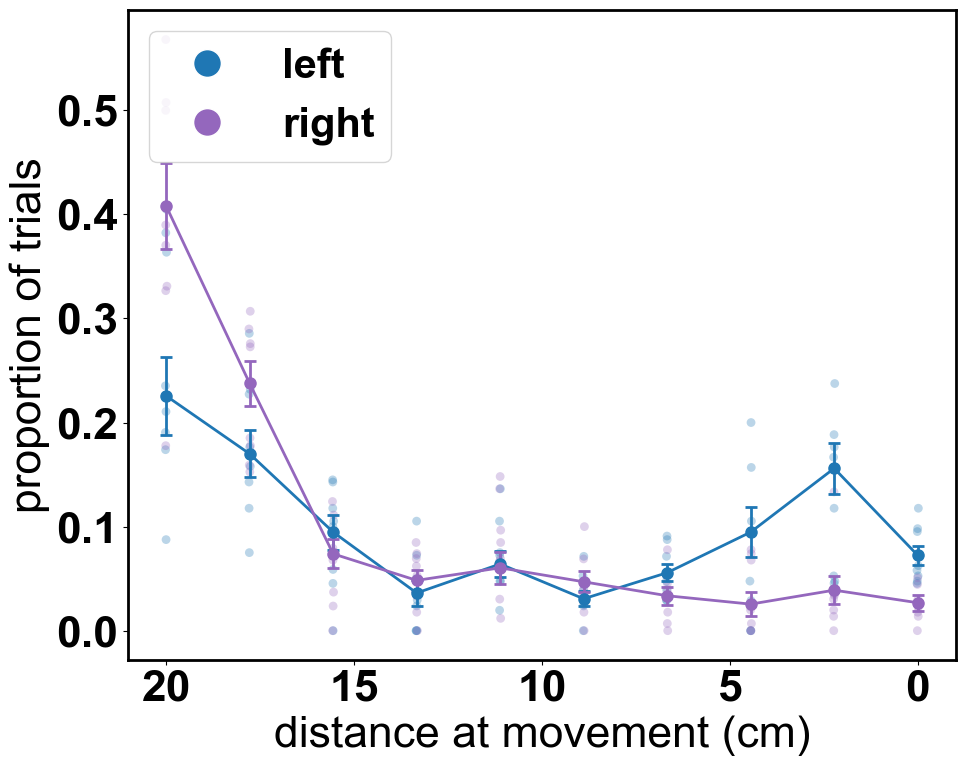

In [126]:
xnew = np.linspace(0, 20, 10)
data = pd.concat([mon])

#data = data[data.intial_distance>=20]
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.task=='oamonle'] 
data = data[data.distance_at_head_turn>=0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.turn_direction_left_right == 'left']
light_dist = (light.distance_at_head_turn.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]

light_counts, light_bins = np.histogram(light_dist, bins=len(xnew),range=(0,20))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.turn_direction_left_right == 'right']
dark_dist = (dark.distance_at_head_turn.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew),range=(0,20))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='tab:purple', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='tab:purple', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting

ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('distance at movement (cm)', fontweight='normal')     # Not bold
ax.invert_xaxis()
ax.set_xticks([20,15,10,5,0])

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')



# Legend
ax.legend(loc='upper right', framealpha=0.8)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='left',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='right',
          markerfacecolor='tab:purple', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)


plt.tight_layout()
plt.show()


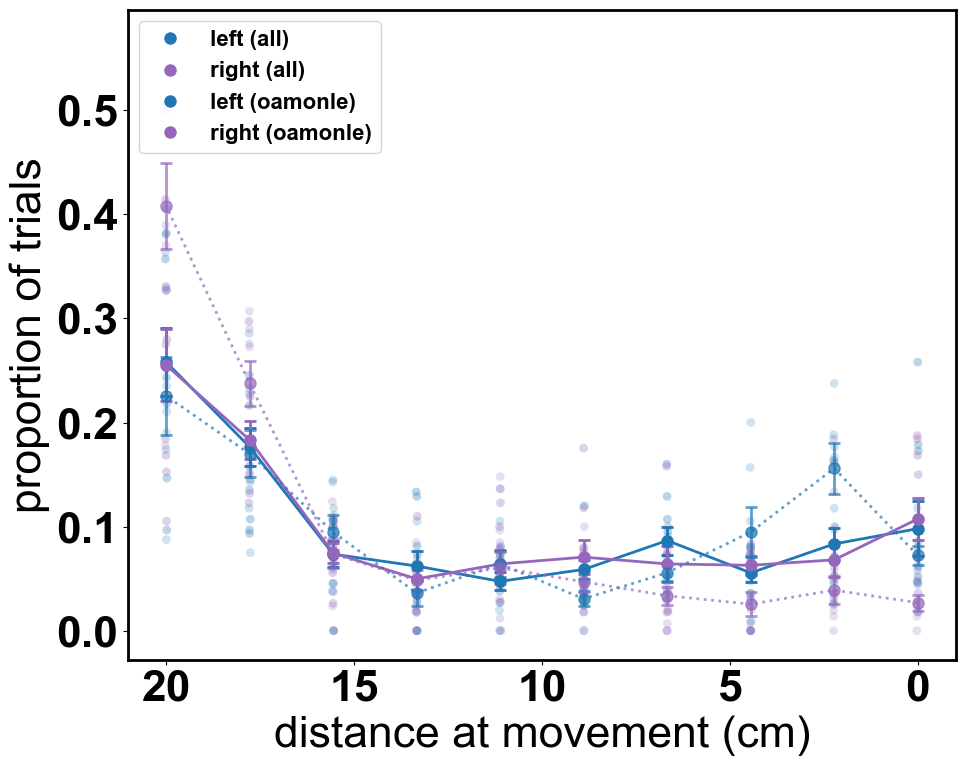

In [128]:
xnew = np.linspace(0, 20, 10)
data = pd.concat([mon])

# Original data filtering
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 

# Create two datasets - one with all tasks, one with only oamonle
all_data =  data[data.task=='oa']
oamonle_data = data[data.task=='oamonle']

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

def process_condition(data, condition, color, linestyle='-', alpha=1.0):
    """Helper function to process and plot data for a given condition"""
    subset = data[data.turn_direction_left_right == condition]
    dist = (subset.distance_at_head_turn.to_numpy())
    dist = dist[np.where((dist >= 0))]
    
    counts, bins = np.histogram(dist, bins=len(xnew), range=(0,20))
    hist = (counts / sum(counts)) if sum(counts) > 0 else np.zeros(len(xnew))
    
    # Process individual animals
    prob_list = []
    scatter_data = []
    
    for ani, ani_df in subset.groupby(['animal']):
        ani_dists = (ani_df.distance_at_head_turn.to_numpy())
        ani_dists = ani_dists[np.where((ani_dists >= 0))]
        
        counts, bins = np.histogram(ani_dists, bins=len(xnew), range=(0,20))
        prob = counts / sum(counts) if sum(counts) > 0 else np.zeros(len(xnew))
        prob_list.append(prob)
        
        x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
        scatter_data.append((x_jittered, prob))
    
    prob_array = np.asarray(prob_list)
    sem = np.nanstd(prob_array, axis=0) / np.sqrt(np.sum(~np.isnan(prob_array), axis=0))
    
    # Plot individual points
    for x_jittered, y in scatter_data:
        ax.scatter(x_jittered, y, color=color, alpha=0.3*alpha, s=40, edgecolors='none')
    
    # Plot mean line with SEM
    ax.errorbar(xnew, hist, yerr=sem,
               fmt='-o', color=color, linewidth=2, linestyle=linestyle,
               markersize=8, capsize=4, capthick=2, alpha=alpha,
               label=f'{condition} ({data.task.unique()[0] if len(data.task.unique()) == 1 else "all"})')
    
    return hist, sem

# Plot all data (solid lines)
light_hist, light_sem = process_condition(all_data, 'left', 'tab:blue')
dark_hist, dark_sem = process_condition(all_data, 'right', 'tab:purple')

# Plot oamonle data (dotted lines)
if not oamonle_data.empty:
    light_hist_oamonle, light_sem_oamonle = process_condition(oamonle_data, 'left', 'tab:blue', ':', 0.7)
    dark_hist_oamonle, dark_sem_oamonle = process_condition(oamonle_data, 'right', 'tab:purple', ':', 0.7)

# Formatting
ax.set_ylabel('proportion of trials', fontweight='normal')
ax.set_xlabel('distance at movement (cm)', fontweight='normal')
ax.invert_xaxis()
ax.set_xticks([20,15,10,5,0])

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Custom legend
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='left (all)',
          markerfacecolor='tab:blue', markersize=10, linestyle='-'),
    Line2D([0], [0], marker='o', color='w', label='right (all)',
          markerfacecolor='tab:purple', markersize=10, linestyle='-')
]

if not oamonle_data.empty:
    legend_handles.extend([
        Line2D([0], [0], marker='o', color='w', label='left (oamonle)',
              markerfacecolor='tab:blue', markersize=10, linestyle=':'),
        Line2D([0], [0], marker='o', color='w', label='right (oamonle)',
              markerfacecolor='tab:purple', markersize=10, linestyle=':')
    ])

ax.legend(handles=legend_handles, loc='upper left', fontsize=16, framealpha=0.8)

plt.tight_layout()
plt.show()

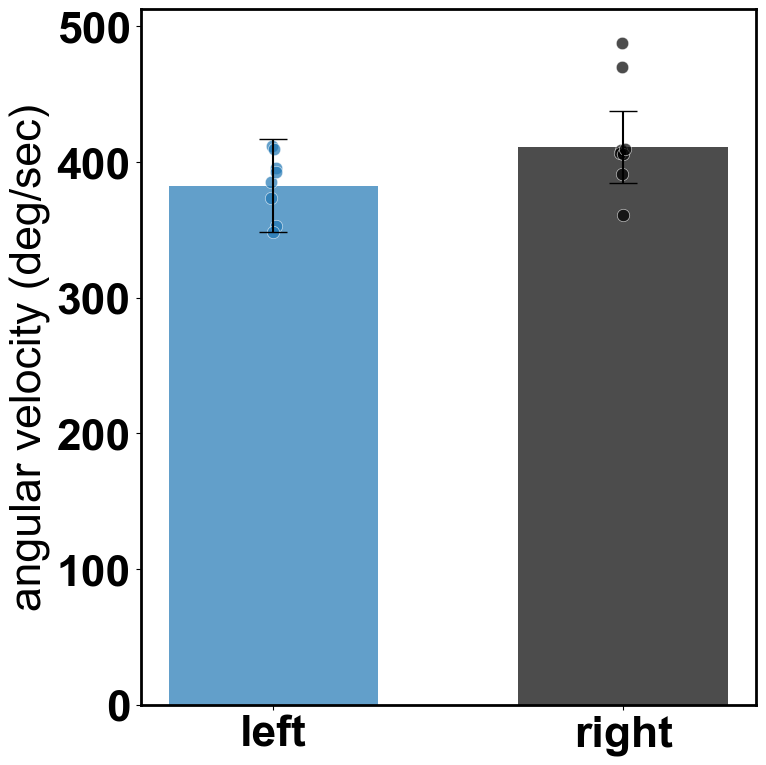

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# create figure with two subplots
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_distance<=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
data = data[data.head_turn_velocity>=0] 
oamonle_data = data[data.task=='oamonle']
#data = data[data.head_turn_velocity<=15] 
#data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
light_data = data[data['turn_direction_left_right'] == 'left']
dark_data = data[data['turn_direction_left_right'] == 'right']

# Calculate medians and standard errors
light_median = light_data['head_turn_velocity'].median()*60
light_se = light_data['head_turn_velocity'].sem()*60
dark_median = dark_data['head_turn_velocity'].median()*60
dark_se = dark_data['head_turn_velocity'].sem()*60

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
        alpha=0.7, capsize=10, width=0.6, label='dark')

# For evenly spaced jitter
# Jitter settings
jitter_width = 0.008  # Max horizontal spread (adjust as needed)

# Add individual animal points for light condition with random jitter
for animal in light_data['animal'].unique():
    animal_dist = light_data[light_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for dark condition with random jitter
for animal in dark_data['animal'].unique():
    animal_dist = dark_data[dark_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['left', 'right'])

#ax.set_yticks([0,5,10,15])
ax.set_ylabel('angular velocity (deg/sec)')

plt.tight_layout()
plt.show()

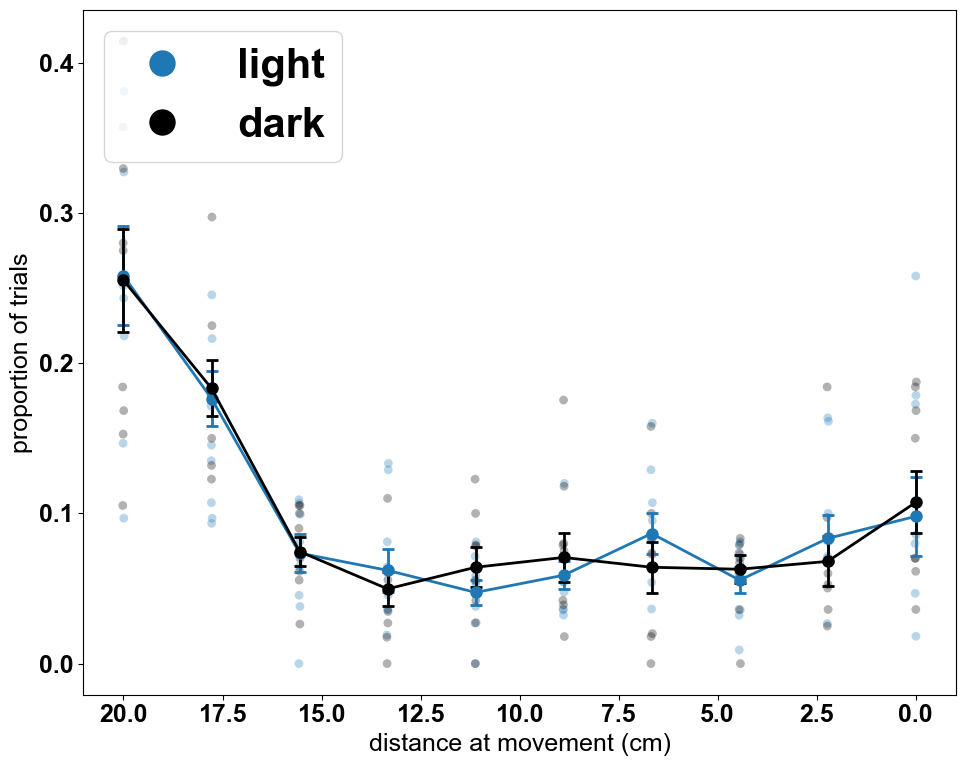

<Figure size 640x480 with 0 Axes>

In [117]:
xnew = np.linspace(0, 20, 10)
data = pd.concat([mon])

#data = data[data.intial_distance>=20]
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.task=='oa'] 
#data = data[data.distance_at_head_turn>=0] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.turn_direction_left_right == 'left']
light_dist = (light.distance_at_head_turn.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]

light_counts, light_bins = np.histogram(light_dist, bins=len(xnew),range=(0,20))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = data[data.turn_direction_left_right == 'right']
dark_dist = (dark.distance_at_head_turn.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew),range=(0,20))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.distance_at_head_turn.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=len(xnew),range=(0,20))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting

ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('distance at movement (cm)', fontweight='normal')     # Not bold
ax.invert_xaxis()

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')



# Legend
ax.legend(loc='upper right', framealpha=0.8)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)


plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

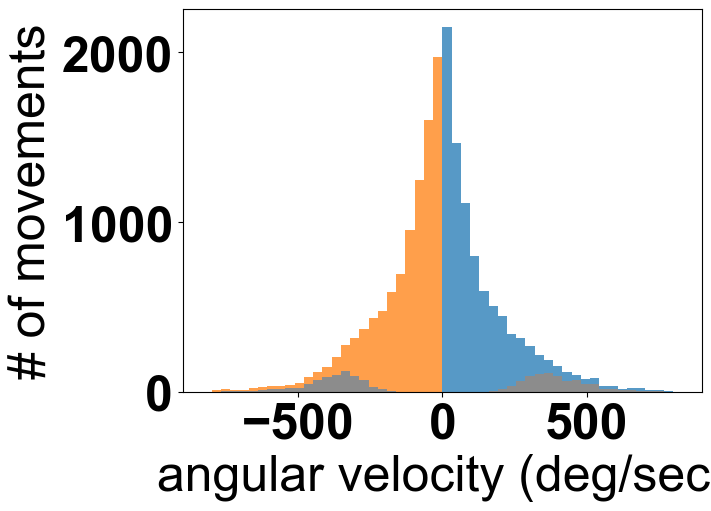

In [110]:
import numpy as np
import matplotlib.pyplot as plt
data = pd.concat([mon]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15] 
data = data[data.task=='oa']  



light = data

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Get full dataset
full_pos = flatten_list_of_arrays(light.positive_heights.to_list()) * 60
full_neg = flatten_list_of_arrays(light.negative_heights.to_list()) * 60

# Get largest movements subset
all_largest = light.head_turn_velocity.to_numpy() * 60
largest_pos = all_largest[all_largest > 0]
largest_neg = all_largest[all_largest < 0]

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Compute histograms
counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos)
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos)
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg)
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg)
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, counts_rest_pos, width_pos, 
       bottom=counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, counts_rest_neg, width_neg, 
       bottom=counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500, 0, 500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(-900, 900)

# Create custom legend handles to avoid duplicate grey entries
from matplotlib.patches import Patch
legend_elements = [
  
    Patch(facecolor='grey', alpha=0.9, label='largest turns')
]
#ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

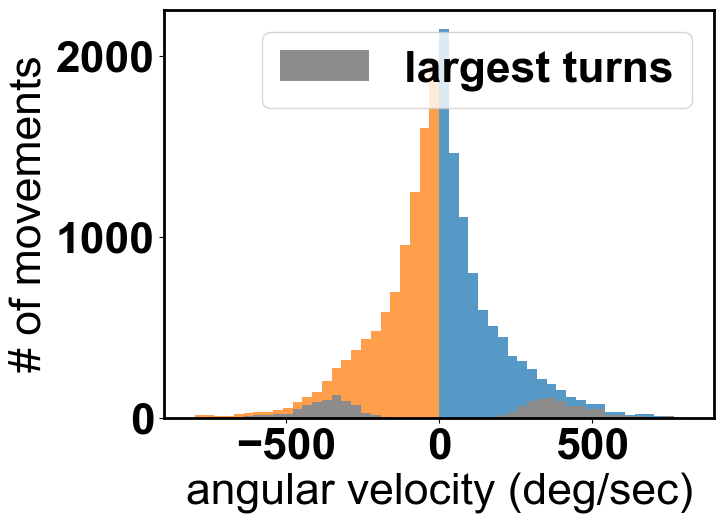

In [367]:
import numpy as np
import matplotlib.pyplot as plt
data = pd.concat([mon]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15] 
data = data[data.task=='oa']  



light = data

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Get full dataset
full_pos = flatten_list_of_arrays(light.positive_heights.to_list()) * 60
full_neg = flatten_list_of_arrays(light.negative_heights.to_list()) * 60

# Get largest movements subset
all_largest = light.head_turn_velocity.to_numpy() * 60
largest_pos = all_largest[all_largest > 0]
largest_neg = all_largest[all_largest < 0]

# Define bin edges (25 bins for each range)
bins_pos = np.linspace(0, 800, 26)   # 0 to 800 deg/sec
bins_neg = np.linspace(-800, 0, 26)  # -800 to 0 deg/sec

# Compute histograms
counts_full_pos, _ = np.histogram(full_pos, bins=bins_pos)
counts_largest_pos, _ = np.histogram(largest_pos, bins=bins_pos)
counts_rest_pos = counts_full_pos - counts_largest_pos  # Regular movements

counts_full_neg, _ = np.histogram(full_neg, bins=bins_neg)
counts_largest_neg, _ = np.histogram(largest_neg, bins=bins_neg)
counts_rest_neg = counts_full_neg - counts_largest_neg  # Regular movements

# Calculate bar properties
width_pos = bins_pos[1] - bins_pos[0]
width_neg = bins_neg[1] - bins_neg[0]
bin_centers_pos = bins_pos[:-1] + width_pos/2
bin_centers_neg = bins_neg[:-1] + width_neg/2

# Plot positive turns (grey = largest at bottom, blue = regular on top)
ax.bar(bin_centers_pos, counts_largest_pos, width_pos, 
       color='grey', alpha=0.9, label='Largest Turns')
ax.bar(bin_centers_pos, counts_rest_pos, width_pos, 
       bottom=counts_largest_pos, color='tab:blue', alpha=0.75, label='Positive Turns')

# Plot negative turns (grey = largest at bottom, red = regular on top)
ax.bar(bin_centers_neg, counts_largest_neg, width_neg, 
       color='grey', alpha=0.9)
ax.bar(bin_centers_neg, counts_rest_neg, width_neg, 
       bottom=counts_largest_neg, color='tab:orange', alpha=0.75, label='Negative Turns')

# Configure axis
ax.set_xticks([-500, 0, 500])
ax.set_xlabel('angular velocity (deg/sec)')
ax.set_ylabel('# of movements')
ax.set_xlim(-900, 900)

# Create custom legend handles to avoid duplicate grey entries
from matplotlib.patches import Patch
legend_elements = [
  
    Patch(facecolor='grey', alpha=0.9, label='largest turns')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

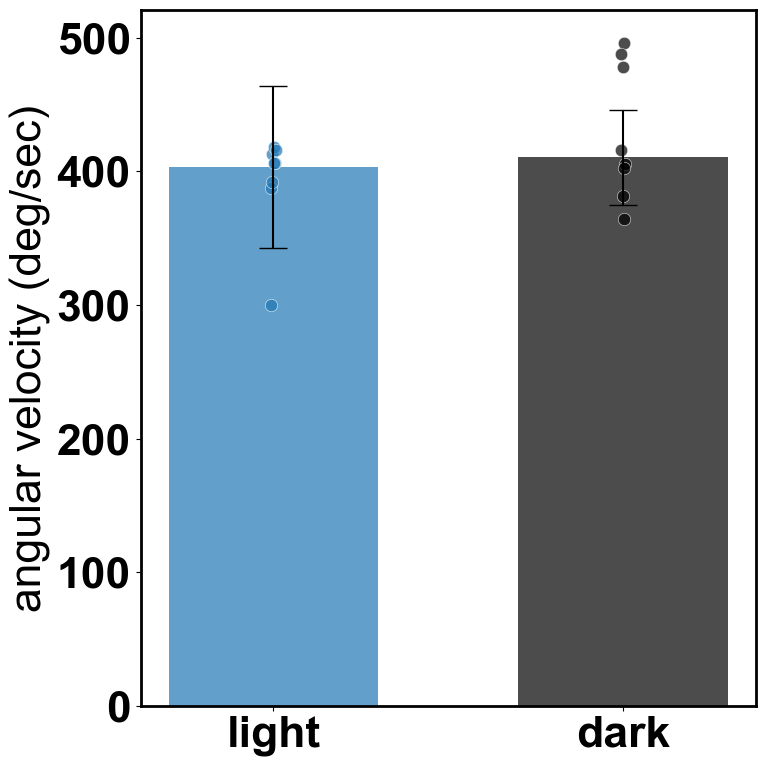

In [365]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# create figure with two subplots
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_distance<=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
data = data[data.head_turn_velocity>=0] 
data = data[data.task=='oamonle']  
#data = data[data.head_turn_velocity<=15] 
#data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
light_data = data[data['turn_direction_left_right'] == 'left']
dark_data = data[data['turn_direction_left_right'] == 'right']

# Calculate medians and standard errors
light_median = light_data['head_turn_velocity'].median()*60
light_se = light_data['head_turn_velocity'].sem()*60
dark_median = dark_data['head_turn_velocity'].median()*60
dark_se = dark_data['head_turn_velocity'].sem()*60

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
        alpha=0.7, capsize=10, width=0.6, label='dark')

# For evenly spaced jitter
# Jitter settings
jitter_width = 0.008  # Max horizontal spread (adjust as needed)

# Add individual animal points for light condition with random jitter
for animal in light_data['animal'].unique():
    animal_dist = light_data[light_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for dark condition with random jitter
for animal in dark_data['animal'].unique():
    animal_dist = dark_data[dark_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])

#ax.set_yticks([0,5,10,15])
ax.set_ylabel('angular velocity (deg/sec)')

plt.tight_layout()
plt.show()

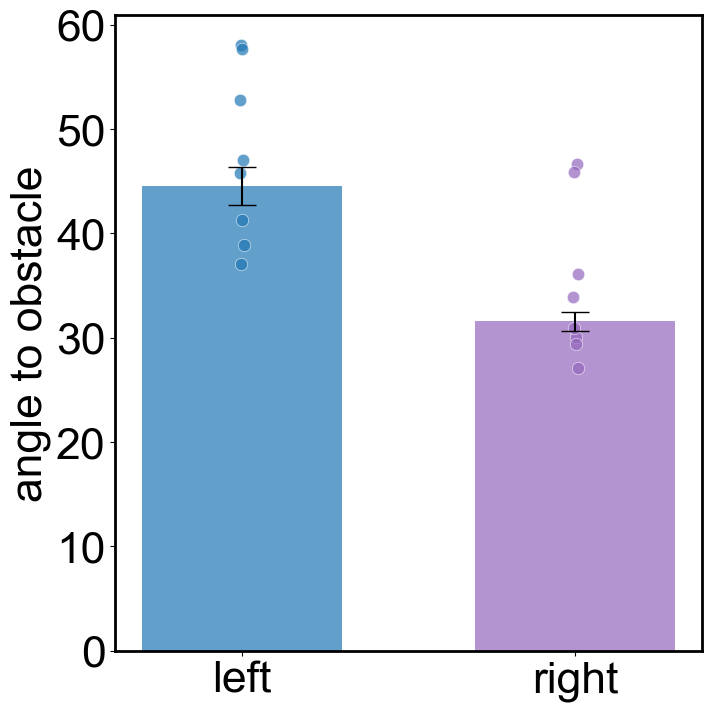

In [395]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# create figure with two subplots
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_distance<=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
data = data[data.angle_at_head_turn>=0] 
data = data[data.task=='oamonle']  
#data = data[data.angle_at_head_turn<=15] 
#data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
left_data = data[data['turn_direction_left_right'] == 'left']
right_data = data[data['turn_direction_left_right'] == 'right']

# Calculate medians and standard errors
left_median = left_data['angle_at_head_turn'].median()
left_se = left_data['angle_at_head_turn'].sem()
right_median = right_data['angle_at_head_turn'].median()
right_se = right_data['angle_at_head_turn'].sem()

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, left_median, yerr=left_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='left')
ax.bar(1, right_median, yerr=right_se, color='tab:purple', 
        alpha=0.7, capsize=10, width=0.6, label='right|')

# For evenly spaced jitter
# Jitter settings
jitter_width = 0.008  # Max horizontal spread (adjust as needed)

# Add individual animal points for left condition with random jitter
for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['angle_at_head_turn'].median()
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for right condition with random jitter
for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['angle_at_head_turn'].median()
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(1 + jitter, animal_dist, color='tab:purple', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['left', 'right'])

#ax.set_yticks([0,5,10,15])
ax.set_ylabel('angle to obstacle')
#ax.set_ylim(0,40)

plt.tight_layout()
plt.show()

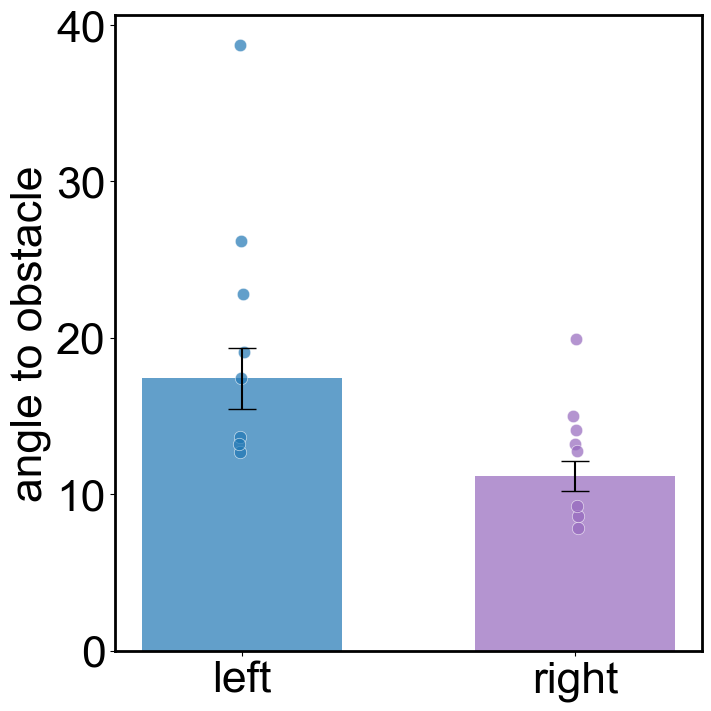

In [390]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# create figure with two subplots
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_distance<=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
data = data[data.angle_after_head_turn>=0] 
data = data[data.task=='oamonle']  
#data = data[data.angle_after_head_turn<=15] 
#data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
left_data = data[data['turn_direction_left_right'] == 'left']
right_data = data[data['turn_direction_left_right'] == 'right']

# Calculate medians and standard errors
left_median = left_data['angle_after_head_turn'].median()
left_se = left_data['angle_after_head_turn'].sem()
right_median = right_data['angle_after_head_turn'].median()
right_se = right_data['angle_after_head_turn'].sem()

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, left_median, yerr=left_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='left')
ax.bar(1, right_median, yerr=right_se, color='tab:purple', 
        alpha=0.7, capsize=10, width=0.6, label='right|')

# For evenly spaced jitter
# Jitter settings
jitter_width = 0.008  # Max horizontal spread (adjust as needed)

# Add individual animal points for left condition with random jitter
for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['angle_after_head_turn'].median()
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for right condition with random jitter
for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['angle_after_head_turn'].median()
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(1 + jitter, animal_dist, color='tab:purple', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['left', 'right'])

#ax.set_yticks([0,5,10,15])
ax.set_ylabel('angle to obstacle')

plt.tight_layout()
plt.show()

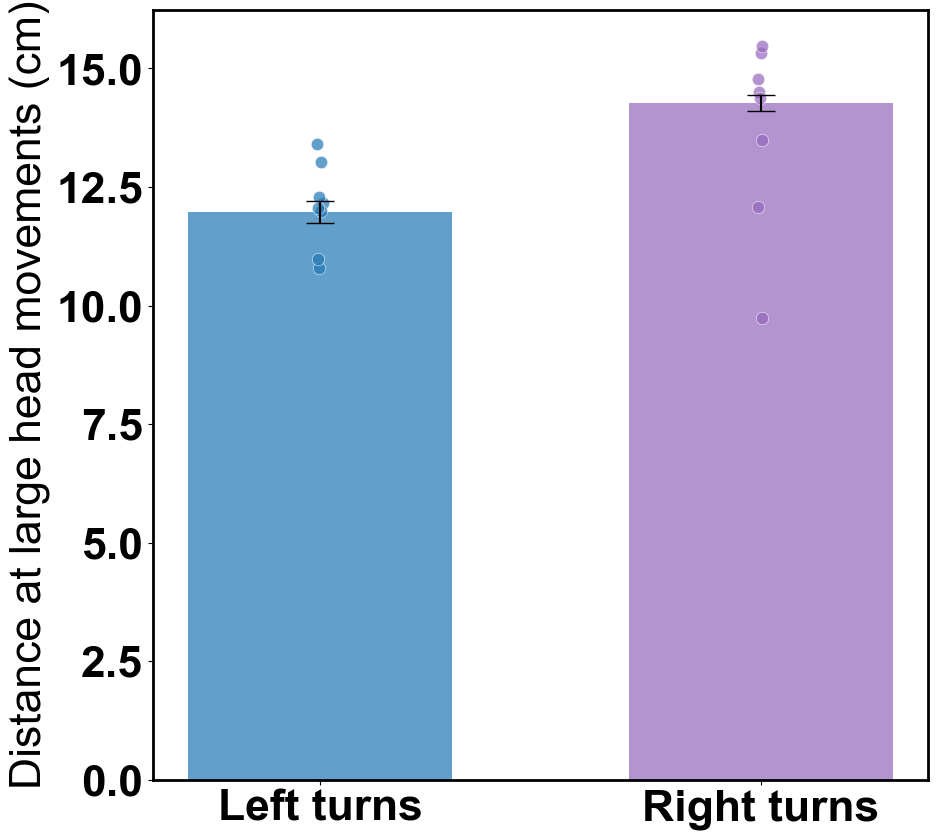

In [292]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def flatten_list_of_arrays(array_list):
    """Flatten a list of numpy arrays into a single array"""
    return np.concatenate([arr for arr in array_list if len(arr) > 0])

# Prepare data
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.task=='oamonle']  
# Filter for rows that have at least one large head turn


# Split by turn direction
left_data = data[data['turn_direction_left_right'] == 'left']
right_data = data[data['turn_direction_left_right'] == 'right']

# Flatten the arrays of distances for large head turns
left_distances = flatten_list_of_arrays(left_data.distances_at_large_head_turns.tolist())
right_distances = flatten_list_of_arrays(right_data.distances_at_large_head_turns.tolist())

# Calculate means and standard errors
left_mean = np.mean(left_distances) if len(left_distances) > 0 else np.nan
left_se = np.std(left_distances)/np.sqrt(len(left_distances)) if len(left_distances) > 0 else np.nan
right_mean = np.mean(right_distances) if len(right_distances) > 0 else np.nan
right_se = np.std(right_distances)/np.sqrt(len(right_distances)) if len(right_distances) > 0 else np.nan

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot bars with error bars
ax.bar(0, left_mean, yerr=left_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='Left turns')
ax.bar(1, right_mean, yerr=right_se, color='tab:purple', 
        alpha=0.7, capsize=10, width=0.6, label='Right turns')

# Jitter settings
jitter_width = 0.008  # Max horizontal spread

# Add individual animal points for left turns with random jitter
for animal in left_data['animal'].unique():
    animal_data = left_data[left_data['animal'] == animal]
    animal_distances = flatten_list_of_arrays(animal_data.distances_at_large_head_turns.tolist())
    if len(animal_distances) > 0:
        animal_mean = np.mean(animal_distances)
        jitter = np.random.uniform(-jitter_width, jitter_width)
        ax.scatter(0 + jitter, animal_mean, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for right turns with random jitter
for animal in right_data['animal'].unique():
    animal_data = right_data[right_data['animal'] == animal]
    animal_distances = flatten_list_of_arrays(animal_data.distances_at_large_head_turns.tolist())
    if len(animal_distances) > 0:
        animal_mean = np.mean(animal_distances)
        jitter = np.random.uniform(-jitter_width, jitter_width)
        ax.scatter(1 + jitter, animal_mean, color='tab:purple', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['Left turns', 'Right turns'])

ax.set_ylabel('Distance at large head movements (cm)')


# Add legend
legend_elements = [Line2D([0], [0], color='tab:blue', lw=4, label='Left turns'),
                   Line2D([0], [0], color='tab:purple', lw=4, label='Right turns')]
#ax.legend(handles=legend_elements, loc='upper right')


plt.show()

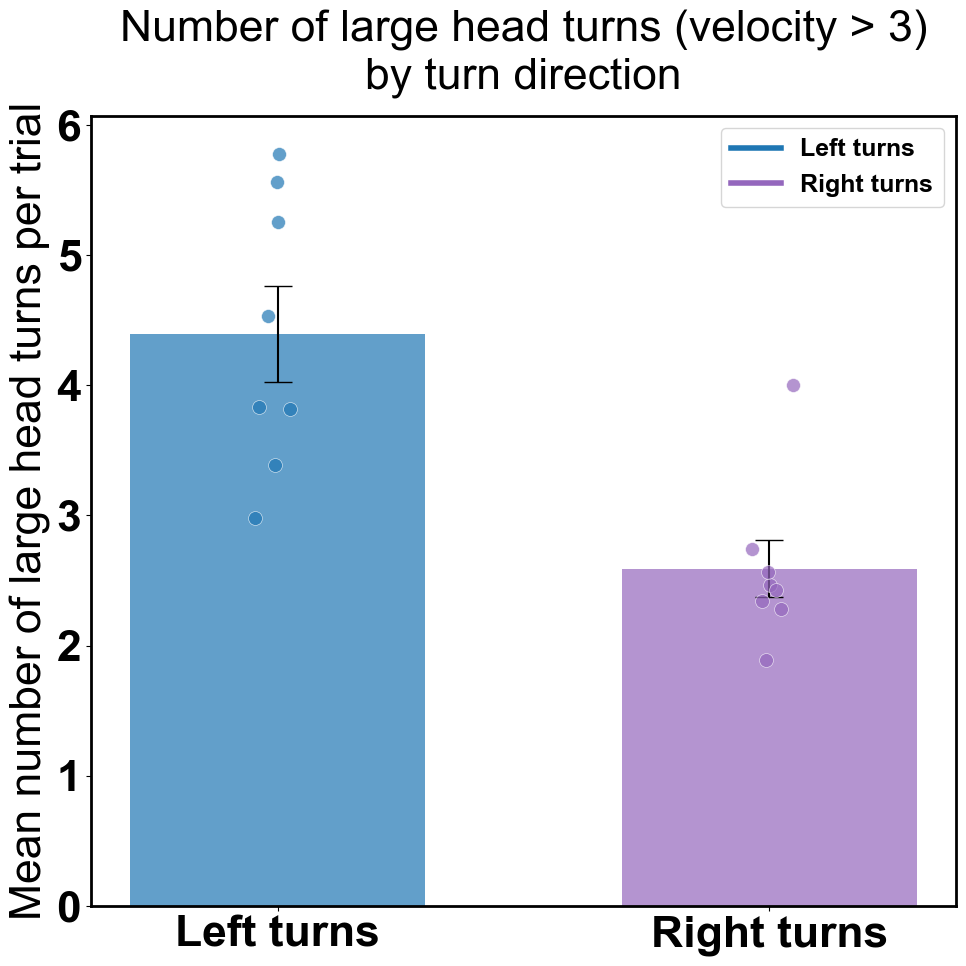

In [298]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Prepare data
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.task=='oamonle']

# Split by turn direction
left_data = data[data['turn_direction_left_right'] == 'left']
right_data = data[data['turn_direction_left_right'] == 'right']

# Calculate number of large head turns per trial
left_data['num_large_turns'] = left_data['distances_at_large_head_turns'].apply(len)
right_data['num_large_turns'] = right_data['distances_at_large_head_turns'].apply(len)

# Calculate mean number of large turns per animal
left_means = left_data.groupby('animal')['num_large_turns'].mean()
right_means = right_data.groupby('animal')['num_large_turns'].mean()

# Calculate overall means and SEM
left_mean = left_means.mean()
left_sem = left_means.sem()
right_mean = right_means.mean()
right_sem = right_means.sem()

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot bars with error bars
ax.bar(0, left_mean, yerr=left_sem, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='Left turns')
ax.bar(1, right_mean, yerr=right_sem, color='tab:purple', 
       alpha=0.7, capsize=10, width=0.6, label='Right turns')

# Jitter settings
jitter_width = 0.05  # Increased jitter width for better visibility

# Add individual animal means for left turns
for i, (animal, mean_val) in enumerate(left_means.items()):
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, mean_val, color='tab:blue', s=100, alpha=0.7, 
               edgecolor='white', linewidth=0.5, zorder=10)

# Add individual animal means for right turns
for i, (animal, mean_val) in enumerate(right_means.items()):
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, mean_val, color='tab:purple', s=100, alpha=0.7, 
               edgecolor='white', linewidth=0.5, zorder=10)

# Customize plot
ax.set_xticks([0, 1], ['Left turns', 'Right turns'])
ax.set_ylabel('Mean number of large head turns per trial')
ax.set_ylim(bottom=0)  # Start y-axis at 0

# Add legend
legend_elements = [Line2D([0], [0], color='tab:blue', lw=4, label='Left turns'),
                  Line2D([0], [0], color='tab:purple', lw=4, label='Right turns')]
ax.legend(handles=legend_elements, loc='upper right')

# Add title
ax.set_title('Number of large head turns (velocity > 3)\nby turn direction', pad=20)

plt.tight_layout()
plt.show()

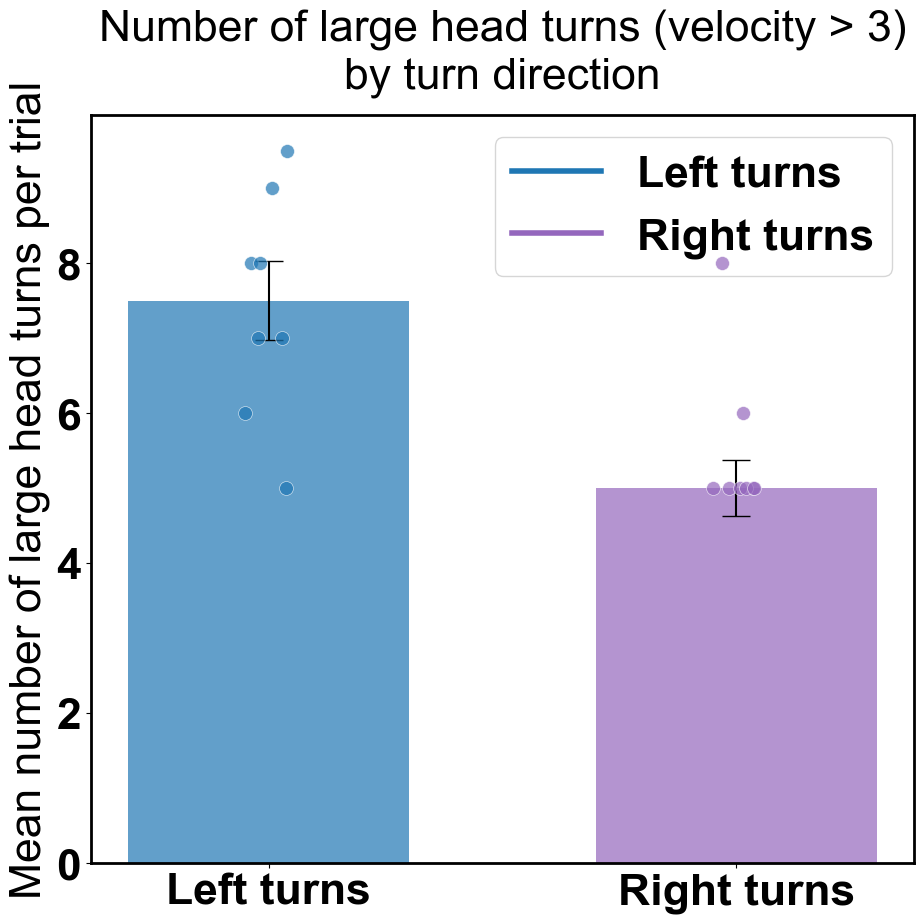

In [368]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Prepare data
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.task=='oamonle']

# Split by turn direction
left_data = data[data['turn_direction_left_right'] == 'left']
right_data = data[data['turn_direction_left_right'] == 'right']



# Calculate median number of large turns per animal
left_medians = left_data.groupby('animal')['num_turn'].median()
right_medians = right_data.groupby('animal')['num_turn'].median()

# Calculate overall medians and SEM
left_median = left_medians.median()
left_sem = left_medians.sem()
right_median = right_medians.median()
right_sem = right_medians.sem()

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot bars with error bars
ax.bar(0, left_median, yerr=left_sem, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='Left turns')
ax.bar(1, right_median, yerr=right_sem, color='tab:purple', 
       alpha=0.7, capsize=10, width=0.6, label='Right turns')

# Jitter settings
jitter_width = 0.05  # Increased jitter width for better visibility

# Add individual animal medians for left turns
for i, (animal, median_val) in enumerate(left_medians.items()):
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, median_val, color='tab:blue', s=100, alpha=0.7, 
               edgecolor='white', linewidth=0.5, zorder=10)

# Add individual animal medians for right turns
for i, (animal, median_val) in enumerate(right_medians.items()):
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, median_val, color='tab:purple', s=100, alpha=0.7, 
               edgecolor='white', linewidth=0.5, zorder=10)

# Customize plot
ax.set_xticks([0, 1], ['Left turns', 'Right turns'])
ax.set_ylabel('Mean number of large head turns per trial')
ax.set_ylim(bottom=0)  # Start y-axis at 0

# Add legend
legend_elements = [Line2D([0], [0], color='tab:blue', lw=4, label='Left turns'),
                  Line2D([0], [0], color='tab:purple', lw=4, label='Right turns')]
ax.legend(handles=legend_elements, loc='upper right')

# Add title
ax.set_title('Number of large head turns (velocity > 3)\nby turn direction', pad=20)

plt.tight_layout()
plt.show()

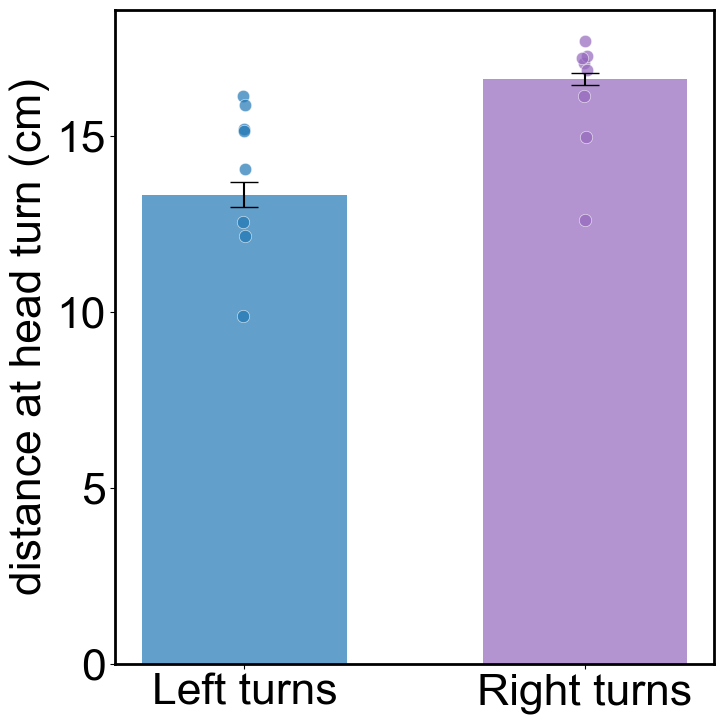

In [378]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Prepare data
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0]  # Only valid distances
data = data[data.task=='oamonle']

# Split by turn direction
left_data = data[data['turn_direction_left_right'] == 'left']
right_data = data[data['turn_direction_left_right'] == 'right']

# Calculate means and standard errors
left_mean = left_data['distance_at_head_turn'].mean()
left_se = left_data['distance_at_head_turn'].sem()
right_mean = right_data['distance_at_head_turn'].mean()
right_se = right_data['distance_at_head_turn'].sem()

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, left_mean, yerr=left_se, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='Left turns')
ax.bar(1, right_mean, yerr=right_se, color='tab:purple', 
       alpha=0.7, capsize=10, width=0.6, label='Right turns')

# Jitter settings
jitter_width = 0.008  # Max horizontal spread

# Add individual animal points for left turns with random jitter
for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['distance_at_head_turn'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for right turns with random jitter
for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['distance_at_head_turn'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, animal_dist, color='tab:purple', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['Left turns', 'Right turns'])
#ax.set_yticks([0,5,10,15])
ax.set_ylabel('distance at head turn (cm)')


# Add legend
legend_elements = [Line2D([0], [0], color='tab:blue', lw=4, label='left turns'),
                   Line2D([0], [0], color='tab:purple', lw=4, label='right turns')]
#ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

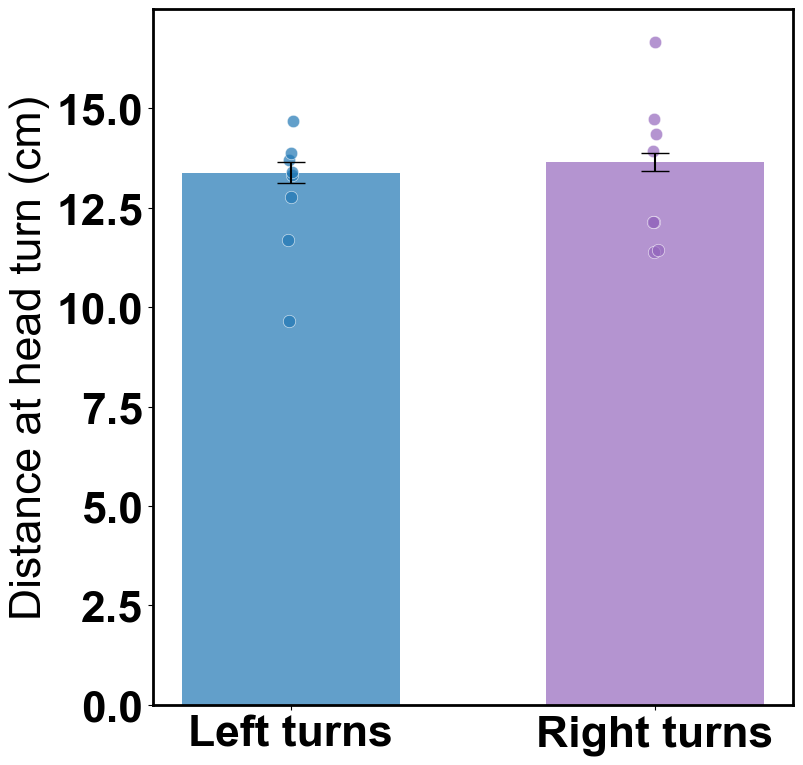

In [333]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Prepare data
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0]  # Only valid distances
data = data[data.task=='oa']

# Split by turn direction
left_data = data[data['turn_direction_left_right'] == 'left']
right_data = data[data['turn_direction_left_right'] == 'right']

# Calculate means and standard errors
left_mean = left_data['distance_at_head_turn'].mean()
left_se = left_data['distance_at_head_turn'].sem()
right_mean = right_data['distance_at_head_turn'].mean()
right_se = right_data['distance_at_head_turn'].sem()

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, left_mean, yerr=left_se, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='Left turns')
ax.bar(1, right_mean, yerr=right_se, color='tab:purple', 
       alpha=0.7, capsize=10, width=0.6, label='Right turns')

# Jitter settings
jitter_width = 0.008  # Max horizontal spread

# Add individual animal points for left turns with random jitter
for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['distance_at_head_turn'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for right turns with random jitter
for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['distance_at_head_turn'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, animal_dist, color='tab:purple', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['Left turns', 'Right turns'])
#ax.set_yticks([0,5,10,15])
ax.set_ylabel('Distance at head turn (cm)')


# Add legend
legend_elements = [Line2D([0], [0], color='tab:blue', lw=4, label='Left turns'),
                   Line2D([0], [0], color='tab:purple', lw=4, label='Right turns')]
#ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

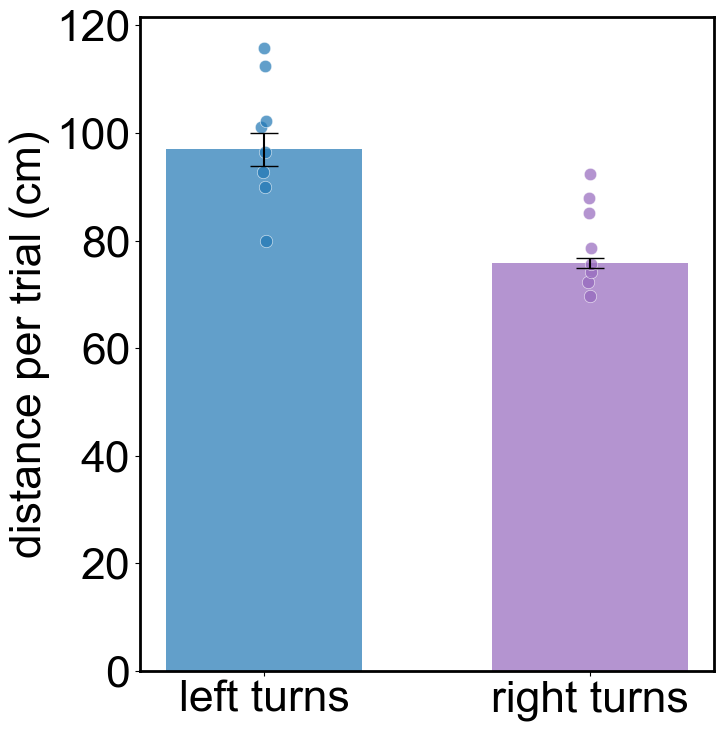

In [377]:
from matplotlib.lines import Line2D

# Prepare data
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.total_distance>=0]  # Only valid distances
data = data[data.task=='oamonle']

# Split by turn direction
left_data = data[data['turn_direction_left_right'] == 'left']
right_data = data[data['turn_direction_left_right'] == 'right']

# Calculate means and standard errors
left_mean = left_data['total_distance'].mean()
left_se = left_data['total_distance'].sem()
right_mean = right_data['total_distance'].mean()
right_se = right_data['total_distance'].sem()

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, left_mean, yerr=left_se, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='Left turns')
ax.bar(1, right_mean, yerr=right_se, color='tab:purple', 
       alpha=0.7, capsize=10, width=0.6, label='Right turns')

# Jitter settings
jitter_width = 0.008  # Max horizontal spread

# Add individual animal points for left turns with random jitter
for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['total_distance'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for right turns with random jitter
for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['total_distance'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, animal_dist, color='tab:purple', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['left turns', 'right turns'])
#ax.set_yticks([0,5,10,15])
ax.set_ylabel('distance per trial (cm)')


# Add legend
legend_elements = [Line2D([0], [0], color='tab:blue', lw=4, label='Left turns'),
                   Line2D([0], [0], color='tab:purple', lw=4, label='Right turns')]
#ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

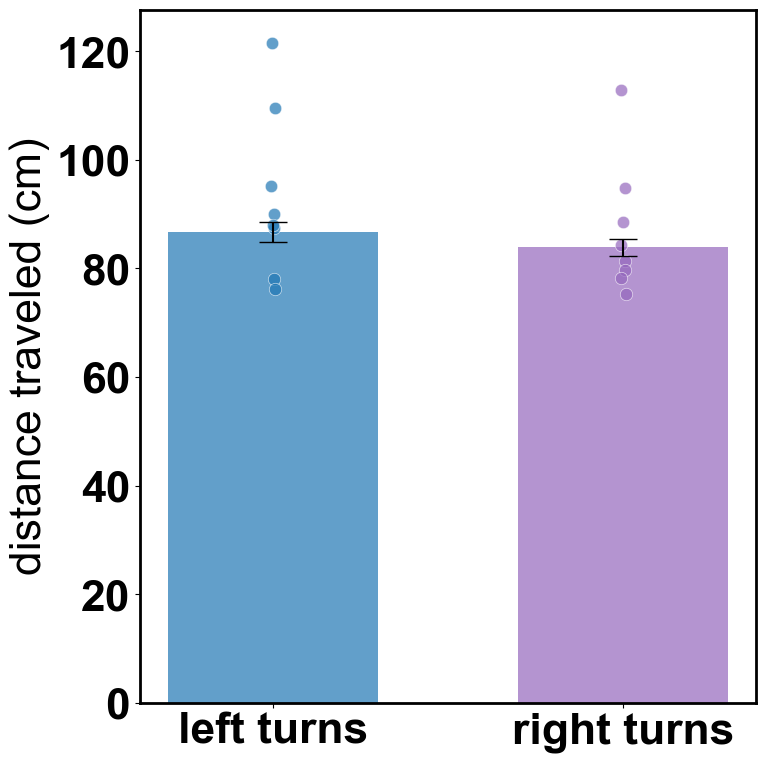

In [330]:
from matplotlib.lines import Line2D

# Prepare data
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.total_distance>=0]  # Only valid distances
data = data[data.task=='oa']

# Split by turn direction
left_data = data[data['turn_direction_left_right'] == 'left']
right_data = data[data['turn_direction_left_right'] == 'right']

# Calculate means and standard errors
left_mean = left_data['total_distance'].mean()
left_se = left_data['total_distance'].sem()
right_mean = right_data['total_distance'].mean()
right_se = right_data['total_distance'].sem()

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, left_mean, yerr=left_se, color='tab:blue', 
       alpha=0.7, capsize=10, width=0.6, label='Left turns')
ax.bar(1, right_mean, yerr=right_se, color='tab:purple', 
       alpha=0.7, capsize=10, width=0.6, label='Right turns')

# Jitter settings
jitter_width = 0.008  # Max horizontal spread

# Add individual animal points for left turns with random jitter
for animal in left_data['animal'].unique():
    animal_dist = left_data[left_data['animal'] == animal]['total_distance'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for right turns with random jitter
for animal in right_data['animal'].unique():
    animal_dist = right_data[right_data['animal'] == animal]['total_distance'].mean()
    jitter = np.random.uniform(-jitter_width, jitter_width)
    ax.scatter(1 + jitter, animal_dist, color='tab:purple', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['left turns', 'right turns'])
#ax.set_yticks([0,5,10,15])
ax.set_ylabel('distance traveled (cm)')


# Add legend
legend_elements = [Line2D([0], [0], color='tab:blue', lw=4, label='Left turns'),
                   Line2D([0], [0], color='tab:purple', lw=4, label='Right turns')]
#ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# create figure with two subplots
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_distance<=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 
data = data[data.head_turn_velocity>=0] 
data = data[data.task=='oamonle']  
#data = data[data.head_turn_velocity<=15] 
#data = data[data.turn_to_obstacle=='towards'] 

# Prepare data
light_data = data[data['turn_direction_left_right'] == 'left']
dark_data = data[data['turn_direction_left_right'] == 'right']

# Calculate medians and standard errors
light_median = light_data['head_turn_velocity'].median()*60
light_se = light_data['head_turn_velocity'].sem()*60
dark_median = dark_data['head_turn_velocity'].median()*60
dark_se = dark_data['head_turn_velocity'].sem()*60

# Create figure
fig,ax = plt.subplots(figsize=(8, 8))

# Plot bars with error bars
ax.bar(0, light_median, yerr=light_se, color='tab:blue', 
        alpha=0.7, capsize=10, width=0.6, label='light')
ax.bar(1, dark_median, yerr=dark_se, color='black', 
        alpha=0.7, capsize=10, width=0.6, label='dark')

# For evenly spaced jitter
# Jitter settings
jitter_width = 0.008  # Max horizontal spread (adjust as needed)

# Add individual animal points for light condition with random jitter
for animal in light_data['animal'].unique():
    animal_dist = light_data[light_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(0 + jitter, animal_dist, color='tab:blue', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Add individual animal points for dark condition with random jitter
for animal in dark_data['animal'].unique():
    animal_dist = dark_data[dark_data['animal'] == animal]['head_turn_velocity'].median()*60
    jitter = np.random.uniform(-jitter_width, jitter_width)  # Random jitter
    ax.scatter(1 + jitter, animal_dist, color='black', s=80, alpha=0.7, edgecolor='white', linewidth=0.5)

# Customize plot
ax.set_xticks([0, 1], ['light', 'dark'])

#ax.set_yticks([0,5,10,15])
ax.set_ylabel('angular velocity (deg/sec)')

plt.tight_layout()
plt.show()

<AxesSubplot: >

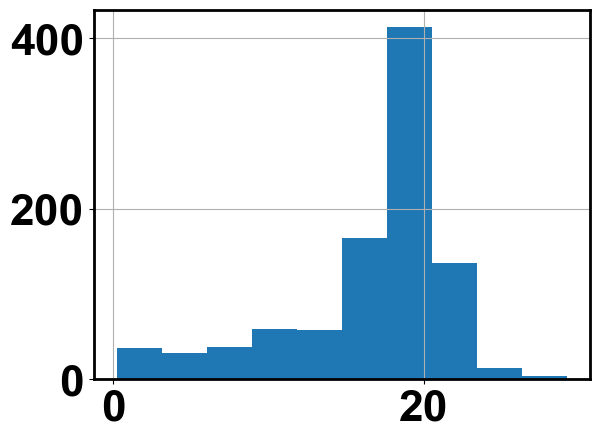

In [134]:
dark_data['distance_at_head_turn'].hist()

animal
J701LT    AxesSubplot(0.125,0.11;0.775x0.77)
J701NN    AxesSubplot(0.125,0.11;0.775x0.77)
J701RN    AxesSubplot(0.125,0.11;0.775x0.77)
J701RT    AxesSubplot(0.125,0.11;0.775x0.77)
J704LN    AxesSubplot(0.125,0.11;0.775x0.77)
J704LT    AxesSubplot(0.125,0.11;0.775x0.77)
J704NN    AxesSubplot(0.125,0.11;0.775x0.77)
J704RT    AxesSubplot(0.125,0.11;0.775x0.77)
Name: distance_at_head_turn, dtype: object

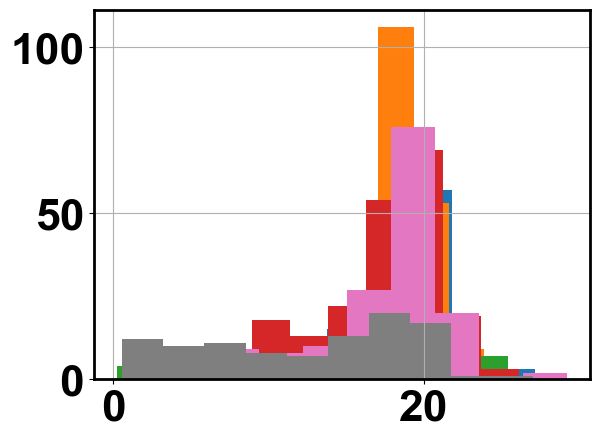

In [140]:
dark_data.groupby(['animal']).distance_at_head_turn.hist()

In [ ]:
flatten_list_of_arrays

animal
J701LT    AxesSubplot(0.125,0.11;0.775x0.77)
J701NN    AxesSubplot(0.125,0.11;0.775x0.77)
J701RN    AxesSubplot(0.125,0.11;0.775x0.77)
J701RT    AxesSubplot(0.125,0.11;0.775x0.77)
J704LN    AxesSubplot(0.125,0.11;0.775x0.77)
J704LT    AxesSubplot(0.125,0.11;0.775x0.77)
J704NN    AxesSubplot(0.125,0.11;0.775x0.77)
J704RT    AxesSubplot(0.125,0.11;0.775x0.77)
Name: distance_at_head_turn, dtype: object

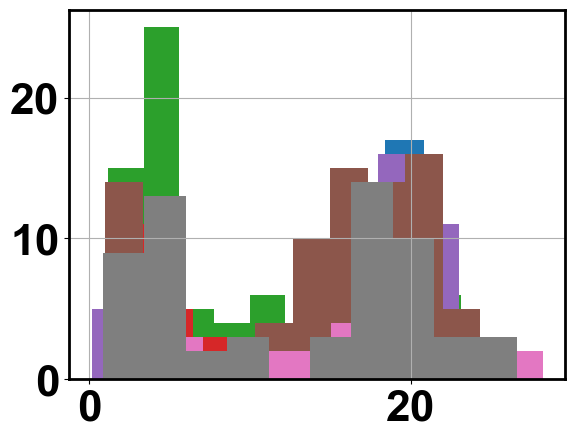

In [138]:
light_data.groupby(['animal']).distance_at_head_turn.hist()

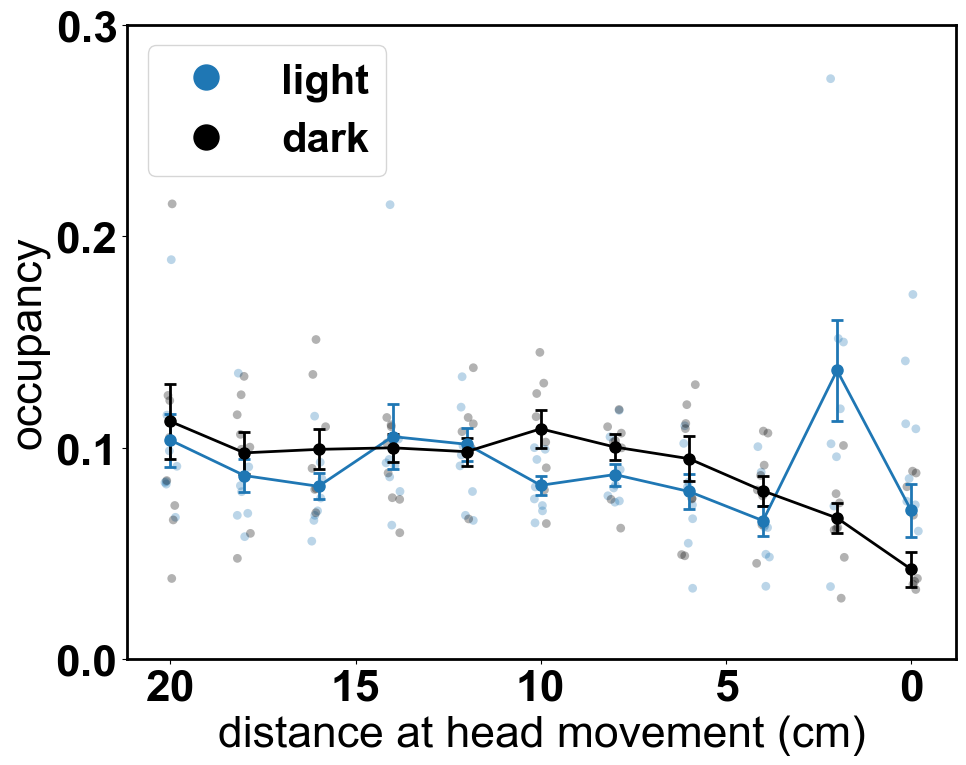

In [141]:
xnew = np.arange(0, 21, 2)
data = pd.concat([mon]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.distance_at_head_turn>=0] 
data = data[data.task=='oamonle'] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)


# Process light condition
light = data[data['turn_direction_left_right'] == 'left']
#ts_calculate_relative_distance2(light)
light_dist = flatten_list_of_arrays(light.distances_at_head_turns.to_numpy())
light_dist = light_dist[np.where((light_dist >= 0))]
light_dist = light_dist[np.where((light_dist <= 20))]
light_counts, light_bins = np.histogram(light_dist, bins=len(xnew))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []  # To store individual animal points

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.distances_at_head_turns.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists >= 0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 20))]
    counts, bins = np.histogram(ani_light_dists, bins=len(xnew))
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark =  data[data['turn_direction_left_right'] == 'right']
#ts_calculate_relative_distance2(dark)
dark_dist = flatten_list_of_arrays(dark.distances_at_head_turns.to_numpy())
dark_dist = dark_dist[np.where((dark_dist >= 0))]
dark_dist = dark_dist[np.where((dark_dist <= 20))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=len(xnew))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []  # To store individual animal points

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.distances_at_head_turns.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists >= 0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 20))]
    counts, bins = np.histogram(ani_dark_dists, bins=len(xnew))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2,.3])
ax.set_ylabel('occupancy', fontsize=32)
ax.set_xlabel('distance at head movement (cm)', fontsize=32)
ax.invert_xaxis()

# Legend

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)

plt.tight_layout()
plt.show()

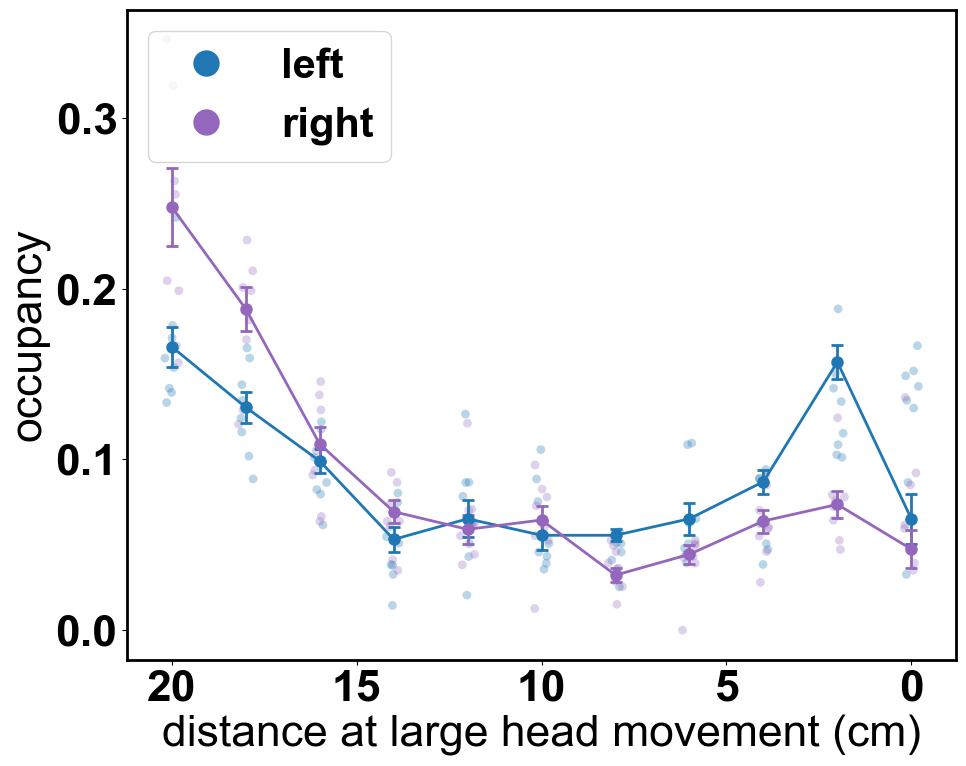

In [293]:
xnew = np.arange(0, 21, 2)
data = pd.concat([mon]) 
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_lateral_error<0]
data = data[data.intial_distance>=15]  
data = data[data.distance_at_head_turn>=0] 
data = data[data.task=='oamonle'] 
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)


# Process left condition
left = data[data['turn_direction_left_right'] == 'left']
#ts_calculate_relative_distance2(left)
left_dist = flatten_list_of_arrays(left.distances_at_large_head_turns.to_numpy())
left_dist = left_dist[np.where((left_dist >= 0))]
left_dist = left_dist[np.where((left_dist <= 20))]
left_counts, left_bins = np.histogram(left_dist, bins=len(xnew))
left_hist = (left_counts / sum(left_counts))

# Process individual animals for left condition
left_prob = []
left_scatter = []  # To store individual animal points

for ani, ani_df in left.groupby(['animal']):
    ani_left_dists = flatten_list_of_arrays(ani_df.distances_at_large_head_turns.to_numpy())
    ani_left_dists = ani_left_dists[np.where((ani_left_dists >= 0))]
    ani_left_dists = ani_left_dists[np.where((ani_left_dists <= 20))]
    counts, bins = np.histogram(ani_left_dists, bins=len(xnew))
    prob = counts / sum(counts)
    left_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    left_scatter.append((x_jittered, prob))

left_prob = np.asarray(left_prob)
# Calculate SEM instead of SD
left_sem = np.nanstd(left_prob, axis=0) / np.sqrt(np.sum(~np.isnan(left_prob), axis=0))

# Process right condition
right =  data[data['turn_direction_left_right'] == 'right']
#ts_calculate_relative_distance2(right)
right_dist = flatten_list_of_arrays(right.distances_at_large_head_turns.to_numpy())
right_dist = right_dist[np.where((right_dist >= 0))]
right_dist = right_dist[np.where((right_dist <= 20))]
right_counts, right_bins = np.histogram(right_dist, bins=len(xnew))
right_hist = (right_counts / sum(right_counts))

# Process individual animals for right condition
right_prob = []
right_scatter = []  # To store individual animal points

for ani, ani_df in right.groupby(['animal']):
    ani_right_dists = flatten_list_of_arrays(ani_df.distances_at_large_head_turns.to_numpy())
    ani_right_dists = ani_right_dists[np.where((ani_right_dists >= 0))]
    ani_right_dists = ani_right_dists[np.where((ani_right_dists <= 20))]
    counts, bins = np.histogram(ani_right_dists, bins=len(xnew))
    prob = counts / sum(counts)
    right_prob.append(prob)
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    right_scatter.append((x_jittered, prob))

right_prob = np.asarray(right_prob)
# Calculate SEM instead of SD
right_sem = np.nanstd(right_prob, axis=0) / np.sqrt(np.sum(~np.isnan(right_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in left_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in right_scatter:
    ax.scatter(x_jittered, y, color='tab:purple', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, left_hist, yerr=left_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='left')

ax.errorbar(xnew, right_hist, yerr=right_sem,
           fmt='-o', color='tab:purple', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='right')

# Formatting
ax.set_xticks([20, 15, 10, 5, 0])
ax.set_yticks([0, 0.1, 0.2,.3])
ax.set_ylabel('occupancy', fontsize=32)
ax.set_xlabel('distance at large head movement (cm)', fontsize=32)
ax.invert_xaxis()

# Legend

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='left',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='right',
          markerfacecolor='tab:purple', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper left', fontsize=30, framealpha=0.8)

plt.tight_layout()
plt.show()

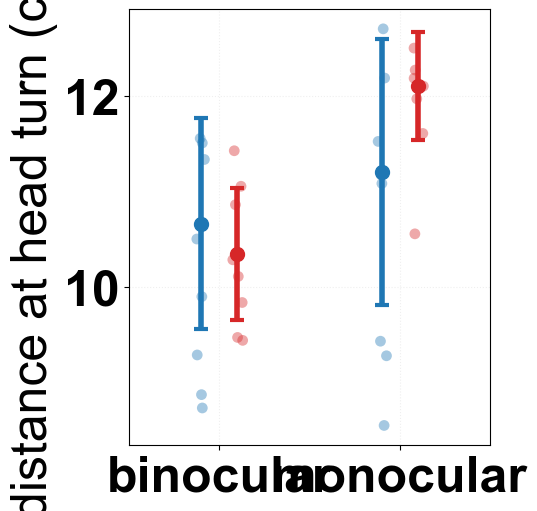

In [53]:
fig, ax = plt.subplots(figsize=(6, 6))

# Prepare data (same as before)
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.distance_at_head_turn>=0] 

binocular_left = mon[(mon.task == 'oa') & (mon.turn_direction_left_right == 'left')]
binocular_right = mon[(mon.task == 'oa') & (mon.turn_direction_left_right == 'right')]
monocular_left = mon[(mon.task == 'oamonle') & (mon.turn_direction_left_right == 'left')]
monocular_right = mon[(mon.task == 'oamonle') & (mon.turn_direction_left_right == 'right')]

# Calculate means and std (same as before)
means = {
    'binocular_left': binocular_left.distance_at_head_turn.mean(),
    'binocular_right': binocular_right.distance_at_head_turn.mean(),
    'monocular_left': monocular_left.distance_at_head_turn.mean(),
    'monocular_right': monocular_right.distance_at_head_turn.mean()
}

stds = {
    'binocular_left': np.nanstd(binocular_left.groupby(['animal']).distance_at_head_turn.mean().to_numpy()),
    'binocular_right': np.nanstd(binocular_right.groupby(['animal']).distance_at_head_turn.mean().to_numpy()),
    'monocular_left': np.nanstd(monocular_left.groupby(['animal']).distance_at_head_turn.mean().to_numpy()),
    'monocular_right': np.nanstd(monocular_right.groupby(['animal']).distance_at_head_turn.mean().to_numpy())
}

# Adjusted positions - moved inward
x_pos = [0.9, 1.1, 1.9, 2.1]  # More centered within each condition

# Plot individual points with adjusted jitter
for i, (name, group) in enumerate([('binocular_left', binocular_left),
                                  ('binocular_right', binocular_right),
                                  ('monocular_left', monocular_left),
                                  ('monocular_right', monocular_right)]):
    color = 'tab:blue' if 'left' in name else 'tab:red'
    individual_means = group.groupby(['animal']).distance_at_head_turn.mean().to_numpy()
    # Reduced jitter range
    jitter = np.random.uniform(-0.03, 0.03, size=len(individual_means))
    ax.scatter(x_pos[i] + jitter, individual_means,
              color=color, alpha=0.4, s=60, edgecolor='none')

# Plot means and error bars
ax.errorbar(x_pos[0], means['binocular_left'], yerr=stds['binocular_left'],
           fmt='o', color='tab:blue', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='left turns')
ax.errorbar(x_pos[1], means['binocular_right'], yerr=stds['binocular_right'],
           fmt='o', color='tab:red', markersize=10, capsize=5,
           capthick=3, elinewidth=4, label='right turns')
ax.errorbar(x_pos[2], means['monocular_left'], yerr=stds['monocular_left'],
           fmt='o', color='tab:blue', markersize=10, capsize=5,
           capthick=3, elinewidth=4)
ax.errorbar(x_pos[3], means['monocular_right'], yerr=stds['monocular_right'],
           fmt='o', color='tab:red', markersize=10, capsize=5,
           capthick=3, elinewidth=4)

# Formatting with adjusted margins
ax.set_xlim(0.5, 2.5)  # Creates space on both sides
ax.set_xticks([1, 2], ['binocular', 'monocular'])
ax.set_ylabel('distance at head turn (cm)')


# Add subtle grid for better readability
ax.grid(True, linestyle=':', alpha=0.2)

plt.tight_layout()
plt.show()

In [33]:
mon.animal.unique()

array(['J701LT', 'J701RT', 'J701NN', 'J701RN', 'J704RT', 'J704NN',
       'J704LT', 'J704LN'], dtype=object)

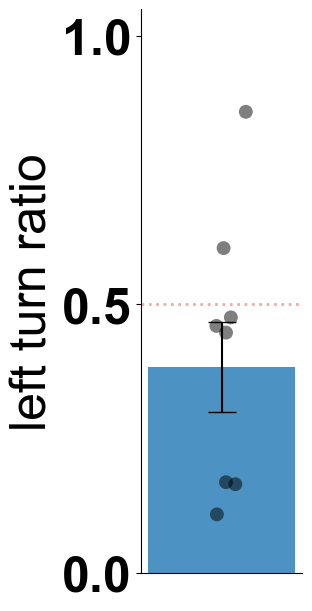

In [95]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 

data = data[data.task=='oamonle'] 
light_data = data

# Group level calculation
total = len(light_data)
left = len(light_data[light_data['turn_direction_left_right'] == 'left']) if total > 0 else 0
ratio = left / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
    a_ratio = a_left / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue' 
x_pos = 0  # Single bar position

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\left_ratio_light_bar.pdf",dpi = 300, transparent=True)
plt.show()

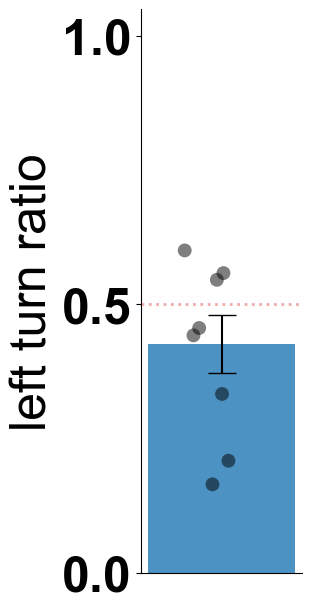

In [94]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 

data = data[data.task=='oa'] 
light_data = data

# Group level calculation
total = len(light_data)
left = len(light_data[light_data['turn_direction_left_right'] == 'left']) if total > 0 else 0
ratio = left / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
    a_ratio = a_left / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue' 
x_pos = 0  # Single bar position

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\left_ratio_light_bar.pdf",dpi = 300, transparent=True)
plt.show()

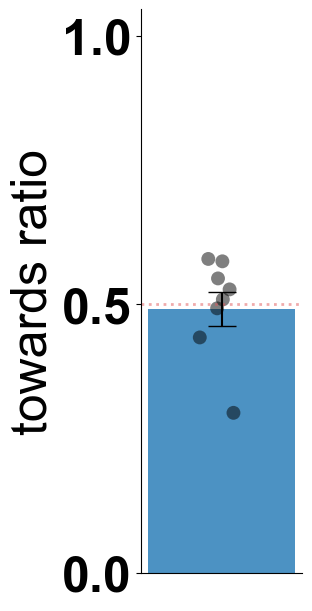

In [97]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))  # Narrower figure for single bar

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 

data = data[data.task=='oamonle'] 
light_data = data

# Group level calculation
total = len(light_data)
towards = len(light_data[light_data['turn_to_obstacle'] == 'towards']) if total > 0 else 0
ratio = towards / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_towards = len(animal_data[animal_data['turn_to_obstacle'] == 'towards']) if a_total > 0 else 0
    a_ratio = a_towards / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue'
x_pos = 0  # Single bar position

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)  # Larger cap size for single bar

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))  # Slightly wider jitter
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')  # Larger points

# Customize plot
ax.set_ylabel('towards ratio')
ax.set_xticks([])  # Remove x-axis ticks since we only have one bar
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove grid and frame elements
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\towards_ratio_light_bar.pdf",dpi = 300, transparent=True)
plt.show()

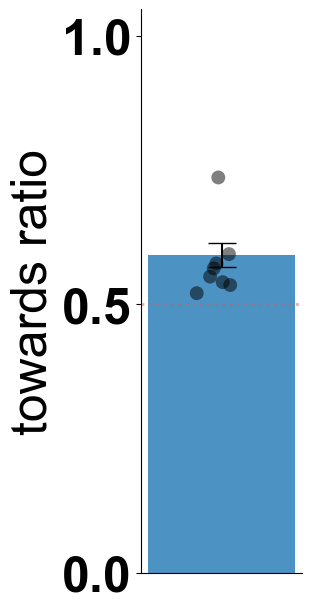

In [92]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))  # Narrower figure for single bar

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 

data = data[data.task=='oa'] 
light_data = data

# Group level calculation
total = len(light_data)
towards = len(light_data[light_data['turn_to_obstacle'] == 'towards']) if total > 0 else 0
ratio = towards / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_towards = len(animal_data[animal_data['turn_to_obstacle'] == 'towards']) if a_total > 0 else 0
    a_ratio = a_towards / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue'
x_pos = 0  # Single bar position

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)  # Larger cap size for single bar

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))  # Slightly wider jitter
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')  # Larger points

# Customize plot
ax.set_ylabel('towards ratio')
ax.set_xticks([])  # Remove x-axis ticks since we only have one bar
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove grid and frame elements
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\towards_ratio_light_bar.pdf",dpi = 300, transparent=True)
plt.show()

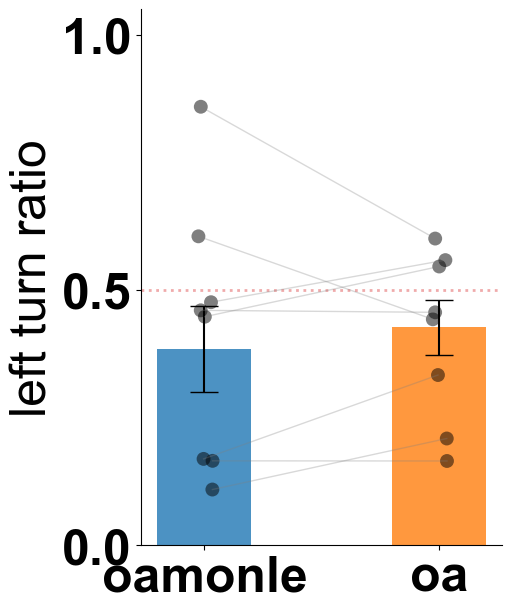

In [ ]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(6, 7))  # Wider figure to accommodate two bars

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 


# Get data for both tasks
oamonle_data = data[data.task=='oamonle'] 
oa_data = data[data.task=='oa']

# Function to calculate ratios
def calculate_ratios(df):
    # Group level calculation
    total = len(df)
    left = len(df[df['turn_direction_left_right'] == 'left']) if total > 0 else 0
    ratio = left / total if total > 0 else 0
    
    # Individual animal calculation
    animal_ratios = {}
    for animal in df['animal'].unique():
        animal_data = df[df['animal'] == animal]
        a_total = len(animal_data)
        a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
        a_ratio = a_left / a_total if a_total > 0 else 0
        animal_ratios[animal] = a_ratio
    
    # Calculate standard error
    se = np.std(list(animal_ratios.values())) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    
    return ratio, animal_ratios, se

# Calculate for both conditions
oamonle_ratio, oamonle_animal_ratios, oamonle_se = calculate_ratios(oamonle_data)
oa_ratio, oa_animal_ratios, oa_se = calculate_ratios(oa_data)

# Plot settings
bar_width = 0.4
colors = ['tab:blue', 'tab:orange'] 
x_positions = [0, 1]  # Positions for the two bars

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bars with error bars
for x, ratio, se, color, label in zip(x_positions, 
                                     [oamonle_ratio, oa_ratio], 
                                     [oamonle_se, oa_se], 
                                     colors, 
                                     ['oamonle', 'oa']):
    ax.bar(x, ratio, bar_width,
           color=color,
           edgecolor='none',
           alpha=0.8,
           yerr=se,
           capsize=10,
           label=label)

# Plot individual data points with connecting lines
all_animals = set(oamonle_animal_ratios.keys()).union(set(oa_animal_ratios.keys()))
for animal in all_animals:
    # Get ratios for both conditions (use None if animal not in condition)
    y_oamonle = oamonle_animal_ratios.get(animal, None)
    y_oa = oa_animal_ratios.get(animal, None)
    
    # Add jitter to x positions
    jitter = np.random.normal(0, 0.03)
    
    # Plot points and connecting line if both values exist
    if y_oamonle is not None and y_oa is not None:
        ax.plot([x_positions[0] + jitter, x_positions[1] + jitter], 
                [y_oamonle, y_oa], 
                color='gray', alpha=0.3, linewidth=1)
    
    # Plot points
    if y_oamonle is not None:
        ax.scatter(x_positions[0] + jitter, y_oamonle,
                  color='black', alpha=0.5, s=100, edgecolor='none')
    if y_oa is not None:
        ax.scatter(x_positions[1] + jitter, y_oa,
                  color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(['oamonle', 'oa'])
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\left_ratio_comparison.pdf", dpi=300, transparent=True)
plt.show()

In [ ]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(6, 7))  # Wider figure to accommodate two bars

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.tortuosity<1.5]

# Get data for both tasks (switched order)
oa_data = data[data.task=='oa']
oamonle_data = data[data.task=='oamonle'] 

# Function to calculate ratios
def calculate_ratios(df):
    # Group level calculation
    total = len(df)
    left = len(df[df['turn_direction_left_right'] == 'left']) if total > 0 else 0
    ratio = left / total if total > 0 else 0
    
    # Individual animal calculation
    animal_ratios = {}
    for animal in df['animal'].unique():
        animal_data = df[df['animal'] == animal]
        a_total = len(animal_data)
        a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
        a_ratio = a_left / a_total if a_total > 0 else 0
        animal_ratios[animal] = a_ratio
    
    # Calculate standard error
    se = np.std(list(animal_ratios.values())) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    
    return ratio, animal_ratios, se

# Calculate for both conditions (switched order)
oa_ratio, oa_animal_ratios, oa_se = calculate_ratios(oa_data)
oamonle_ratio, oamonle_animal_ratios, oamonle_se = calculate_ratios(oamonle_data)

# Plot settings
bar_width = 0.4
colors = ['tab:orange', 'tab:blue']  # Switched colors to match new order
x_positions = [0, 1]  # Positions for the two bars

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bars with error bars (switched order)
for x, ratio, se, color, label in zip(x_positions, 
                                     [oa_ratio, oamonle_ratio],  # Switched order
                                     [oa_se, oamonle_se], 
                                     colors, 
                                     ['oa', 'oamonle']):  # Switched labels
    ax.bar(x, ratio, bar_width,
           color=color,
           edgecolor='none',
           alpha=0.8,
           yerr=se,
           capsize=10,
           label=label)

# Plot individual data points with connecting lines
all_animals = set(oa_animal_ratios.keys()).union(set(oamonle_animal_ratios.keys()))
for animal in all_animals:
    # Get ratios for both conditions (use None if animal not in condition)
    y_oa = oa_animal_ratios.get(animal, None)
    y_oamonle = oamonle_animal_ratios.get(animal, None)
    
    # Add jitter to x positions
    jitter = np.random.normal(0, 0.03)
    
    # Plot points and connecting line if both values exist
    if y_oa is not None and y_oamonle is not None:
        ax.plot([x_positions[0] + jitter, x_positions[1] + jitter], 
                [y_oa, y_oamonle], 
                color='gray', alpha=0.3, linewidth=1)
    
    # Plot points (switched order)
    if y_oa is not None:
        ax.scatter(x_positions[0] + jitter, y_oa,
                  color='black', alpha=0.5, s=100, edgecolor='none')
    if y_oamonle is not None:
        ax.scatter(x_positions[1] + jitter, y_oamonle,
                  color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(['oa', 'oamonle'])  # Switched labels
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)



plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\left_ratio_comparison_switched.pdf", dpi=300, transparent=True)
plt.show()

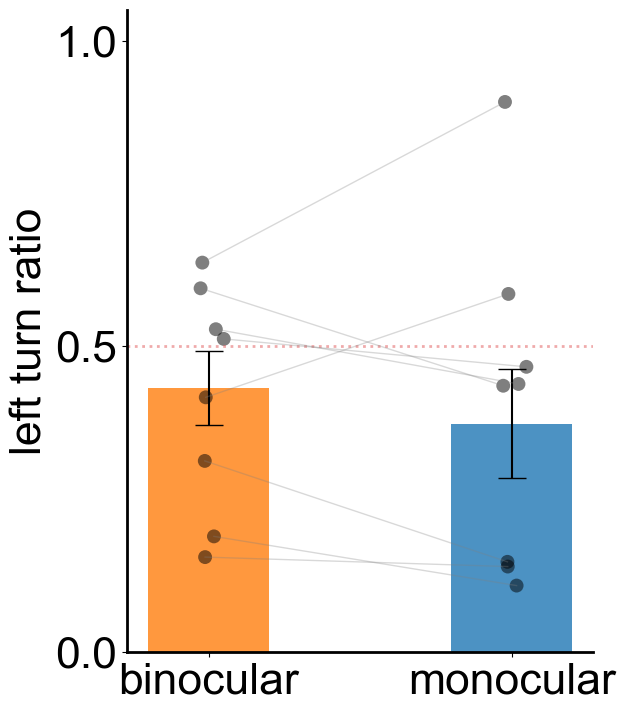

In [476]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(7, 8))  # Wider figure to accommodate two bars

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#
#data = data[data.intial_lateral_error<0] 



# Get data for both tasks (switched order)
oa_data = data[data.task=='oa']
oamonle_data = data[data.task=='oamonle'] 

# Function to calculate ratios
def calculate_ratios(df):
    # Group level calculation
    total = len(df)
    left = len(df[df['turn_direction_left_right'] == 'left']) if total > 0 else 0
    ratio = left / total if total > 0 else 0
    
    # Individual animal calculation
    animal_ratios = {}
    for animal in df['animal'].unique():
        animal_data = df[df['animal'] == animal]
        a_total = len(animal_data)
        a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
        a_ratio = a_left / a_total if a_total > 0 else 0
        animal_ratios[animal] = a_ratio
    
    # Calculate standard error
    se = np.std(list(animal_ratios.values())) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    
    return ratio, animal_ratios, se

# Calculate for both conditions (switched order)
oa_ratio, oa_animal_ratios, oa_se = calculate_ratios(oa_data)
oamonle_ratio, oamonle_animal_ratios, oamonle_se = calculate_ratios(oamonle_data)

# Plot settings
bar_width = 0.4
colors = ['tab:orange', 'tab:blue']  # Switched colors to match new order
x_positions = [0, 1]  # Positions for the two bars

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bars with error bars (switched order)
for x, ratio, se, color, label in zip(x_positions, 
                                     [oa_ratio, oamonle_ratio],  # Switched order
                                     [oa_se, oamonle_se], 
                                     colors, 
                                     ['oa', 'oamonle']):  # Switched labels
    ax.bar(x, ratio, bar_width,
           color=color,
           edgecolor='none',
           alpha=0.8,
           yerr=se,
           capsize=10,
           label=label)

# Plot individual data points with connecting lines
all_animals = set(oa_animal_ratios.keys()).union(set(oamonle_animal_ratios.keys()))
for animal in all_animals:
    # Get ratios for both conditions (use None if animal not in condition)
    y_oa = oa_animal_ratios.get(animal, None)
    y_oamonle = oamonle_animal_ratios.get(animal, None)
    
    # Add jitter to x positions
    jitter = np.random.normal(0, 0.03)
    
    # Plot points and connecting line if both values exist
    if y_oa is not None and y_oamonle is not None:
        ax.plot([x_positions[0] + jitter, x_positions[1] + jitter], 
                [y_oa, y_oamonle], 
                color='gray', alpha=0.3, linewidth=1)
    
    # Plot points (switched order)
    if y_oa is not None:
        ax.scatter(x_positions[0] + jitter, y_oa,
                  color='black', alpha=0.5, s=100, edgecolor='none')
    if y_oamonle is not None:
        ax.scatter(x_positions[1] + jitter, y_oamonle,
                  color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(['binocular', 'monocular'])  # Switched labels
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)



plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_6\left_ratio_mon.pdf", dpi=300, transparent=True)
plt.show()

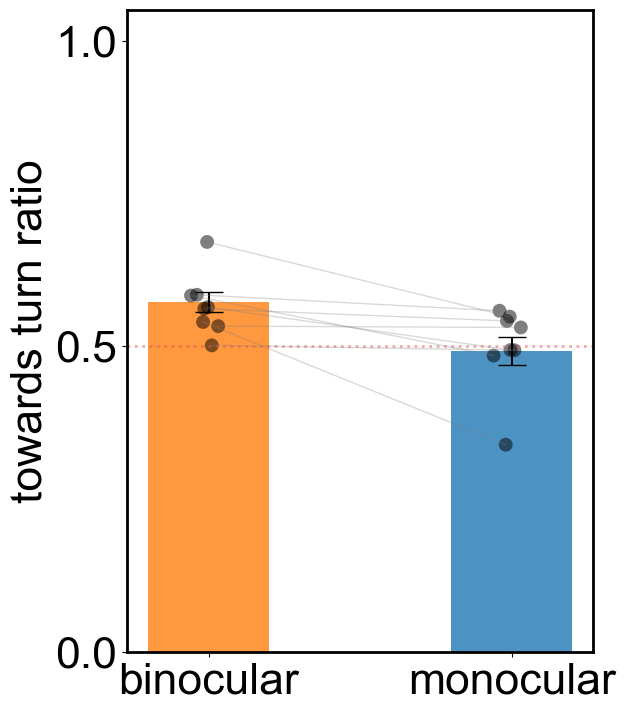

In [471]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(7, 8))  # Wider figure to accommodate two bars

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
#data = data[data.intial_lateral_error<0] 



# Get data for both tasks (switched order)
oa_data = data[data.task=='oa']
oamonle_data = data[data.task=='oamonle'] 

# Function to calculate ratios
def calculate_ratios(df):
    # Group level calculation
    total = len(df)
    towards = len(df[df['turn_to_obstacle'] == 'towards']) if total > 0 else 0
    ratio = towards / total if total > 0 else 0
    
    # Individual animal calculation
    animal_ratios = {}
    for animal in df['animal'].unique():
        animal_data = df[df['animal'] == animal]
        a_total = len(animal_data)
        a_towards = len(animal_data[animal_data['turn_to_obstacle'] == 'towards']) if a_total > 0 else 0
        a_ratio = a_towards / a_total if a_total > 0 else 0
        animal_ratios[animal] = a_ratio
    
    # Calculate standard error
    se = np.std(list(animal_ratios.values())) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    
    return ratio, animal_ratios, se

# Calculate for both conditions (switched order)
oa_ratio, oa_animal_ratios, oa_se = calculate_ratios(oa_data)
oamonle_ratio, oamonle_animal_ratios, oamonle_se = calculate_ratios(oamonle_data)

# Plot settings
bar_width = 0.4
colors = ['tab:orange', 'tab:blue']  # Switched colors to match new order
x_positions = [0, 1]  # Positions for the two bars

# Plot 50% reference line (chance level for towards/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bars with error bars (switched order)
for x, ratio, se, color, label in zip(x_positions, 
                                     [oa_ratio, oamonle_ratio],  # Switched order
                                     [oa_se, oamonle_se], 
                                     colors, 
                                     ['oa', 'oamonle']):  # Switched labels
    ax.bar(x, ratio, bar_width,
           color=color,
           edgecolor='none',
           alpha=0.8,
           yerr=se,
           capsize=10,
           label=label)

# Plot individual data points with connecting lines
all_animals = set(oa_animal_ratios.keys()).union(set(oamonle_animal_ratios.keys()))
for animal in all_animals:
    # Get ratios for both conditions (use None if animal not in condition)
    y_oa = oa_animal_ratios.get(animal, None)
    y_oamonle = oamonle_animal_ratios.get(animal, None)
    
    # Add jitter to x positions
    jitter = np.random.normal(0, 0.03)
    
    # Plot points and connecting line if both values exist
    if y_oa is not None and y_oamonle is not None:
        ax.plot([x_positions[0] + jitter, x_positions[1] + jitter], 
                [y_oa, y_oamonle], 
                color='gray', alpha=0.3, linewidth=1)
    
    # Plot points (switched order)
    if y_oa is not None:
        ax.scatter(x_positions[0] + jitter, y_oa,
                  color='black', alpha=0.5, s=100, edgecolor='none')
    if y_oamonle is not None:
        ax.scatter(x_positions[1] + jitter, y_oamonle,
                  color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('towards turn ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(['binocular', 'monocular'])  # Switched labels
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility




plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\towards_ratio_comparison_switched.pdf", dpi=300, transparent=True)
plt.show()

<AxesSubplot: >

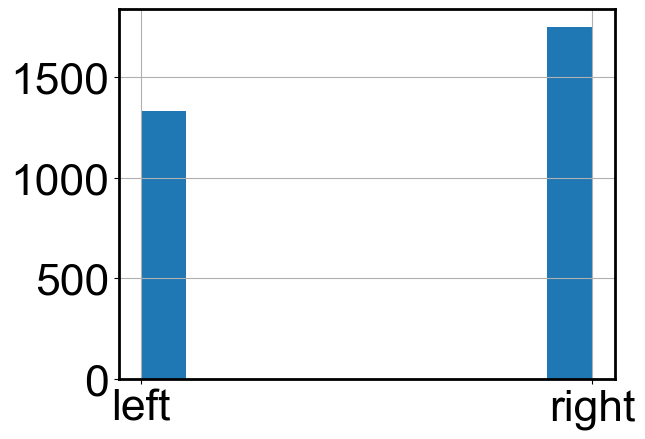

In [477]:
oa_data.turn_direction_left_right.hist()

<AxesSubplot: >

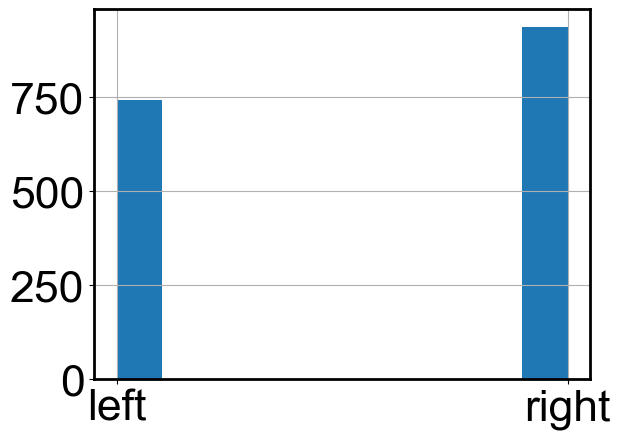

In [475]:
oa_data.turn_direction_left_right.hist()

<AxesSubplot: >

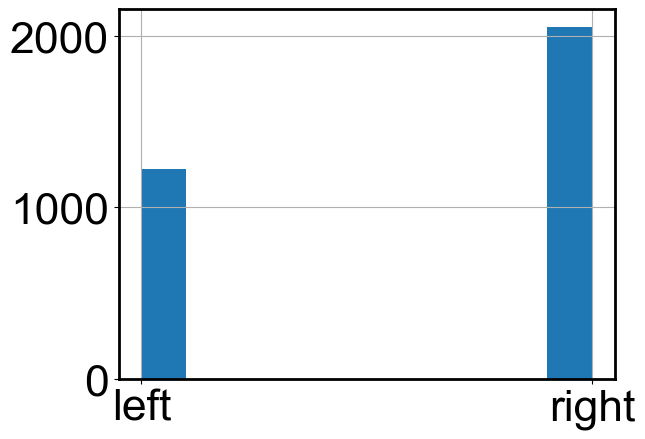

In [478]:
oamonle_data.turn_direction_left_right.hist()

<AxesSubplot: >

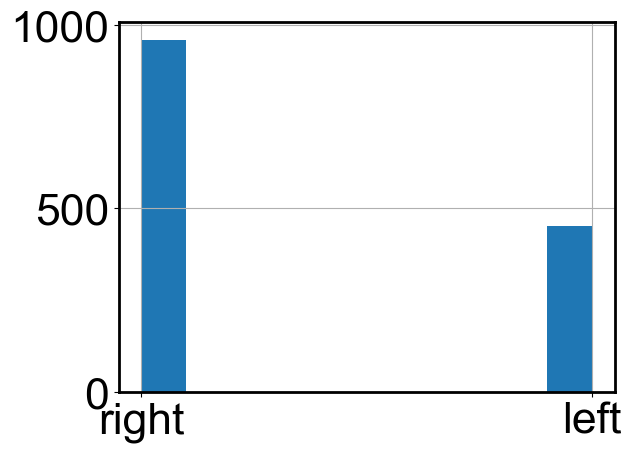

In [474]:
oamonle_data.turn_direction_left_right.hist()

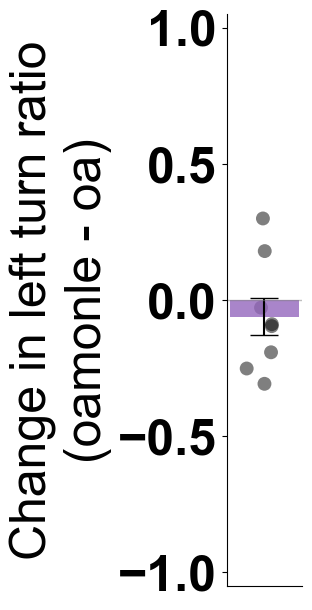

Average change: -0.061 ± 0.069 (SEM)
Number of animals: 8
Individual changes: ['-0.193', '-0.252', '-0.097', '-0.029', '0.299', '-0.309', '0.179', '-0.090']


In [104]:
# Calculate individual changes in left turn ratio
changes = []
for animal in all_animals:
    y_oa = oa_animal_ratios.get(animal, None)
    y_oamonle = oamonle_animal_ratios.get(animal, None)
    if y_oa is not None and y_oamonle is not None:
        changes.append(y_oamonle - y_oa)

# Calculate average change and standard error
avg_change = np.mean(changes) if changes else 0
se_change = np.std(changes)/np.sqrt(len(changes)) if changes else 0

# Create figure for change plot
fig_change, ax_change = plt.subplots(figsize=(4, 7))
plt.rc('font', **font)

# Plot individual changes with jitter
jitter = np.random.normal(0, 0.05, size=len(changes))
ax_change.scatter(np.zeros(len(changes)) + jitter, changes,
                color='black', alpha=0.5, s=100, edgecolor='none')

# Plot average change with error bar
ax_change.bar(0, avg_change, bar_width,
             color='tab:purple',
             edgecolor='none',
             alpha=0.8,
             yerr=se_change,
             capsize=10)

# Plot zero reference line
ax_change.axhline(0, color='gray', linestyle='-', alpha=0.5, linewidth=1)

# Customize change plot
ax_change.set_ylabel('Change in left turn ratio\n(oamonle - oa)')
ax_change.set_xticks([])
ax_change.set_ylim(-1.05, 1.05)
ax_change.set_yticks([-1, -0.5, 0, 0.5, 1])

# Remove unnecessary spines
ax_change.grid(False)
for spine in ['left', 'bottom']:
    ax_change.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax_change.spines[spine].set_visible(False)

plt.tight_layout()
#fig_change.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\left_ratio_change.pdf", dpi=300, transparent=True)
plt.show()

# Print summary statistics
print(f"Average change: {avg_change:.3f} ± {se_change:.3f} (SEM)")
print(f"Number of animals: {len(changes)}")
print("Individual changes:", [f"{c:.3f}" for c in changes])

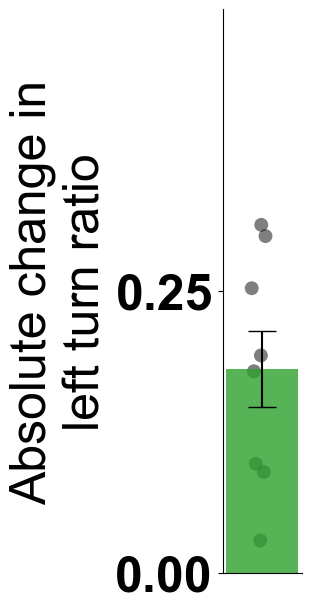

Average absolute change: 0.181 ± 0.034 (SEM)
Number of animals: 8
Individual absolute changes: ['0.193', '0.252', '0.097', '0.029', '0.299', '0.309', '0.179', '0.090']


In [108]:
# Calculate individual ABSOLUTE changes in left turn ratio
abs_changes = []
for animal in all_animals:
    y_oa = oa_animal_ratios.get(animal, None)
    y_oamonle = oamonle_animal_ratios.get(animal, None)
    if y_oa is not None and y_oamonle is not None:
        abs_changes.append(abs(y_oamonle - y_oa))  # Using absolute value here

# Calculate average absolute change and standard error
avg_abs_change = np.mean(abs_changes) if abs_changes else 0
se_abs_change = np.std(abs_changes)/np.sqrt(len(abs_changes)) if abs_changes else 0

# Create figure for absolute change plot
fig_abs_change, ax_abs_change = plt.subplots(figsize=(4, 7))
plt.rc('font', **font)

# Plot individual absolute changes with jitter
jitter = np.random.normal(0, 0.05, size=len(abs_changes))
ax_abs_change.scatter(np.zeros(len(abs_changes)) + jitter, abs_changes,
                     color='black', alpha=0.5, s=100, edgecolor='none')

# Plot average absolute change with error bar
ax_abs_change.bar(0, avg_abs_change, bar_width,
                 color='tab:green',  # Using different color for absolute changes
                 edgecolor='none',
                 alpha=0.8,
                 yerr=se_abs_change,
                 capsize=10)

# Customize absolute change plot
ax_abs_change.set_ylabel('Absolute change in\nleft turn ratio')
ax_abs_change.set_xticks([])
ax_abs_change.set_ylim(0, .5)  # Absolute changes are always positive
ax_abs_change.set_yticks([0, 0.25,])

# Remove unnecessary spines
ax_abs_change.grid(False)
for spine in ['left', 'bottom']:
    ax_abs_change.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax_abs_change.spines[spine].set_visible(False)

plt.tight_layout()
#fig_abs_change.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\left_ratio_absolute_change.pdf", dpi=300, transparent=True)
plt.show()

# Print summary statistics
print(f"Average absolute change: {avg_abs_change:.3f} ± {se_abs_change:.3f} (SEM)")
print(f"Number of animals: {len(abs_changes)}")
print("Individual absolute changes:", [f"{c:.3f}" for c in abs_changes])

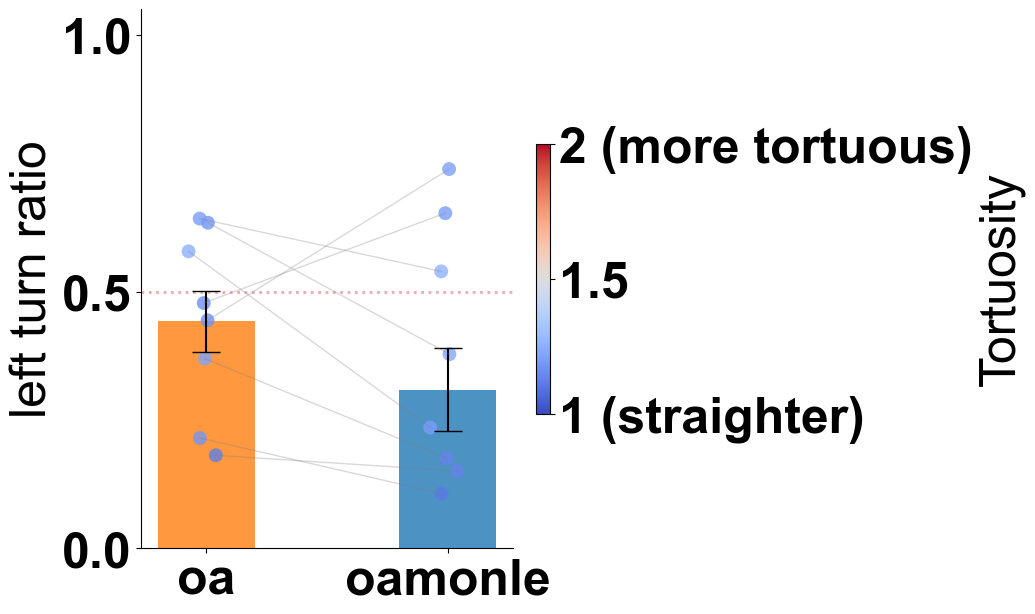

In [76]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(6, 7))  # Wider figure to accommodate two bars

# Prepare data - using light_dark dataframe and filtering for light condition
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.tortuosity<2]

# Get data for both tasks (switched order)
oa_data = data[data.task=='oa']
oamonle_data = data[data.task=='oamonle'] 

# Function to calculate ratios and average tortuosity
def calculate_ratios(df):
    # Group level calculation
    total = len(df)
    left = len(df[df['turn_direction_left_right'] == 'left']) if total > 0 else 0
    ratio = left / total if total > 0 else 0
    
    # Individual animal calculation
    animal_ratios = {}
    animal_tortuosity = {}  # Store average tortuosity per animal
    for animal in df['animal'].unique():
        animal_data = df[df['animal'] == animal]
        a_total = len(animal_data)
        a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
        a_ratio = a_left / a_total if a_total > 0 else 0
        animal_ratios[animal] = a_ratio
        # Calculate average tortuosity for this animal
        animal_tortuosity[animal] = animal_data['tortuosity'].mean()
    
    # Calculate standard error
    se = np.std(list(animal_ratios.values())) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    
    return ratio, animal_ratios, animal_tortuosity, se

# Calculate for both conditions (switched order)
oa_ratio, oa_animal_ratios, oa_animal_tortuosity, oa_se = calculate_ratios(oa_data)
oamonle_ratio, oamonle_animal_ratios, oamonle_animal_tortuosity, oamonle_se = calculate_ratios(oamonle_data)

# Plot settings
bar_width = 0.4
colors = ['tab:orange', 'tab:blue']  # Switched colors to match new order
x_positions = [0, 1]  # Positions for the two bars

# Create colormap from red (1) to blue (2)
cmap = plt.get_cmap('coolwarm')
norm = plt.Normalize(vmin=1, vmax=2)

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bars with error bars (switched order)
for x, ratio, se, color, label in zip(x_positions, 
                                     [oa_ratio, oamonle_ratio],  # Switched order
                                     [oa_se, oamonle_se], 
                                     colors, 
                                     ['oa', 'oamonle']):  # Switched labels
    ax.bar(x, ratio, bar_width,
           color=color,
           edgecolor='none',
           alpha=0.8,
           yerr=se,
           capsize=10,
           label=label)

# Plot individual data points with connecting lines and colored by tortuosity
all_animals = set(oa_animal_ratios.keys()).union(set(oamonle_animal_ratios.keys()))
for animal in all_animals:
    # Get ratios for both conditions (use None if animal not in condition)
    y_oa = oa_animal_ratios.get(animal, None)
    y_oamonle = oamonle_animal_ratios.get(animal, None)
    
    # Get tortuosity values
    tort_oa = oa_animal_tortuosity.get(animal, 1.5)  # Default if not found
    tort_oamonle = oamonle_animal_tortuosity.get(animal, 1.5)  # Default if not found
    
    # Add jitter to x positions
    jitter = np.random.normal(0, 0.03)
    
    # Plot points and connecting line if both values exist
    if y_oa is not None and y_oamonle is not None:
        ax.plot([x_positions[0] + jitter, x_positions[1] + jitter], 
                [y_oa, y_oamonle], 
                color='gray', alpha=0.3, linewidth=1)
    
    # Plot points (switched order) with color based on tortuosity
    if y_oa is not None:
        ax.scatter(x_positions[0] + jitter, y_oa,
                  color=cmap(norm(tort_oa)), 
                  alpha=0.8, s=100, edgecolor='none')
    if y_oamonle is not None:
        ax.scatter(x_positions[1] + jitter, y_oamonle,
                  color=cmap(norm(tort_oamonle)), 
                  alpha=0.8, s=100, edgecolor='none')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5)
cbar.set_label('Tortuosity')
cbar.set_ticks([1, 1.5, 2])
cbar.set_ticklabels(['1 (straighter)', '1.5', '2 (more tortuous)'])

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(['oa', 'oamonle'])  # Switched labels
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\left_ratio_comparison_tortuosity.pdf", dpi=300, transparent=True)
plt.show()

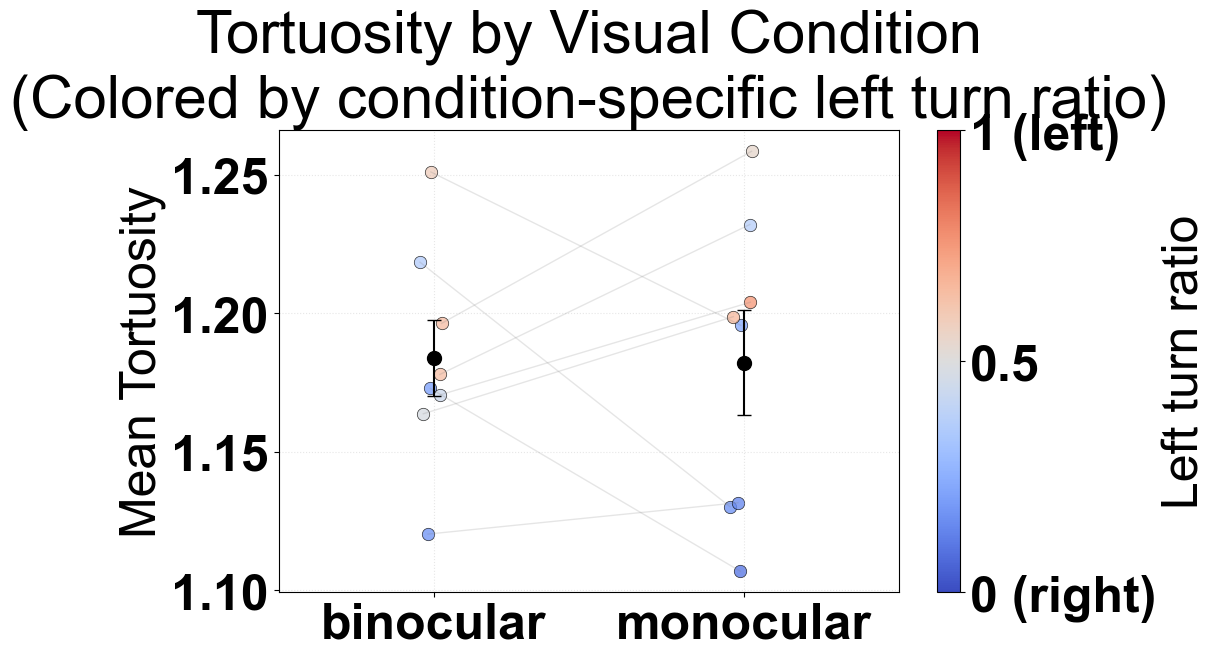

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming you have a DataFrame 'data' with the data
fig, ax = plt.subplots(figsize=(10, 6))

# --- Data preparation ---
data = pd.concat([mon])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[~data['obstacle_cluster'].isin([2,3])] 
data = data[data.intial_distance>=15] 
data = data[data.intial_lateral_error<0] 
data = data[data.tortuosity<2]
binocular_data = data[data.task == 'oa']
monocular_data = data[data.task == 'oamonle']

# Calculate mean tortuosity per animal per condition
binocular_tort = binocular_data.groupby('animal')['tortuosity'].mean()
monocular_tort = monocular_data.groupby('animal')['tortuosity'].mean()

# Calculate left turn ratios for coloring
def calculate_lr_ratios(df):
    grouped = df.groupby(['animal', 'turn_direction_left_right']).size().unstack(fill_value=0)
    grouped['left_ratio'] = grouped['left'] / (grouped['left'] + grouped['right'])
    return grouped

binocular_lr = calculate_lr_ratios(binocular_data)
monocular_lr = calculate_lr_ratios(monocular_data)

common_animals = binocular_tort.index.intersection(monocular_tort.index)

# --- Create a colormap ---
cmap = plt.cm.coolwarm  # Blue (cool) to red (warm)
norm = plt.Normalize(vmin=0, vmax=1)  # Left ratio ranges from 0 to 1

# --- Plotting ---
x_positions = [1, 2]  # binocular and monocular positions

# Plot individual points and connecting lines
for animal in common_animals:
    # Get left ratios for both conditions
    binoc_ratio = binocular_lr.loc[animal, 'left_ratio']
    monoc_ratio = monocular_lr.loc[animal, 'left_ratio']
    
    # Add slight jitter to x positions
    jitter = np.random.uniform(-0.05, 0.05)
    
    # Connect points between conditions
    ax.plot([x_positions[0]+jitter, x_positions[1]+jitter],
            [binocular_tort[animal], monocular_tort[animal]],
            color='gray', alpha=0.2, linewidth=1)
    
    # Plot individual points with condition-specific colors
    ax.scatter(x_positions[0]+jitter, binocular_tort[animal],
              color=cmap(norm(binoc_ratio)), alpha=0.8, s=80, 
              edgecolor='k', linewidth=0.5)
    ax.scatter(x_positions[1]+jitter, monocular_tort[animal],
              color=cmap(norm(monoc_ratio)), alpha=0.8, s=80,
              edgecolor='k', linewidth=0.5)

# Plot means and SEM error bars (in black for visibility)
ax.errorbar(x_positions[0], binocular_tort.mean(), 
            yerr=binocular_tort.sem(),
            fmt='o', color='black', markersize=10, capsize=5)
ax.errorbar(x_positions[1], monocular_tort.mean(), 
            yerr=monocular_tort.sem(),
            fmt='o', color='black', markersize=10, capsize=5)

# --- Customize the plot ---
ax.set_xticks(x_positions, ['binocular', 'monocular'])
ax.set_xlim(0.5, 2.5)
ax.set_ylabel('Mean Tortuosity')
ax.set_title('Tortuosity by Visual Condition\n(Colored by condition-specific left turn ratio)')

# Add colorbar to show left turn ratio values
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Left turn ratio')
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['0 (right)', '0.5', '1 (left)'])

ax.grid(True, linestyle=':', alpha=0.3)

plt.show()

In [98]:
con_df = create_consective_df_new(mon)

In [99]:
con_df

,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,positive_peaks,positive_heights,positive_left_ips,positive_right_ips,negative_peaks,negative_heights,negative_left_ips,negative_right_ips,consective_inds,consective_type
0,1,49298.501760,49300.754560,"[49298.508697, 49298.525606, 49298.542284, 492...","[[161, 162, 163, 164, 165, 166, 167, 168, 169,...","[648.7608642578125, 648.171630859375, 646.2357...","[280.55023193359375, 280.0666809082031, 278.73...","[635.47509765625, 633.7139892578125, 631.65777...","[270.6003112792969, 269.8623046875, 270.001159...","[640.41650390625, 639.1555786132812, 637.68518...",...,[39],[5.720048890695978],[37.09777368494302],[41.9489892980184],"[2, 14, 23]","[-6.06434430519478, -1.8255503428342466, -4.27...","[0.6109387984303355, 13.183464111592967, 19.07...","[3.366336523972994, 15.663548999810285, 26.933...","[0, 1, 2]",0
1,2,49300.754560,49308.750784,"[49300.759539, 49300.777062, 49300.793177, 493...","[296, 297, 298, 299, 300, 301, 302, 303, 304, ...","[68.82037353515625, 67.99369049072266, 67.1418...","[254.095458984375, 254.76304626464844, 253.994...","[74.49559783935547, 73.134521484375, 72.229621...","[258.2629699707031, 259.42425537109375, 258.65...","[76.09281158447266, 75.02220916748047, 73.9580...",...,"[2, 13]","[3.1060173642108917, 0.9600593674513583]","[0.5383869325212488, 10.431010649301836]","[2.937411980466693, 15.615993597365277]","[8, 19]","[-0.389509191933618, -1.005760660079695]","[5.6647208866511924, 18.566259112795667]","[10.431010649301836, 19.5]","[0, 1, 2]",1
2,3,49308.750784,49313.531238,"[49308.762355, 49308.779136, 49308.79639, 4930...","[[776, 777, 778, 779, 780, 781, 782, 783, 784,...","[648.4093627929688, 649.1452026367188, 649.393...","[281.964111328125, 281.29827880859375, 281.502...","[633.6756591796875, 634.7064819335938, 634.492...","[275.03497314453125, 274.42974853515625, 274.4...","[641.36376953125, 642.6102905273438, 642.93255...",...,"[1, 7, 13, 24, 33]","[1.4258805735009927, 0.43504701427308334, 0.05...","[0.5, 5.928266647697955, 11.973430672790146, 2...","[2.1372516016508434, 7.8372173687703075, 14.32...","[11, 17]","[-0.2533550162007592, -0.5285631893887666]","[9.558633019362658, 3.803524676810539]","[11.973430672790146, 19.733821252770433]","[0, 1, 2]",2
3,4,49313.531238,49317.074598,"[49313.547622, 49313.564876, 49313.581056, 493...","[1063, 1064, 1065, 1066, 1067, 1068, 1069, 107...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[72.60108184814453, 71.69328308105469, 71.4748...","[260.7366638183594, 261.4021911621094, 261.238...","[77.22979736328125, 75.19596099853516, 74.4435...",...,"[28, 38, 62, 81]","[1.2634109545020422, 1.9856558967879434, 0.290...","[26.74844354033088, 23.538789991863688, 59.506...","[29.339687810462806, 49.720851771269864, 64.98...","[5, 20, 53, 56, 70]","[-8.01002129506776, -2.2809954540809674, -1.71...","[2.270746503048173, 19.5, 49.769899754316505, ...","[10.069174654594786, 20.12156945532645, 59.506...","[3, 4, 5, 6]",0
4,5,49317.074598,49320.040217,"[49317.081907, 49317.098611, 49317.115443, 493...","[[1275, 1276, 1277, 1278, 1279, 1280, 1281, 12...","[647.1571655273438, 647.306884765625, 648.4654...","[279.1477966308594, 278.3889465332031, 278.109...","[636.057373046875, 636.6192016601562, 638.1153...","[264.35687255859375, 264.09259033203125, 263.5...","[634.3810424804688, 635.1669311523438, 636.076...",...,"[8, 28, 48]","[0.21697859219113047, 0.06622585868823805, 4.8...","[4.494096772705207, 26.567468912047858, 47.933...","[15.185469714924704, 30.251351787990586, 48.50...","[2, 12, 21, 32]","[-1.7473945746792574, -0.5340981538808043, -8....","[0.529294709596153, 11.824027066201708, 17.842...","[2.9814880222894202, 13.311151991722522, 25.01...","[3, 4, 5, 6]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15914,195,42217.653017,42219.463628,"[42217.663872, 4

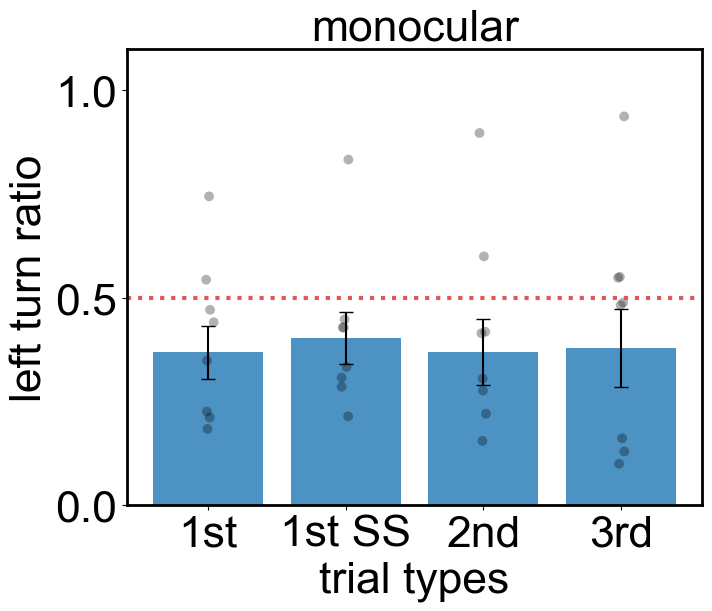

In [467]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))

# Prepare df
results = []
individual_results = []  
conditions = []

conditions.append(('oamonle', 'light'))

df = con_df[~con_df['obstacle_cluster'].isin([2,3])]

df = df[df.intial_distance>=15] 


# First calculate the same-side trial pair ratios (new "1st -1" df)
same_side_results = []
same_side_individual = []

for task, label in conditions:
    task_df = df[df['task'] == task]
    type0_df = task_df[task_df['consective_type'] == 0]
    
    # Find same-side trial pairs
    for idx, row in type0_df.iterrows():
        prev_idx = idx - 1
        if prev_idx in df.index:
            prev_trial = df.loc[prev_idx]
            current_cluster = row['obstacle_cluster']
            prev_cluster = prev_trial['obstacle_cluster']
            
            # Check if same side (both in 0,1 or both in 4,5)
            if ((current_cluster in [0,1] and prev_cluster in [0,1]) or 
                (current_cluster in [4,5] and prev_cluster in [4,5])):
                
                is_left = row['turn_direction_left_right'] == 'left'  # Changed to left turn
                same_side_results.append({
                    'task': label,
                    'animal': row['animal'],
                    'is_left': is_left
                })

# Calculate same-side ratios
if same_side_results:
    same_side_df = pd.DataFrame(same_side_results)
    # Group level
    same_side_total = len(same_side_df)
    same_side_left = same_side_df['is_left'].sum()
    same_side_ratio = same_side_left / same_side_total if same_side_total > 0 else 0
    
    # Individual level
    same_side_animal_ratios = []
    for animal in same_side_df['animal'].unique():
        animal_df = same_side_df[same_side_df['animal'] == animal]
        a_total = len(animal_df)
        a_left = animal_df['is_left'].sum()
        a_ratio = a_left / a_total if a_total > 0 else 0
        same_side_animal_ratios.append(a_ratio)
        same_side_individual.append({
            'task': label,
            'type': '-1',
            'animal': animal,
            'ratio': a_ratio
        })
    
    same_side_se = np.std(same_side_animal_ratios) / np.sqrt(len(same_side_animal_ratios)) if same_side_animal_ratios else 0

# Original calculations (now for left turns)
for task, label in conditions:
    task_df = df[df['task'] == task]
    
    for cons_type in [0, 1, 2]:
        type_df = task_df[task_df['consective_type'] == cons_type]
        
        total = len(type_df)
        left = len(type_df[type_df['turn_direction_left_right'] == 'left']) if total > 0 else 0
        ratio = left / total if total > 0 else 0
        
        animal_ratios = []
        for animal in type_df['animal'].unique():
            animal_df = type_df[type_df['animal'] == animal]
            a_total = len(animal_df)
            a_left = len(animal_df[animal_df['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
            a_ratio = a_left / a_total if a_total > 0 else 0
            animal_ratios.append(a_ratio)
            individual_results.append({
                'task': label,
                'type': str(cons_type),
                'animal': animal,
                'ratio': a_ratio
            })
        
        se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
        
        results.append({
            'task': label,
            'type': str(cons_type),
            'ratio': ratio,
            'se': se
        })

# Combine the df
if same_side_results:
    results.append({
        'task': label,
        'type': '-1',
        'ratio': same_side_ratio,
        'se': same_side_se
    })
    individual_results.extend(same_side_individual)

results_df = pd.DataFrame(results)
individual_df = pd.DataFrame(individual_results)

# Plot settings
n_conditions = len(conditions)
bar_width = 0.8/n_conditions
colors = {'light': 'tab:blue', 'dark': '#59a14f'}

x = np.arange(4)  # Now 0, -1, 1, 2 (swapped positions)

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=1, linewidth=3)

# Plot bars
for i, (task, label) in enumerate(conditions):
    # Get df in new order: 0, -1, 1, 2
    task_df = results_df[results_df['task'] == label]
    ratios = task_df.set_index('type').loc[['0','-1','1','2']]['ratio'].values
    ses = task_df.set_index('type').loc[['0','-1','1','2']]['se'].values
    pos = x + i*bar_width - (bar_width*n_conditions/2 - bar_width/2)
    
    # Plot bars with error bars
    bars = ax.bar(pos, ratios, bar_width,
           color=colors[label],
           label=label,
           edgecolor='none',
           alpha=0.8,
           yerr=ses,
           capsize=5)
    
    # Plot individual df points
    ind_task_df = individual_df[individual_df['task'] == label]
    for j, cons_type in enumerate(['0', '-1', '1', '2']):
        type_df = ind_task_df[ind_task_df['type'] == cons_type]
        jitter = np.random.normal(0, 0.02, size=len(type_df))
        ax.scatter(pos[j] + jitter, type_df['ratio'], 
                  color='black', alpha=0.3, s=50, edgecolor='none')

# Customize plot
ax.set_xlabel('trial types')
ax.set_ylabel('left turn ratio')  # Changed y-axis label
ax.set_xticks(x)
ax.set_xticklabels(['1st', '1st SS', '2nd', '3rd'])  # Using abbreviated label
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.1)

# Remove grid and frame
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)

# Add legend if showing both conditions
if n_conditions > 1:
    ax.legend(frameon=False)
plt.title('monocular')

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

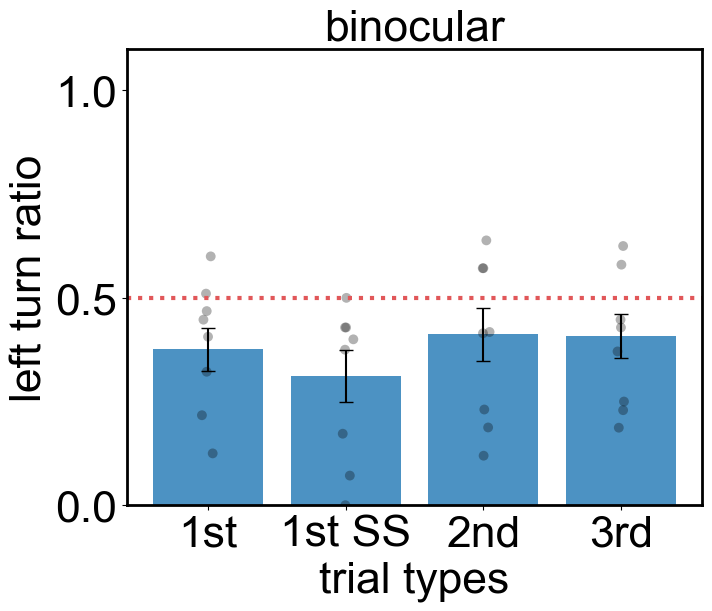

In [468]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))

# Prepare df
results = []
individual_results = []  
conditions = []

conditions.append(('oa', 'light'))

df = con_df[~con_df['obstacle_cluster'].isin([2,3])]

df = df[df.intial_distance>=15] 


# First calculate the same-side trial pair ratios (new "1st -1" df)
same_side_results = []
same_side_individual = []

for task, label in conditions:
    task_df = df[df['task'] == task]
    type0_df = task_df[task_df['consective_type'] == 0]
    
    # Find same-side trial pairs
    for idx, row in type0_df.iterrows():
        prev_idx = idx - 1
        if prev_idx in df.index:
            prev_trial = df.loc[prev_idx]
            current_cluster = row['obstacle_cluster']
            prev_cluster = prev_trial['obstacle_cluster']
            
            # Check if same side (both in 0,1 or both in 4,5)
            if ((current_cluster in [0,1] and prev_cluster in [0,1]) or 
                (current_cluster in [4,5] and prev_cluster in [4,5])):
                
                is_left = row['turn_direction_left_right'] == 'left'  # Changed to left turn
                same_side_results.append({
                    'task': label,
                    'animal': row['animal'],
                    'is_left': is_left
                })

# Calculate same-side ratios
if same_side_results:
    same_side_df = pd.DataFrame(same_side_results)
    # Group level
    same_side_total = len(same_side_df)
    same_side_left = same_side_df['is_left'].sum()
    same_side_ratio = same_side_left / same_side_total if same_side_total > 0 else 0
    
    # Individual level
    same_side_animal_ratios = []
    for animal in same_side_df['animal'].unique():
        animal_df = same_side_df[same_side_df['animal'] == animal]
        a_total = len(animal_df)
        a_left = animal_df['is_left'].sum()
        a_ratio = a_left / a_total if a_total > 0 else 0
        same_side_animal_ratios.append(a_ratio)
        same_side_individual.append({
            'task': label,
            'type': '-1',
            'animal': animal,
            'ratio': a_ratio
        })
    
    same_side_se = np.std(same_side_animal_ratios) / np.sqrt(len(same_side_animal_ratios)) if same_side_animal_ratios else 0

# Original calculations (now for left turns)
for task, label in conditions:
    task_df = df[df['task'] == task]
    
    for cons_type in [0, 1, 2]:
        type_df = task_df[task_df['consective_type'] == cons_type]
        
        total = len(type_df)
        left = len(type_df[type_df['turn_direction_left_right'] == 'left']) if total > 0 else 0
        ratio = left / total if total > 0 else 0
        
        animal_ratios = []
        for animal in type_df['animal'].unique():
            animal_df = type_df[type_df['animal'] == animal]
            a_total = len(animal_df)
            a_left = len(animal_df[animal_df['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
            a_ratio = a_left / a_total if a_total > 0 else 0
            animal_ratios.append(a_ratio)
            individual_results.append({
                'task': label,
                'type': str(cons_type),
                'animal': animal,
                'ratio': a_ratio
            })
        
        se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
        
        results.append({
            'task': label,
            'type': str(cons_type),
            'ratio': ratio,
            'se': se
        })

# Combine the df
if same_side_results:
    results.append({
        'task': label,
        'type': '-1',
        'ratio': same_side_ratio,
        'se': same_side_se
    })
    individual_results.extend(same_side_individual)

results_df = pd.DataFrame(results)
individual_df = pd.DataFrame(individual_results)

# Plot settings
n_conditions = len(conditions)
bar_width = 0.8/n_conditions
colors = {'light': 'tab:blue', 'dark': '#59a14f'}

x = np.arange(4)  # Now 0, -1, 1, 2 (swapped positions)

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=1, linewidth=3)

# Plot bars
for i, (task, label) in enumerate(conditions):
    # Get df in new order: 0, -1, 1, 2
    task_df = results_df[results_df['task'] == label]
    ratios = task_df.set_index('type').loc[['0','-1','1','2']]['ratio'].values
    ses = task_df.set_index('type').loc[['0','-1','1','2']]['se'].values
    pos = x + i*bar_width - (bar_width*n_conditions/2 - bar_width/2)
    
    # Plot bars with error bars
    bars = ax.bar(pos, ratios, bar_width,
           color=colors[label],
           label=label,
           edgecolor='none',
           alpha=0.8,
           yerr=ses,
           capsize=5)
    
    # Plot individual df points
    ind_task_df = individual_df[individual_df['task'] == label]
    for j, cons_type in enumerate(['0', '-1', '1', '2']):
        type_df = ind_task_df[ind_task_df['type'] == cons_type]
        jitter = np.random.normal(0, 0.02, size=len(type_df))
        ax.scatter(pos[j] + jitter, type_df['ratio'], 
                  color='black', alpha=0.3, s=50, edgecolor='none')

# Customize plot
ax.set_xlabel('trial types')
ax.set_ylabel('left turn ratio')  # Changed y-axis label
ax.set_xticks(x)
ax.set_xticklabels(['1st', '1st SS', '2nd', '3rd'])  # Using abbreviated label
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.1)

# Remove grid and frame
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)

# Add legend if showing both conditions
if n_conditions > 1:
    ax.legend(frameon=False)
plt.title('binocular')

plt.tight_layout()
plt.show

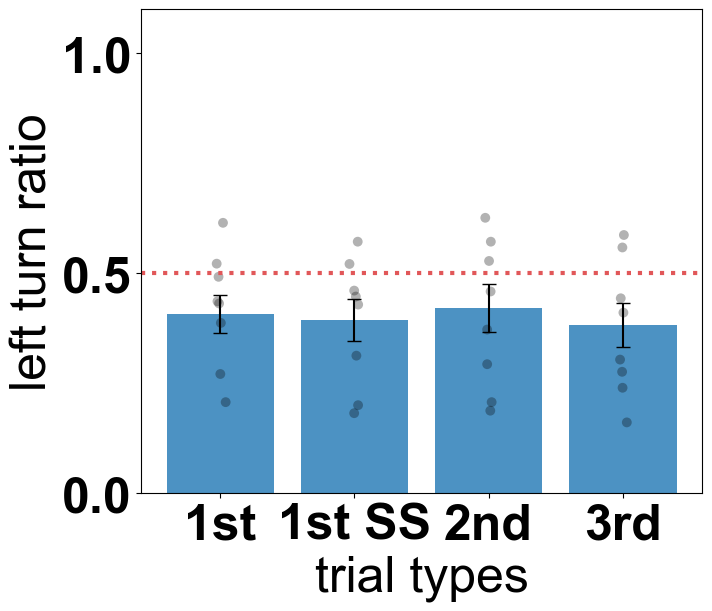

In [101]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))

# Prepare data
results = []
individual_results = []  
conditions = []

conditions.append(('oa', 'light'))

df = con_df[~con_df['obstacle_cluster'].isin([2,3])]

# First calculate the same-side trial pair ratios (new "1st -1" data)
same_side_results = []
same_side_individual = []

for task, label in conditions:
    task_data = df[df['task'] == task]
    type0_data = task_data[task_data['consective_type'] == 0]
    
    # Find same-side trial pairs
    for idx, row in type0_data.iterrows():
        prev_idx = idx - 1
        if prev_idx in df.index:
            prev_trial = df.loc[prev_idx]
            current_cluster = row['obstacle_cluster']
            prev_cluster = prev_trial['obstacle_cluster']
            
            # Check if same side (both in 0,1 or both in 4,5)
            if ((current_cluster in [0,1] and prev_cluster in [0,1]) or 
                (current_cluster in [4,5] and prev_cluster in [4,5])):
                
                is_left = row['turn_direction_left_right'] == 'left'  # Changed to left turn
                same_side_results.append({
                    'task': label,
                    'animal': row['animal'],
                    'is_left': is_left
                })

# Calculate same-side ratios
if same_side_results:
    same_side_df = pd.DataFrame(same_side_results)
    # Group level
    same_side_total = len(same_side_df)
    same_side_left = same_side_df['is_left'].sum()
    same_side_ratio = same_side_left / same_side_total if same_side_total > 0 else 0
    
    # Individual level
    same_side_animal_ratios = []
    for animal in same_side_df['animal'].unique():
        animal_data = same_side_df[same_side_df['animal'] == animal]
        a_total = len(animal_data)
        a_left = animal_data['is_left'].sum()
        a_ratio = a_left / a_total if a_total > 0 else 0
        same_side_animal_ratios.append(a_ratio)
        same_side_individual.append({
            'task': label,
            'type': '-1',
            'animal': animal,
            'ratio': a_ratio
        })
    
    same_side_se = np.std(same_side_animal_ratios) / np.sqrt(len(same_side_animal_ratios)) if same_side_animal_ratios else 0

# Original calculations (now for left turns)
for task, label in conditions:
    task_data = df[df['task'] == task]
    
    for cons_type in [0, 1, 2]:
        type_data = task_data[task_data['consective_type'] == cons_type]
        
        total = len(type_data)
        left = len(type_data[type_data['turn_direction_left_right'] == 'left']) if total > 0 else 0
        ratio = left / total if total > 0 else 0
        
        animal_ratios = []
        for animal in type_data['animal'].unique():
            animal_data = type_data[type_data['animal'] == animal]
            a_total = len(animal_data)
            a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
            a_ratio = a_left / a_total if a_total > 0 else 0
            animal_ratios.append(a_ratio)
            individual_results.append({
                'task': label,
                'type': str(cons_type),
                'animal': animal,
                'ratio': a_ratio
            })
        
        se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
        
        results.append({
            'task': label,
            'type': str(cons_type),
            'ratio': ratio,
            'se': se
        })

# Combine the data
if same_side_results:
    results.append({
        'task': label,
        'type': '-1',
        'ratio': same_side_ratio,
        'se': same_side_se
    })
    individual_results.extend(same_side_individual)

results_df = pd.DataFrame(results)
individual_df = pd.DataFrame(individual_results)

# Plot settings
n_conditions = len(conditions)
bar_width = 0.8/n_conditions
colors = {'light': 'tab:blue', 'dark': '#59a14f'}

x = np.arange(4)  # Now 0, -1, 1, 2 (swapped positions)

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=1, linewidth=3)

# Plot bars
for i, (task, label) in enumerate(conditions):
    # Get data in new order: 0, -1, 1, 2
    task_df = results_df[results_df['task'] == label]
    ratios = task_df.set_index('type').loc[['0','-1','1','2']]['ratio'].values
    ses = task_df.set_index('type').loc[['0','-1','1','2']]['se'].values
    pos = x + i*bar_width - (bar_width*n_conditions/2 - bar_width/2)
    
    # Plot bars with error bars
    bars = ax.bar(pos, ratios, bar_width,
           color=colors[label],
           label=label,
           edgecolor='none',
           alpha=0.8,
           yerr=ses,
           capsize=5)
    
    # Plot individual data points
    ind_task_df = individual_df[individual_df['task'] == label]
    for j, cons_type in enumerate(['0', '-1', '1', '2']):
        type_data = ind_task_df[ind_task_df['type'] == cons_type]
        jitter = np.random.normal(0, 0.02, size=len(type_data))
        ax.scatter(pos[j] + jitter, type_data['ratio'], 
                  color='black', alpha=0.3, s=50, edgecolor='none')

# Customize plot
ax.set_xlabel('trial types')
ax.set_ylabel('left turn ratio')  # Changed y-axis label
ax.set_xticks(x)
ax.set_xticklabels(['1st', '1st SS', '2nd', '3rd'])  # Using abbreviated label
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.1)

# Remove grid and frame
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)

# Add legend if showing both conditions
if n_conditions > 1:
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()